# <p style="text-align:center;">Check the quality of the data from UNARETI V2</p>


__FROM: https://www.cawcr.gov.au/projects/verification/__

Allan Murphy, a pioneer in the field of forecast verification, wrote an essay on what makes a forecast "good" (Murphy, 1993). He distinguished three types of "goodness":

<strong>Consistency</strong> - the degree to which the forecast corresponds to the forecaster's best judgement about the situation, based upon his/her knowledge base

<strong>Quality</strong> - the degree to which the forecast corresponds to what actually happened

<strong>Value</strong> - the degree to which the forecast helps a decision maker to realize some incremental economic and/or other benefit

</br>
Since we're interested in forecast verification, let's look a bit closer at the forecast quality. Murphy described nine aspects (called "attributes") that contribute to the quality of a forecast. These are:

<strong>Bias</strong> - the correspondence between the mean forecast and mean observation.

<strong>Association</strong> - the strength of the linear relationship between the forecasts and observations (for example, the correlation coefficient measures this linear relationship)

<strong>Accuracy</strong> - the level of agreement between the forecast and the truth (as represented by observations). The difference between the forecast and the observation is the error. The lower the errors, the greater the accuracy.

<strong>Skill</strong> - the relative accuracy of the forecast over some reference forecast. The reference forecast is generally an unskilled forecast such as random chance, persistence (defined as the most recent set of observations, "persistence" implies no change in condition), or climatology. Skill refers to the increase in accuracy due purely to the "smarts" of the forecast system. Weather forecasts may be more accurate simply because the weather is easier to forecast -- skill takes this into account.

<strong>Reliability</strong> - the average agreement between the forecast values and the observed values. If all forecasts are considered together, then the overall reliability is the same as the bias. If the forecasts are stratified into different ranges or categories, then the reliability is the same as the conditional bias, i.e., it has a different value for each category.

<strong>Resolution</strong> - the ability of the forecast to sort or resolve the set of events into subsets with different frequency distributions. This means that the distribution of outcomes when "A" was forecast is different from the distribution of outcomes when "B" is forecast. Even if the forecasts are wrong, the forecast system has resolution if it can successfully separate one type of outcome from another.

<strong>Sharpness</strong> - the tendency of the forecast to predict extreme values. To use a counter-example, a forecast of "climatology" has no sharpness. Sharpness is a property of the forecast only, and like resolution, a forecast can have this attribute even if it's wrong (in this case it would have poor reliability).

<strong>Discrimination</strong> - ability of the forecast to discriminate among observations, that is, to have a higher prediction frequency for an outcome whenever that outcome occurs.

<strong>Uncertainty</strong> - the variability of the observations. The greater the uncertainty, the more difficult the forecast will tend to be.

In [2]:
from google.cloud import bigquery
from google.cloud import storage
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter, MultipleLocator
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from decimal import *
from calendar import monthrange, month_abbr
import cartopy as ctp
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.io import shapereader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import io
import base64
import pygrib
import math
import netCDF4
import pytz
import cmocean
import seaborn as sns
from sklearn.metrics import mean_squared_error, confusion_matrix
import matplotlib.dates as mdates
from pytz import timezone, all_timezones
from scipy.stats import spearmanr, pearsonr, linregress
import scipy.signal as signal
from scipy.interpolate import interp1d
from taylor_diagram import TaylorDiagram
import statsmodels.api as sm
import os
import difflib
import folium
from folium.plugins import MarkerCluster, BeautifyIcon
from PIL import Image, ImageDraw
import warnings
import properscoring as ps
import numba
import pprint
from geopy.distance import geodesic
import xarray as xr

In [3]:
# insert here the min_lat, max_lat, min_lon, max_lon, and the date you want to analyse
min_lat, max_lat=  45.12, 45.70
min_lon, max_lon= 9.06, 10.23

## Build the list of points from Moloch, IFS and UNARETI


### Moloch and IFS

In [4]:
def distance_haversine(lat1, lat2, lon1, lon2):
    """
    Calculate the great circle distance between two points
    """

    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(math.radians, [lon1, lat1, lon2, lat2])

    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))
    r = 6371000 # Radius of earth in meters. 
    return c * r

In [5]:
def query_moloch_gridpoints(min_lat=45.12, max_lat=45.70, min_lon=9.06, max_lon=10.23):
    """
    Query the Moloch gridpoints from the dataplatform
    """

    # define the client for the queries
    project_name = 'a2a-dataplatformgt-pmt-prd'
    client = bigquery.Client(project=project_name)

    # ------------ QUERY THE MOLOCH GRIDPOINTS FROM THE DATAPLATFORM ------------

    # Query the grid of IFS gridpoint for which we have the historic of the forecasts
    query = """
        SELECT ANA.*
        FROM `a2a-dataplatformgt-dwh-prd.L2.D_ANAGRAFICA_METEO_FCST` ANA
        WHERE ANA.X_MOLOCH=(SELECT DISTINCT FCST.X, 
            FROM `a2a-dataplatformgt-dwh-prd.L2.F_FORECAST_DATA_ARPAL` FCST
            WHERE ANA.X_MOLOCH=FCST.X AND ANA.Y_MOLOCH=FCST.Y AND FCST.DATA_FORECAST < "2023-01-01T00:00:00"
            )
        AND ANA.Y_MOLOCH=(SELECT DISTINCT FCST.Y, 
            FROM `a2a-dataplatformgt-dwh-prd.L2.F_FORECAST_DATA_ARPAL` FCST
            WHERE ANA.X_MOLOCH=FCST.X AND ANA.Y_MOLOCH=FCST.Y AND FCST.DATA_FORECAST < "2023-01-01T00:00:00"
            )
        AND ANA.LAT BETWEEN @min_lat AND @max_lat
        AND ANA.LON BETWEEN @min_lon AND @max_lon

        ORDER BY ANA.ID;
        """
    
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ScalarQueryParameter("min_lat", "FLOAT", min_lat),
            bigquery.ScalarQueryParameter("max_lat", "FLOAT", max_lat),
            bigquery.ScalarQueryParameter("min_lon", "FLOAT", min_lon),
            bigquery.ScalarQueryParameter("max_lon", "FLOAT", max_lon),
            ]
        )

    result_moloch = client.query(query, job_config=job_config)

    # save the result in a pandas dataset
    gridpoints_moloch = result_moloch.to_dataframe(create_bqstorage_client=False).astype({'LAT':float, 'LON':float, 'MIN_LAT_MOLOCH':float, 'MIN_LON_MOLOCH':float, 'X_MOLOCH':int, 'Y_MOLOCH':int})

    # Create a map of the gridpoints centered around the midpoint of the latitude and longitude
    map_center = [(min_lat + max_lat) / 2, (min_lon + max_lon) / 2]
    m = folium.Map(location=map_center, zoom_start=10)

    # Add gridpoints to the map
    for idx, row in gridpoints_moloch.iterrows():
        folium.CircleMarker(
            location=[row['LAT'], row['LON']],
            radius=3,
            color='blue',
            fill=True,
            fill_color='blue'
        ).add_to(m)

    # Display the map
    m.save(r"C:\Users\jil.etienne\OneDrive - A2A Group\documents\04_projects\power_outages\map_moloch_gridpoints.html")

    return gridpoints_moloch

In [10]:
moloch_gridpoints=query_moloch_gridpoints()
print(moloch_gridpoints)


         ID  ID_PAST  ID_CONSUNTIVO                 ASSET_ID  \
0    900274     <NA>           <NA>               AGGIUNTIVI   
1    900275     <NA>           <NA>               AGGIUNTIVI   
2    900276     <NA>           <NA>               AGGIUNTIVI   
3    900278     <NA>           <NA>          CICLO_COMBINATO   
4    900284     <NA>           <NA>                FV_ARZAGO   
..      ...      ...            ...                      ...   
134  904509     <NA>         503376  IBM_Weather_Underground   
135  904511     <NA>         501025  IBM_Weather_Underground   
136  904703     <NA>           <NA>              Weathernews   
137  904738     <NA>         503391              Weathernews   
138  904745     <NA>           <NA>              Weathernews   

                       ASSET_ID_WTG                        OLD_NAME  \
0           AGGIUNTIVI_7_MilanoZone                    Aggiuntivi_7   
1           AGGIUNTIVI_8_MilanoZone                    Aggiuntivi_8   
2           AGGIUN

In [6]:
def query_ifs_gridpoints(min_lat=45.12, max_lat=45.70, min_lon=9.06, max_lon=10.23):
    """
    Query the IFS gridpoints from the dataplatform
    """

    # define the client for the queries
    project_name = 'a2a-dataplatformgt-pmt-prd'
    client = bigquery.Client(project=project_name)

    # ------------ QUERY THE IFS GRIDPOINTS FROM THE DATAPLATFORM ------------

    # Query the grid of IFS gridpoint for which we have the historic of the forecasts
    query = """
        SELECT ANA.*
        FROM `a2a-dataplatformgt-dwh-prd.L2.D_ANAGRAFICA_METEO_FCST` ANA
        WHERE ANA.LAT=(SELECT DISTINCT FCST.LAT, 
            FROM `a2a-dataplatformgt-dwh-prd.L2.F_FORECAST_DATA_ECMWF_IFS_METEOMATICS` FCST
            WHERE ANA.LAT=FCST.LAT AND ANA.LON=FCST.LON AND FCST.TRADE_DATE < "2023-01-01T00:00:00"
            )
        AND ANA.LON=(SELECT DISTINCT FCST.LON, 
            FROM `a2a-dataplatformgt-dwh-prd.L2.F_FORECAST_DATA_ECMWF_IFS_METEOMATICS` FCST
            WHERE ANA.LAT=FCST.LAT AND ANA.LON=FCST.LON AND FCST.TRADE_DATE < "2023-01-01T00:00:00"
            )
        AND ANA.LAT BETWEEN @min_lat AND @max_lat
        AND ANA.LON BETWEEN @min_lon AND @max_lon

        ORDER BY ANA.ID;
        """
    
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ScalarQueryParameter("min_lat", "FLOAT", min_lat),
            bigquery.ScalarQueryParameter("max_lat", "FLOAT", max_lat),
            bigquery.ScalarQueryParameter("min_lon", "FLOAT", min_lon),
            bigquery.ScalarQueryParameter("max_lon", "FLOAT", max_lon),
            ]
        )

    result2 = client.query(query, job_config=job_config)

    # save the result in a pandas dataset
    gridpoints2 = result2.to_dataframe(create_bqstorage_client=False).astype({'LAT':float, 'LON':float, 'MIN_LAT_MOLOCH':float, 'MIN_LON_MOLOCH':float, 'X_MOLOCH':int, 'Y_MOLOCH':int})

     # Create a map of the gridpoints centered around the midpoint of the latitude and longitude
    map_center = [(min_lat + max_lat) / 2, (min_lon + max_lon) / 2]
    m = folium.Map(location=map_center, zoom_start=10)

    # Add gridpoints to the map
    for idx, row in gridpoints2.iterrows():
        folium.CircleMarker(
            location=[row['LAT'], row['LON']],
            radius=3,
            color='blue',
            fill=True,
            fill_color='blue'
        ).add_to(m)

    # Display the map
    m.save(r"C:\Users\jil.etienne\OneDrive - A2A Group\documents\04_projects\power_outages\map_ifs_gridpoints.html")

    return gridpoints2

In [7]:
ifs_gridpoints= query_ifs_gridpoints()

In [8]:
def get_anagrafe_ifs_moloch(min_lat=45.12, max_lat=45.70, min_lon=9.06, max_lon=10.23):
    """
    builds the list of Meteomatics gridpoints (from the anagraphical forecast table) that have a station associated, and for which we have the historic of the IFS forecasts.
    From those points, are added the closest Moloch gridpoints.
    Aferwards are also added observations from the FOMD, and the IFS and Moloch gridpoints closest to the FOMD stations.
    Then we add the Moloch gridpoints closest to the FOMD stations, without any IFS gridpoints associated.
    In the dataset:
    ID -> ID of the IFS gridpoint
    ID_CONSUNTIVO -> ID of the univoque station
    LAT, LON -> coordinates of the points
    LAT_METEOMATICS, LON_METEOMATICS -> coordinates of the point given for which the data have been given by Meteomatics
    MIN_LAT_MOLOCH, MIN_LON_MOLOCH -> coordinates of the closest Moloch gridpoint 
    """

    # take points around Milano
    #min_lat, max_lat=  45.12, 45.70
    #min_lon, max_lon= 9.06, 10.23
    #min_lat, max_lat= 44.33, 45.45
    #min_lon, max_lon= 7.38, 12.10

    # define the client for the queries
    project_name = 'a2a-dataplatformgt-pmt-prd'
    client = bigquery.Client(project=project_name)

    # ---------------------- BUILD ANAGRAFE FROM IFS GRIDPOINTS WITH 'DS' STATIONS ----------------------------------------
    
    # query the gridpoints in the area, that have a 'DS' station associated, and for which we have the historic of the IFS forecasts
    query = """
        SELECT ANA.*
        FROM `a2a-dataplatformgt-dwh-prd.L2.D_ANAGRAFICA_METEO_FCST` ANA
        WHERE ANA.LAT=(SELECT DISTINCT FCST.LAT, 
            FROM `a2a-dataplatformgt-dwh-prd.L2.F_FORECAST_DATA_ECMWF_IFS_METEOMATICS` FCST
            WHERE ANA.LAT=FCST.LAT AND ANA.LON=FCST.LON AND FCST.TRADE_DATE < "2023-01-01T00:00:00"
            )
        AND ANA.LON=(SELECT DISTINCT FCST.LON, 
            FROM `a2a-dataplatformgt-dwh-prd.L2.F_FORECAST_DATA_ECMWF_IFS_METEOMATICS` FCST
            WHERE ANA.LAT=FCST.LAT AND ANA.LON=FCST.LON AND FCST.TRADE_DATE < "2023-01-01T00:00:00"
            ) 
        AND ANA.ID_CONSUNTIVO=(SELECT DISTINCT OBS.ID_CONSUNTIVO, 
            FROM `a2a-dataplatformgt-dwh-prd.L2.D_ANAGRAFICA_METEO_OBS` OBS
            WHERE ANA.ID_CONSUNTIVO=OBS.ID_CONSUNTIVO AND OBS.STORICO='DS' 
            )
        AND ANA.LAT BETWEEN @min_lat AND @max_lat
        AND ANA.LON BETWEEN @min_lon AND @max_lon

        ORDER BY ANA.ID;
        """
    
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ScalarQueryParameter("min_lat", "FLOAT", min_lat),
            bigquery.ScalarQueryParameter("max_lat", "FLOAT", max_lat),
            bigquery.ScalarQueryParameter("min_lon", "FLOAT", min_lon),
            bigquery.ScalarQueryParameter("max_lon", "FLOAT", max_lon),
            ]
        )

    result = client.query(query, job_config=job_config)

    # save the result in a pandas dataset
    dataset = result.to_dataframe(create_bqstorage_client=False).astype({'LAT':float, 'LON':float, 'MIN_LAT_MOLOCH':float, 'MIN_LON_MOLOCH':float})

    # query the stations associated to the gridpoints from teh station anagrafe table
    query2 = """
        SELECT DISTINCT OBS.ID_CONSUNTIVO, OBS.OLD_STATION_NAME, OBS.LATITUDE, OBS.LONGITUDE
        FROM `a2a-dataplatformgt-dwh-prd.L2.D_ANAGRAFICA_METEO_OBS` OBS
        WHERE OBS.ID_CONSUNTIVO IN UNNEST(@list_id)
        """
    
    job_config2 = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ArrayQueryParameter("list_id", "INT64", dataset['ID_CONSUNTIVO'].to_list())
            ]
        )
    
    result2 = client.query(query2, job_config=job_config2)
    stations_latlon = result2.to_dataframe(create_bqstorage_client=False).astype({'ID_CONSUNTIVO':'int', 'LATITUDE':'float', 'LONGITUDE':'float'})
    
    # for each duplicate station, take the closest IFS gridpoint
    for ID_station in dataset['ID_CONSUNTIVO'].unique():
        sliced=dataset[dataset['ID_CONSUNTIVO']==ID_station]
        lat_station=stations_latlon[stations_latlon['ID_CONSUNTIVO']==ID_station].iloc[0]['LATITUDE']
        lon_station=stations_latlon[stations_latlon['ID_CONSUNTIVO']==ID_station].iloc[0]['LONGITUDE']
        list_distances=[]
        for i in sliced.index:
            lat_gridpoint=sliced.loc[i]['LAT']
            lon_gridpoint=sliced.loc[i]['LON']
            list_distances.append(distance_haversine(lat_station, lat_gridpoint, lon_station, lon_gridpoint))
        closest_ID=sliced.iloc[np.argmin(list_distances)]['ID']
    
        # drop the lines in the dataset that have the station as consuntivo but are not the gridpoints with the closest ID
        dataset=dataset.drop(dataset[(dataset['ID_CONSUNTIVO']==ID_station) & (dataset['ID']!=closest_ID)].index)

    # add the station name, station lat and station lon as columns to the dataset
    dataset['OLD_STATION_NAME']=''
    dataset['STATION_LAT']=0.0
    dataset['STATION_LON']=0.0
    for ID_station in dataset['ID_CONSUNTIVO'].unique():
        station_name=stations_latlon[stations_latlon['ID_CONSUNTIVO']==ID_station].iloc[0]['OLD_STATION_NAME']
        dataset.loc[dataset['ID_CONSUNTIVO']==ID_station, 'OLD_STATION_NAME']=station_name
        
        station_lat=stations_latlon[stations_latlon['ID_CONSUNTIVO']==ID_station].iloc[0]['LATITUDE']
        dataset.loc[dataset['ID_CONSUNTIVO']==ID_station, 'STATION_LAT']=station_lat
        
        station_lon=stations_latlon[stations_latlon['ID_CONSUNTIVO']==ID_station].iloc[0]['LONGITUDE']
        dataset.loc[dataset['ID_CONSUNTIVO']==ID_station, 'STATION_LON']=station_lon

    # remove Monza v.Monte Generoso 
    if 'Monza v.Monte Generoso' in dataset['OLD_STATION_NAME'].to_list():
        dataset=dataset.drop(dataset[dataset['OLD_STATION_NAME']=='Monza v.Monte Generoso'].index)

    # reset the index of the dataset
    dataset=dataset.reset_index(drop=True)

    # ------------ LOAD THE METADATA FROM FOMD ------------

    codice_stazione = {
        "MILANO Centro": 1,
        "MILANO Bicocca": 2,
        "MILANO Bovisa": 4,
        "MILANO Città Studi": 6,
        "MILANO Bocconi": 7,
        "MILANO Sud": 8,
        "MILANO Forze Armate": 9,
        "MILANO San Siro": 10
        }

    # add the observation data from FOMD
    filename=r"C:\Users\jil.etienne\OneDrive - A2A Group\documents\04_projects\power_outages\data_fomd\Dati2021-2024\Dati2021-2024\Metadata.xlsx"
    fomd=pd.read_excel(filename, sheet_name='METADATA', skipfooter=7)

    # rename the columns
    fomd.rename(columns={'Nome stazione':'STATION_NAME', 
                         'Latitudine  (gradi decimali WGS84)':'STATION_LAT', 
                         'Longitudine  (gradi decimali WGS84)':'STATION_LON', 
                         'Altezza Piano strada (m slm) *':'STATION_ALTITUDE_STRADA',
                         'Altezza Totale (m) **':'STATION_ALTITUDE'},
                         inplace=True)
    
    # set types
    fomd['STATION_LAT']=fomd['STATION_LAT'].astype(float)
    fomd['STATION_LON']=fomd['STATION_LON'].astype(float)
    fomd['STATION_ALTITUDE_STRADA']=fomd['STATION_ALTITUDE_STRADA'].astype(float)
    fomd['STATION_ALTITUDE']=fomd['STATION_ALTITUDE'].astype(float)
    
    # remove stars from the station names and uppercase Milano Forze Armate
    fomd['STATION_NAME']=fomd['STATION_NAME'].str.replace('*','')
    fomd['STATION_NAME']=fomd['STATION_NAME'].str.replace('Milano Forze Armate','MILANO Forze Armate')
    fomd['STATION_NAME']=fomd['STATION_NAME'].str.replace('MILANO San Siro ','MILANO San Siro')
    fomd['STATION_NAME']=fomd['STATION_NAME'].str.replace('MILANO Sud ','MILANO Sud')

    # add column SOURCE
    fomd['STATION_SOURCE']='FOMD'

    # ------------- ASSOCIATE THE IFS GRIDPOINTS TO THE FOMD STATIONS -------------

    # for each station, take the closest Moloch gridpoint and, if an IFS gridpoint is assiated in the preexisting anagrafe, take it too
    fomd['ID']=np.nan
    fomd['LAT']=np.nan
    fomd['LON']=np.nan
    fomd['ALTITUDE']=np.nan
    fomd['MIN_LAT_MOLOCH']=np.nan
    fomd['MIN_LON_MOLOCH']=np.nan
    fomd['X_MOLOCH']=np.nan
    fomd['Y_MOLOCH']=np.nan
    fomd['ID_CONSUNTIVO']=np.nan
    
    for i in fomd.index:
        lat_station=fomd.loc[i]['STATION_LAT']
        lon_station=fomd.loc[i]['STATION_LON']
        list_distances=[]
        for j in moloch_gridpoints.index:
            lat_gridpoint=moloch_gridpoints.loc[j]['MIN_LAT_MOLOCH']
            lon_gridpoint=moloch_gridpoints.loc[j]['MIN_LON_MOLOCH']
            list_distances.append(distance_haversine(lat_station, lat_gridpoint, lon_station, lon_gridpoint))
        closest_ID=moloch_gridpoints.iloc[np.nanargmin(list_distances)]['ID']
        fomd.loc[i, 'ID']=int(closest_ID)
        fomd.loc[i, 'LAT']=moloch_gridpoints[moloch_gridpoints['ID']==closest_ID].iloc[0]['LAT']
        fomd.loc[i, 'LON']=moloch_gridpoints[moloch_gridpoints['ID']==closest_ID].iloc[0]['LON']
        fomd.loc[i, 'ALTITUDE']=float(moloch_gridpoints[moloch_gridpoints['ID']==closest_ID].iloc[0]['ALTITUDINE_M'])
        fomd.loc[i, 'MIN_LAT_MOLOCH']=moloch_gridpoints[moloch_gridpoints['ID']==closest_ID].iloc[0]['MIN_LAT_MOLOCH']
        fomd.loc[i, 'MIN_LON_MOLOCH']=moloch_gridpoints[moloch_gridpoints['ID']==closest_ID].iloc[0]['MIN_LON_MOLOCH']
        fomd.loc[i, 'X_MOLOCH']=moloch_gridpoints[moloch_gridpoints['ID']==closest_ID].iloc[0]['X_MOLOCH']
        fomd.loc[i, 'Y_MOLOCH']=moloch_gridpoints[moloch_gridpoints['ID']==closest_ID].iloc[0]['Y_MOLOCH']
        fomd.loc[i, 'ID_CONSUNTIVO']=int(600000+codice_stazione[fomd.loc[i]['STATION_NAME']])

    # --------------------- MERGE FOMD AND ANAGRAFE -------------------------------
    
    # rename the columns of the fomd dataset
    fomd.rename(columns={'STATION_NAME':'OLD_STATION_NAME'},
                         inplace=True)

    # add a source columns
    fomd['STATION_SOURCE']='FOMD'
    dataset['STATION_SOURCE']='MISTRAL'

    full_anagrafe = pd.concat([dataset, fomd], ignore_index=True)

    # drop useless columns
    full_anagrafe=full_anagrafe.drop(columns=['ID_PAST', 'ASSET_ID', 'ASSET_ID_WTG', 'FILE_ORIGINALE', 'NOME_IMPIANTO', 'LAT_IBM', 'LON_IBM', 'LON_WEATHERNEWS', 'LAT_WEATHERNEWS', 'ELIMINARE_CHIAMATA', 'TYPE0',
                                              'NEW_REQUEST_METEOMATICS', 'NOTE', 'PROVIDER', 'SHOW_IT','CURRENT_CHIAMATE_METEOMATICS', 'SOURCE', 'VERSION', 'VERSION_DATE', 'OLD_NAME', 'LAT_METEOMATICS', 'LONG_METEOMATICS'])
    
    # reset the index
    full_anagrafe=full_anagrafe.reset_index(drop=True)

    # ---------------------- REMOVE STATIONS ASSOCIATED TO DUPLICATE MOLOCH GRIPOINTS ----------------------------
    
    # for each duplicate ID, discard the further station
    for ID in full_anagrafe['ID'].unique():
        sliced=full_anagrafe[full_anagrafe['ID']==ID]
        list_distances=[]
        for i in sliced.index:
            lat_station=sliced.loc[i]['STATION_LAT']
            lon_station=sliced.loc[i]['STATION_LON']
            lat_gridpoint=sliced.loc[i]['LAT']
            lon_gridpoint=sliced.loc[i]['LON']
            list_distances.append(distance_haversine(lat_station, lat_gridpoint, lon_station, lon_gridpoint))
        closest_ID=sliced.iloc[np.argmin(list_distances)]['ID_CONSUNTIVO']
    
        # drop the lines in the dataset that have the station as consuntivo but are not the gridpoints with the closest ID
        full_anagrafe=full_anagrafe.drop(full_anagrafe[(full_anagrafe['ID']==ID) & (full_anagrafe['ID_CONSUNTIVO']!=closest_ID)].index)

    # reset the index
    full_anagrafe=full_anagrafe.reset_index(drop=True)
        
    return full_anagrafe
    

In [11]:
anagrafe=get_anagrafe_ifs_moloch()


In [12]:
print(anagrafe.columns)
print(anagrafe)
print(anagrafe['OLD_STATION_NAME'].unique())

Index(['ID', 'ID_CONSUNTIVO', 'LAT', 'LON', 'MIN_LAT_MOLOCH', 'MIN_LON_MOLOCH',
       'X_MOLOCH', 'Y_MOLOCH', 'ALTITUDINE_M', 'OLD_STATION_NAME',
       'STATION_LAT', 'STATION_LON', 'STATION_SOURCE',
       'STATION_ALTITUDE_STRADA', 'STATION_ALTITUDE', 'ALTITUDE'],
      dtype='object')
          ID  ID_CONSUNTIVO        LAT        LON  MIN_LAT_MOLOCH  \
0   900372.0       503416.0  45.487690   9.606290       45.493376   
1   900441.0       501061.0  45.254190   9.938660       45.253256   
2   900474.0       503399.0  45.137080   9.938660       45.141100   
3   901979.0       503462.0  45.604080   9.273910       45.606680   
4   901981.0       501199.0  45.604080   9.606290       45.605372   
5   902004.0       501025.0  45.677210   9.666470       45.675036   
6   902066.0       501042.0  45.516940  10.212680       45.516640   
7   902078.0       501173.0  45.506570   9.269790       45.508680   
8   902079.0       501177.0  45.462160   9.196920       45.466840   
9   902531.0       

### Weathernews (unused)

In [11]:
def get_anagrafe_weathernews(min_lat=45.12, max_lat=45.70, min_lon=9.06, max_lon=10.23):
    """
    builds the list of weathernews gridpoints (from the anagraphical forecast table) that have a station associated, and for which we have the historic of the IFS forecasts.
    From those points, are added the closest Moloch gridpoints.
    In the dataset:
    ID -> ID of the gridpoint
    ID_CONSUNTIVO -> ID of the univoque station
    LAT, LON -> coordinates of the points
    """

    # take points around Milano
    #min_lat, max_lat=  45.12, 45.70
    #min_lon, max_lon= 9.06, 10.23
    #min_lat, max_lat= 44.33, 45.45
    #min_lon, max_lon= 7.38, 12.10

    # define the client for the queries
    project_name = 'a2a-dataplatformgt-pmt-prd'
    client = bigquery.Client(project=project_name)
    
    # query the gridpoints in the area, that have a 'DS' station associated, and for which we have the historic of the IFS forecasts
    query = """
        SELECT ANA.*
        FROM `a2a-dataplatformgt-dwh-prd.L2.D_ANAGRAFICA_METEO_FCST` ANA
        WHERE ANA.LAT_WEATHERNEWS IS NOT NULL
            AND ANA.ID_CONSUNTIVO IS NOT NULL 
            AND ANA.LAT_WEATHERNEWS BETWEEN @min_lat AND @max_lat
            AND ANA.LON_WEATHERNEWS BETWEEN @min_lon AND @max_lon
        ORDER BY ANA.ID;
        """
    
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ScalarQueryParameter("min_lat", "FLOAT", min_lat),
            bigquery.ScalarQueryParameter("max_lat", "FLOAT", max_lat),
            bigquery.ScalarQueryParameter("min_lon", "FLOAT", min_lon),
            bigquery.ScalarQueryParameter("max_lon", "FLOAT", max_lon),
            ]
        )

    result = client.query(query, job_config=job_config)

    # save the result in a pandas dataset
    dataset = result.to_dataframe(create_bqstorage_client=False)#.astype({'LAT':float, 'LON':float, 'MIN_LAT_MOLOCH':float, 'MIN_LON_MOLOCH':float})

    # add the closest observation station from Mistral (with historical) to the dataset
    query_obs="""
        SELECT DISTINCT OBS.ID_CONSUNTIVO, OBS.OLD_STATION_NAME, OBS.LATITUDE, OBS.LONGITUDE
        FROM `a2a-dataplatformgt-dwh-prd.L2.D_ANAGRAFICA_METEO_OBS` OBS
        WHERE OBS.LATITUDE<@max_lat AND OBS.LATITUDE>@min_lat AND OBS.LONGITUDE<@max_lon AND OBS.LONGITUDE>@min_lon
        AND OBS.STORICO='DS'
        """

    job_config_obs = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ScalarQueryParameter("min_lat", "FLOAT", min_lat),
            bigquery.ScalarQueryParameter("max_lat", "FLOAT", max_lat),
            bigquery.ScalarQueryParameter("min_lon", "FLOAT", min_lon),
            bigquery.ScalarQueryParameter("max_lon", "FLOAT", max_lon),
            ]
        )
    
    result = client.query(query_obs, job_config=job_config_obs)
    stations_latlon = result.to_dataframe(create_bqstorage_client=False).astype({'ID_CONSUNTIVO':'int', 'LATITUDE':'float', 'LONGITUDE':'float'})

    # for each gridpoint of the dataset, take the closest observation station in a 5 km radius
    for i in dataset.index:
        lat_gridpoint=dataset.loc[i]['LAT_WEATHERNEWS']
        lon_gridpoint=dataset.loc[i]['LON_WEATHERNEWS']
        list_distances=[]
        for j in stations_latlon.index:
            lat_station=stations_latlon.loc[j]['LATITUDE']
            lon_station=stations_latlon.loc[j]['LONGITUDE']
            list_distances.append(distance_haversine(lat_station, lat_gridpoint, lon_station, lon_gridpoint))
        closest_ID=stations_latlon.iloc[np.argmin(list_distances)]['ID_CONSUNTIVO']
        if np.min(list_distances)>5000:
            closest_ID=np.nan
        dataset.loc[i, 'ID_CONSUNTIVO_bis']=closest_ID
        dataset.loc[i, 'obs_distance']=np.nanmin(list_distances)

    dataset = dataset.astype({'ID_CONSUNTIVO_bis':'Int64', 'obs_distance':'float'})

    return dataset
    

In [12]:
anagrafe_weathernews= get_anagrafe_weathernews(min_lat=35, max_lat=47, min_lon=6, max_lon=15)
print(anagrafe_weathernews)

        ID  ID_PAST  ID_CONSUNTIVO     ASSET_ID              ASSET_ID_WTG  \
0   904692     <NA>         502615  Weathernews     Weathernews_Agrigento   
1   904693     <NA>         504138  Weathernews   Weathernews_Alessandria   
2   904698     <NA>         503675  Weathernews          Weathernews_Asti   
3   904701     <NA>         502809  Weathernews       Weathernews_Belluno   
4   904702     <NA>         503069  Weathernews     Weathernews_Benevento   
5   904704     <NA>         503687  Weathernews        Weathernews_Biella   
6   904705     <NA>         504165  Weathernews       Weathernews_Bologna   
7   904711     <NA>         503502  Weathernews    Weathernews_Campobasso   
8   904716     <NA>         503389  Weathernews          Weathernews_Como   
9   904718     <NA>         503150  Weathernews       Weathernews_Cremona   
10  904720     <NA>         501708  Weathernews         Weathernews_Cuneo   
11  904722     <NA>         504590  Weathernews       Weathernews_Ferrara   

### UNARETI

In [13]:
def get_anagrafe_unareti():

    # Define the data
    data_unareti = {
        'Model': ['RAMSESZ'] *6  + ['WRFAESZ'] * 6,
        'ID': [52490, 52722, 52723, 52724, 52955, 52956, 81013, 81300, 81301, 81302, 81588, 81876],
        'Latitude': [45.4065, 45.4496, 45.4514, 45.4532, 45.4945, 45.4963, 45.4072, 45.4429, 45.4445, 45.446, 45.4801, 45.5173],
        'Longitude': [9.27015, 9.20358, 9.26758, 9.33158, 9.20096, 9.265, 9.28223, 9.22699, 9.28003, 9.3331, 9.22473, 9.2225]
    }

    # Create the DataFrame
    anagrafe_unareti = pd.DataFrame(data_unareti)

    # add a column for the closest station and its lat and lon
    anagrafe_unareti['ID_CONSUNTIVO'] = 0
    anagrafe_unareti['STATION_LAT'] = 0.0
    anagrafe_unareti['STATION_LON'] = 0.0
    anagrafe_unareti['OLD_STATION_NAME'] = ''
    for i in anagrafe_unareti.index:
        lat_unareti=anagrafe_unareti.loc[i]['Latitude']
        lon_unareti=anagrafe_unareti.loc[i]['Longitude']
        list_distances=[]
        for j in anagrafe.index:
            lat_station=anagrafe.loc[j]['STATION_LAT']
            lon_station=anagrafe.loc[j]['STATION_LON']
            list_distances.append(distance_haversine(lat_unareti, lat_station, lon_unareti, lon_station))
        closest_ID=anagrafe.iloc[np.argmin(list_distances)]['ID_CONSUNTIVO']
        anagrafe_unareti.loc[i, 'ID_CONSUNTIVO']=closest_ID
        anagrafe_unareti.loc[i, 'STATION_LAT']=anagrafe[anagrafe['ID_CONSUNTIVO']==closest_ID].iloc[0]['STATION_LAT']
        anagrafe_unareti.loc[i, 'STATION_LON']=anagrafe[anagrafe['ID_CONSUNTIVO']==closest_ID].iloc[0]['STATION_LON']
        anagrafe_unareti.loc[i, 'OLD_STATION_NAME']=anagrafe[anagrafe['ID_CONSUNTIVO']==closest_ID].iloc[0]['OLD_STATION_NAME']
    
    return anagrafe_unareti

In [14]:
anagrafe_unareti=get_anagrafe_unareti()
print(anagrafe_unareti)

      Model     ID  Latitude  Longitude  ID_CONSUNTIVO  STATION_LAT  \
0   RAMSESZ  52490   45.4065    9.27015         600008    45.431289   
1   RAMSESZ  52722   45.4496    9.20358         600007    45.450826   
2   RAMSESZ  52723   45.4514    9.26758         600006    45.479995   
3   RAMSESZ  52724   45.4532    9.33158         501173    45.496780   
4   RAMSESZ  52955   45.4945    9.20096         600002    45.510169   
5   RAMSESZ  52956   45.4963    9.26500         501173    45.496780   
6   WRFAESZ  81013   45.4072    9.28223         600008    45.431289   
7   WRFAESZ  81300   45.4429    9.22699         600008    45.431289   
8   WRFAESZ  81301   45.4445    9.28003         600006    45.479995   
9   WRFAESZ  81302   45.4460    9.33310         501173    45.496780   
10  WRFAESZ  81588   45.4801    9.22473         600006    45.479995   
11  WRFAESZ  81876   45.5173    9.22250         600002    45.510169   

    STATION_LON    OLD_STATION_NAME  
0      9.200497          MILANO Sud  


### Plot the locations

In [15]:
def where_are_points():
    """
    plot stations and gridpoints on a map
    """
    # take points around Milano
    #min_lat, max_lat=  45.00, 45.8
    #min_lon, max_lon= 9.0, 10.5
    #min_lat, max_lat= 44.33, 45.45
    #min_lon, max_lon= 7.38, 12.10

    min_lat, max_lat=anagrafe['STATION_LAT'].min()-0.2, anagrafe['STATION_LAT'].max()+0.2
    min_lon, max_lon=anagrafe['STATION_LON'].min()-0.2, anagrafe['STATION_LON'].max()+0.2

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        # list of station name from both anagrafe
        station_names=anagrafe['OLD_STATION_NAME'].to_list()

        # Create a map centered around the average location of the stations
        avg_lat = np.mean(anagrafe['STATION_LAT'])
        avg_lon = np.mean(anagrafe['STATION_LON'])
        m = folium.Map(location=[avg_lat, avg_lon], zoom_start=10)

        # Add stations to the map
        for i, station in enumerate(station_names):
            # get the station lat, lon depending on the source
            source = anagrafe.loc[anagrafe['OLD_STATION_NAME'] == station, 'STATION_SOURCE'].values[0]
            sliced = anagrafe[anagrafe['OLD_STATION_NAME'] == station]

            # plot the station
            folium.Marker(
            location=[sliced['STATION_LAT'].values[0], sliced['STATION_LON'].values[0]],
            popup=f"Station: {station}",
            icon=folium.Icon(color="blue", icon="house", prefix='fa')
            ).add_to(m)

            # plot the IFS gridpoints
            folium.Marker(
            location=[sliced['LAT'].values[0], sliced['LON'].values[0]],
            popup=f"IFS Gridpoint: {station}",
            icon=folium.Icon(color="green", icon="cloud", prefix='fa')
            ).add_to(m)

            # plot the Moloch gridpoints
            folium.Marker(
            location=[sliced['MIN_LAT_MOLOCH'].values[0], sliced['MIN_LON_MOLOCH'].values[0]],
            popup=f"Moloch Gridpoint: {station}",
            icon=folium.Icon(color="red", icon="cloud")
            ).add_to(m)

            # plot the unareti gridpoints associated to that station
            unareti = anagrafe_unareti[anagrafe_unareti['ID_CONSUNTIVO'] == sliced['ID_CONSUNTIVO'].values[0]]
            if not unareti.empty:
                for j in unareti.index:
                    folium.Marker(
                    location=[unareti.loc[j, 'Latitude'], unareti.loc[j, 'Longitude']],
                    popup=f"Unareti Gridpoint: {station}",
                    icon=folium.Icon(color="purple", icon="cloud")
                    ).add_to(m)

        # Add a legend
        legend_html = '''
         <div style="position: fixed; 
         bottom: 50px; left: 50px; width: 200px; height: 150px; 
         border:2px solid grey; z-index:9999; font-size:14px;
         background-color:white;
         ">&nbsp; <b>Legend</b> <br>
         &nbsp; <i class="fa fa-house" style="color:blue"></i>&nbsp; Station <br>
         &nbsp; <i class="fa fa-cloud" style="color:green"></i>&nbsp; IFS Gridpoint <br>
         &nbsp; <i class="fa fa-cloud" style="color:red"></i>&nbsp; Moloch Gridpoint <br>
         &nbsp; <i class="fa fa-cloud" style="color:purple"></i>&nbsp; Unareti Gridpoint
         </div>
         '''
        m.get_root().html.add_child(folium.Element(legend_html))

        return m


In [16]:
where_are_points()

## Collect data

### IFS (ECOP)

In [17]:
def query_ecop_from_anagrafe(var, list_forecast_date):
    """
    get the timeseries of the ecop forecast for the list of points from anagrafe and from anagrafe_fomd
    """

    project_name = 'a2a-dataplatformgt-pmt-prd'
    client = bigquery.Client(project=project_name)

    list_latlon = [bigquery.StructQueryParameter(None, bigquery.ScalarQueryParameter("lat", "FLOAT", lat), bigquery.ScalarQueryParameter("lon", "FLOAT", lon)) for lat, lon in zip(anagrafe['LAT'].to_list(), anagrafe['LON'].to_list())]
    
    query = """
        SELECT FCST.*
        FROM `a2a-dataplatformgt-dwh-prd.L2.F_FORECAST_DATA_ECMWF_IFS_METEOMATICS` FCST
            WHERE (FCST.LAT, FCST.LON) IN UNNEST(@list_latlon)
            AND FCST.COD_DATA_TYPE= @var
            AND FCST.TRADE_DATE in UNNEST(@forecast_dates)
        ORDER BY FCST.VALID_DATE;
        """
    
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ArrayQueryParameter("list_latlon", 
                bigquery.StructQueryParameterType(
                    bigquery.ScalarQueryParameterType(type_="FLOAT", name="lat"),
                    bigquery.ScalarQueryParameterType(type_="FLOAT", name="lon")
                ), list_latlon
              ),
            bigquery.ArrayQueryParameter("forecast_dates", "DATETIME", list_forecast_date),
            bigquery.ScalarQueryParameter("var", "STRING", var),
            ]
        )
    
    result = client.query(query, job_config=job_config)
    dataset = result.to_dataframe(create_bqstorage_client=False)
    dataset = dataset.astype({'LAT':float, 'LON':float, 'VALUE':float})

    # convert the dates in datetime format and timezone aware
    dataset['VALID_DATE'] = dataset['VALID_DATE'].astype('datetime64[ns]').dt.tz_localize('UTC')
    dataset['TRADE_DATE'] = dataset['TRADE_DATE'].astype('datetime64[ns]').dt.tz_localize('UTC')

    return dataset

In [18]:
forecast_ecop=query_ecop_from_anagrafe(var='T_2M_C', list_forecast_date=['2023-12-10T00:00:00'])
print(forecast_ecop)

                                    FLOW_ID   FLOW_DATE      FLOW_EXEC  \
0    METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
1    METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
2    METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
3    METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
4    METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
..                                      ...         ...            ...   
534  METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
535  METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
536  METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
537  METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   
538  METEOMATICS_FORECAST_DATA_ECMWF_IFS_00  2023-12-10  1702200028183   

    PUBLICATION_DT FILE_NAME       LAT      LON                VALID_DATE  \
0              NaT            45.5

### MOLOCH

In [19]:
def query_moloch_from_anagrafe(var, list_forecast_date):
    """
    get the timeseries of the moloch forecast, fro gridpoints close to the ifs gridpoints
    var: the variable to query
    list_forecast_date: the list of trade dates, in the format 'YYYY-MM-DDTHH:MM:SS'
    return: the dataset with the forecast
    """

    project_name = 'a2a-dataplatformgt-pmt-prd'
    client = bigquery.Client(project=project_name)

    list_xy = [bigquery.StructQueryParameter(None, bigquery.ScalarQueryParameter("x", "FLOAT", x), bigquery.ScalarQueryParameter("y", "FLOAT", y)) for x, y in zip(anagrafe['X_MOLOCH'].to_list(), anagrafe['Y_MOLOCH'].to_list())]
    
    query = """
        SELECT FCST.*
        FROM `a2a-dataplatformgt-dwh-prd.L2.F_FORECAST_DATA_ARPAL` FCST
        WHERE (FCST.X, FCST.Y) IN UNNEST(@list_xy)
            AND FCST.NOME_VARIABILE= @var
            AND FCST.DATA_FORECAST in UNNEST(@forecast_dates)
        ORDER BY FCST.TIME;
        """
    
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ArrayQueryParameter("list_xy", 
                bigquery.StructQueryParameterType(
                    bigquery.ScalarQueryParameterType(type_="FLOAT", name="x"),
                    bigquery.ScalarQueryParameterType(type_="FLOAT", name="y")
                ), list_xy
              ),
            bigquery.ArrayQueryParameter("forecast_dates", "DATETIME", list_forecast_date),
            bigquery.ScalarQueryParameter("var", "STRING", var),
            ]
        )
    
    result = client.query(query, job_config=job_config)
    dataset = result.to_dataframe(create_bqstorage_client=False)
    dataset = dataset.astype({'LATITUDINE':float, 'LONGITUDINE':float, 'VALORE':float, 'ID':int, 'X':int, 'Y':int})

    # convert the dates in datetime format and timezone aware
    dataset['TIME'] = dataset['TIME'].astype('datetime64[ns]').dt.tz_localize('UTC')
    dataset['DATA_FORECAST'] = dataset['DATA_FORECAST'].astype('datetime64[ns]').dt.tz_localize('UTC')

    return dataset
    

In [20]:
forecast_moloch=query_moloch_from_anagrafe(var='t2', list_forecast_date=['2019-06-01T00:00:00'])
print(forecast_moloch)


                    FLOW_ID   FLOW_DATE       FLOW_EXEC PUBLICATION_DT  \
0    ARPAL_FORECAST_DATA_00  2019-06-01  91732265827452            NaT   
1    ARPAL_FORECAST_DATA_00  2019-06-01  91732265827452            NaT   
2    ARPAL_FORECAST_DATA_00  2019-06-01  91732265827452            NaT   
3    ARPAL_FORECAST_DATA_00  2019-06-01  91732265827452            NaT   
4    ARPAL_FORECAST_DATA_00  2019-06-01  91732265827452            NaT   
..                      ...         ...             ...            ...   
779  ARPAL_FORECAST_DATA_00  2019-06-01  91732265827452            NaT   
780  ARPAL_FORECAST_DATA_00  2019-06-01  91732265827452            NaT   
781  ARPAL_FORECAST_DATA_00  2019-06-01  91732265827452            NaT   
782  ARPAL_FORECAST_DATA_00  2019-06-01  91732265827452            NaT   
783  ARPAL_FORECAST_DATA_00  2019-06-01  91732265827452            NaT   

                      FILE_NAME                 MODELLO      ID    X    Y  \
0    molita15sfc_2019060100.csv  m

### Weathernews (unused)

In [21]:
def query_weathernews_from_anagrafe(var, list_forecast_date, min_lat=45.12, max_lat=45.70, min_lon=9.06, max_lon=10.23):
    """
    get the timeseries of the weathernews forecast, fro gridpoints of weatnernews in the area
    var: the variable to query
    min_lat, max_lat, min_lon, max_lon: the area to consider
    return: the dataset with the forecast
    """

    # start and end date of the forecast
    start_date=min(list_forecast_date)
    end_date=max(list_forecast_date)

    #list of the weathernews stations in the area
    list_weather_station=anagrafe_weathernews['OLD_NAME'].to_list()

    # define the client for the queries
    project_name = 'a2a-dataplatformgt-pmt-prd'
    client = bigquery.Client(project=project_name)

    # query for forecast
    query = """
        SELECT FCST.*
        FROM `a2a-dataplatformgt-dwh-prd.L2.F_FORECAST_DATA_WEATHERNEWS` FCST
        WHERE FCST.WEATHER_STATION IN UNNEST(@list_wether_station)
        AND FCST.COD_DATA_TYPE= @var
        AND FCST.VALID_DATE BETWEEN @start_date AND @end_date
        ORDER BY FCST.VALID_DATE;
        """
 
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ArrayQueryParameter("list_wether_station", "STRING", list_weather_station),
            bigquery.ScalarQueryParameter("var", "STRING", var),
            bigquery.ScalarQueryParameter("start_date", "STRING", start_date),
            bigquery.ScalarQueryParameter("end_date", "STRING", end_date),
            ]
        )
    result = client.query(query, job_config=job_config)
 
    # save the result in a pandas dataset
    dataset_forecast = result.to_dataframe(create_bqstorage_client=False).astype({'VALUE':float, 'WEATHER_STATION':'string'})
 
    dataset_forecast['VALID_DATE'] = dataset_forecast['VALID_DATE'].astype('datetime64[ns]').dt.tz_localize('Europe/Rome').dt.tz_convert('UTC')
    dataset_forecast['DATA_FORECAST'] = dataset_forecast['DATA_FORECAST'].astype('datetime64[ns]').dt.tz_localize('Europe/Rome').dt.tz_convert('UTC')
 
    # merge with the anagrafe to have the lat and lon of the station
    dataset_forecast=pd.merge(dataset_forecast, 
                              anagrafe_weathernews[['OLD_NAME', 'LAT_WEATHERNEWS', 'LON_WEATHERNEWS']], 
                              left_on='WEATHER_STATION', 
                              right_on='OLD_NAME', 
                              how='left')

    return dataset_forecast

In [22]:
forecast_weathernews=query_weathernews_from_anagrafe(var='F_TEMP', list_forecast_date=['2023-06-01T00:00:00'], min_lat=35, max_lat=47, min_lon=6, max_lon=15)
print(forecast_weathernews)

                          FLOW_ID   FLOW_DATE      FLOW_EXEC  \
0    WEATHERNEWS_FORECAST_DATA_08  2021-09-28  1721229058994   
1    WEATHERNEWS_FORECAST_DATA_08  2021-09-28  1721229058994   
2    WEATHERNEWS_FORECAST_DATA_08  2021-09-28  1721229058994   
3    WEATHERNEWS_FORECAST_DATA_08  2021-09-28  1721229058994   
4    WEATHERNEWS_FORECAST_DATA_08  2021-09-28  1721229058994   
..                            ...         ...            ...   
463  WEATHERNEWS_FORECAST_DATA_15  2021-09-28  1721229058994   
464  WEATHERNEWS_FORECAST_DATA_15  2021-09-28  1721229058994   
465  WEATHERNEWS_FORECAST_DATA_15  2021-09-28  1721229058994   
466  WEATHERNEWS_FORECAST_DATA_15  2021-09-28  1721229058994   
467  WEATHERNEWS_FORECAST_DATA_15  2021-09-28  1721229058994   

         PUBLICATION_DT                   FILE_NAME WEATHER_STATION  \
0   2023-05-28 05:55:32  orarie_a2a_20230528_08.csv         Ferrara   
1   2023-05-28 05:55:32  orarie_a2a_20230528_08.csv          Ragusa   
2   2023-05-28 05:

### UNARETI

In [23]:
def get_unareti_forecast_from_anagrafe(var, list_forecast_date): 
    """
    get the timeseries of the unareti forecast from the .csv, for the 12 points
    DATA_RUN are available from 2021-01-01 to 2024-09-26 12:00:00 UTC
    """

    # read the .csv
    forecast_unareti=pd.read_csv('storico_previsioni_meteo_prometeo.csv', header=0)
    forecast_unareti=forecast_unareti[forecast_unareti['DATA_RUN'].isin(list_forecast_date)]
    forecast_unareti=forecast_unareti[forecast_unareti['ID_PUNTO'].isin(anagrafe_unareti['ID'].to_list())]
    forecast_unareti=forecast_unareti[forecast_unareti['SOURCE'].isin(['RAMSESZ', 'WRFAESZ'])]

    # convert DAA_RUN in datetime format 
    forecast_unareti['DATA_RUN'] = forecast_unareti['DATA_RUN'].str.replace(' UTC','')
    forecast_unareti['DATA_RUN'] = forecast_unareti['DATA_RUN'].astype('datetime64[ns]')

    # add closest station and its lat and lon
    forecast_unareti = forecast_unareti.merge(anagrafe_unareti[['ID', 'ID_CONSUNTIVO', 'STATION_LAT', 'STATION_LON']], left_on='ID_PUNTO', right_on='ID', how='left')

    # make the dataset timezone aware
    forecast_unareti['DATA_RUN'] = forecast_unareti['DATA_RUN'].dt.tz_localize('UTC')

    return forecast_unareti.loc[:,['DATA_RUN', 'FORECAST', 'ID_PUNTO', var, 'ID_CONSUNTIVO', 'STATION_LAT', 'STATION_LON']]

In [24]:
forecast_unareti=get_unareti_forecast_from_anagrafe(var='TEMP', list_forecast_date=['2021-01-10 12:00:00 UTC'])
print(forecast_unareti)
# 12 stations, 73h from 12 to 84 included

                     DATA_RUN  FORECAST  ID_PUNTO   TEMP  ID_CONSUNTIVO  \
0   2021-01-10 12:00:00+00:00        12     52490 -1.294         600008   
1   2021-01-10 12:00:00+00:00        12     52722 -1.814         600007   
2   2021-01-10 12:00:00+00:00        12     52723 -1.551         600006   
3   2021-01-10 12:00:00+00:00        12     52724 -1.538         501173   
4   2021-01-10 12:00:00+00:00        12     52955 -1.914         600002   
..                        ...       ...       ...    ...            ...   
871 2021-01-10 12:00:00+00:00        84     81300 -2.405         600008   
872 2021-01-10 12:00:00+00:00        84     81301 -2.605         600006   
873 2021-01-10 12:00:00+00:00        84     81302 -2.507         501173   
874 2021-01-10 12:00:00+00:00        84     81588 -1.492         600006   
875 2021-01-10 12:00:00+00:00        84     81876 -1.520         600002   

     STATION_LAT  STATION_LON  
0      45.431289     9.200497  
1      45.450826     9.187711  
2  

### Station Observations

In [25]:
def query_mistral_from_anagrafe(var, dates):
    """
    get the timeseries of the observations for the list of stations and dates
    dates should be provided in the format 'YYYY-MM-DDTHH:MM:SS' in UTC
    REF TIME is localized in UTC
    """

    project_name = 'a2a-dataplatformgt-pmt-prd'
    client = bigquery.Client(project=project_name)

    # list of station ID to query for SOURCE=='MISTRAL'
    list_station_name=anagrafe[anagrafe['STATION_SOURCE']=='MISTRAL']['OLD_STATION_NAME'].to_list()

    # query the observations in UTC
    query= """ SELECT OBS.REF_TIME, OBS.LATITUDE, OBS.LONGITUDE, OBS.ALTITUDE, OBS.STATION_NAME, OBS.VALUE
        FROM `a2a-dataplatformgt-dwh-prd.L2.F_OBSERVATION_DATA_MISTRAL` OBS
        WHERE OBS.STATION_NAME IN UNNEST(@list_station_name_)
            AND OBS.PRODUCT= @var_
            AND OBS.REF_TIME IN UNNEST(ARRAY(SELECT PARSE_DATETIME("%Y-%m-%dT%H:%M:%S", d) FROM UNNEST(@dates_) AS d))
        ORDER BY OBS.REF_TIME; """
    
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ArrayQueryParameter("list_station_name_", "STRING", list_station_name),
            bigquery.ArrayQueryParameter("dates_", "STRING", dates),
            bigquery.ScalarQueryParameter("var_", "STRING", var),
            ]
        )
    
    result = client.query(query, job_config=job_config)
    dataset = result.to_dataframe(create_bqstorage_client=False).astype({'LATITUDE':float, 'LONGITUDE':float, 'VALUE':float})

    # convert the dates in datetime format and timezone aware
    dataset['REF_TIME'] = dataset['REF_TIME'].astype('datetime64[ns]').dt.tz_localize('UTC')

    return dataset

In [26]:
obs_sample=query_mistral_from_anagrafe(var='TEMPERATURE/DRY-BULB TEMPERATURE', dates=['2023-03-25T23:00:00', '2023-03-26T00:00:00', '2023-03-26T01:00:00', '2023-03-26T02:00:00', '2023-03-26T03:00:00'])
print(obs_sample[obs_sample['STATION_NAME']=='Milano v.Brera'])

                    REF_TIME  LATITUDE  LONGITUDE ALTITUDE    STATION_NAME  \
0  2023-03-25 23:00:00+00:00  45.47166    9.18911    0E-38  Milano v.Brera   
9  2023-03-26 00:00:00+00:00  45.47166    9.18911    0E-38  Milano v.Brera   
15 2023-03-26 01:00:00+00:00  45.47166    9.18911    0E-38  Milano v.Brera   
25 2023-03-26 02:00:00+00:00  45.47166    9.18911    0E-38  Milano v.Brera   
35 2023-03-26 03:00:00+00:00  45.47166    9.18911    0E-38  Milano v.Brera   

     VALUE  
0   288.25  
9   287.05  
15  286.35  
25  285.95  
35  284.55  


### FOMD Observations

In [808]:
def get_fomd_data_from_anagrafe(var, dates):
    """
    var: URmed for average relative humidity
         Tmed_V for average temperature
         Tmin_V for minimum temperature
         Tmax_V for maximum temperature
    """

    path=r"data_fomd\Dati2021-2024\Dati2021-2024"

    codice_stazione = {
        "MILANO Centro": 1,
        "MILANO Bicocca": 2,
        "MILANO Bovisa": 4,
        "MILANO Città Studi": 6,
        "MILANO Bocconi": 7,
        "MILANO Sud": 8,
        "MILANO Forze Armate": 9,
        "MILANO San Siro": 10
        }
    
    # convert dates to datetime
    dates=pd.Series([pd.to_datetime(d) for d in dates]).dt.tz_localize('UTC')


    list_files=[f for f in os.listdir(path) if 'Milano' in f]
    list_names = anagrafe[anagrafe['STATION_SOURCE']=='FOMD']['OLD_STATION_NAME'].to_list()

    for i, name in enumerate(list_names):
        # find closest string name in list_files
        f = difflib.get_close_matches('Milano_'+'_'.join(name.split(' ')[1:])+'.xlsx', list_files)[0]

        # variable name
        varname = str(codice_stazione[name])+'_'+var
        sheetname = ' '.join(name.split(' ')[1:]) 
   
        filename=os.path.join(path, f)
        first_line=pd.read_excel(filename, header=None, nrows=1).values.flatten()  

        # find where approximately are the dates in the saved files
        if f!='Milano_Forze_Armate.xlsx':
            first_date_in_files=pd.to_datetime('2021-01-01T00:00:00').tz_localize('UTC')
        else:
            first_date_in_files=pd.to_datetime('2022-04-01T01:00:00').tz_localize('UTC')
        first_line_in_files=int((dates[0]-first_date_in_files).total_seconds()/3600 +1)
        last_line_in_files=int((dates[len(dates)-1]-first_date_in_files).total_seconds()/3600 +1)

        data=pd.read_excel(filename, sheet_name=sheetname, skiprows=first_line_in_files, nrows=last_line_in_files-first_line_in_files, names=first_line, usecols=['timestamp', varname])

        # timestamp as datetime, localize, convert to UTC and keep only the dates in the list
        data['timestamp']=pd.to_datetime(data['timestamp'])
        data['timestamp'] = data['timestamp']-pd.Timedelta(hours=1) # convert to UTC, but by hand as the data are in CET and not CEST
        data['timestamp'] = data['timestamp'].dt.tz_localize('UTC')
        data=data[data['timestamp'].isin(dates)]     

        # add the station name, lat and lon, and id_consuntivo
        data['STATION_LAT']=anagrafe[anagrafe['OLD_STATION_NAME']==name].iloc[0]['STATION_LAT']
        data['STATION_LON']=anagrafe[anagrafe['OLD_STATION_NAME']==name].iloc[0]['STATION_LON']
        data['STATION_ALTITUDE']=anagrafe[anagrafe['OLD_STATION_NAME']==name].iloc[0]['STATION_ALTITUDE']
        data['ID_CONSUNTIVO']=600000+codice_stazione[name]
        data['STATION_NAME']=name

        # rename columns
        data=data.rename(columns={'timestamp':'REF_TIME', varname:'VALUE'})

        # append to the dataset
        if i==0:
            data_all_stations=data
        else:
            data_all_stations=pd.concat([data_all_stations, data], ignore_index=True)

        # replace all 'nd' with np.nan
        data_all_stations['VALUE']=data_all_stations['VALUE'].replace('nd', np.nan)
        data_all_stations['VALUE']=data_all_stations['VALUE'].astype(float)        


    return data_all_stations

In [ ]:
dlist=pd.date_range('2021-01-01T00:00:00', '2023-12-31T23:00:00', freq='h')
some_fomd_data = get_fomd_data_from_anagrafe('Tmed_V', dates=dlist)
print(some_fomd_data)

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\3900581555.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dlist=pd.date_range('2012-01-01T00:00:00', '2023-12-31T23:00:00', freq='H')
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\3466572227.py:73: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all_stations['VALUE']=data_all_stations['VALUE'].replace('nd', np.nan)
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\3466572227.py:73: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_sile

                        REF_TIME  VALUE  STATION_LAT  STATION_LON  \
0      2021-01-01 00:00:00+00:00    2.7    45.510169     9.211582   
1      2021-01-01 01:00:00+00:00    2.9    45.510169     9.211582   
2      2021-01-01 02:00:00+00:00    3.0    45.510169     9.211582   
3      2021-01-01 03:00:00+00:00    3.4    45.510169     9.211582   
4      2021-01-01 04:00:00+00:00    3.8    45.510169     9.211582   
...                          ...    ...          ...          ...   
173034 2023-12-31 19:00:00+00:00    7.4    45.431289     9.200497   
173035 2023-12-31 20:00:00+00:00    7.6    45.431289     9.200497   
173036 2023-12-31 21:00:00+00:00    7.7    45.431289     9.200497   
173037 2023-12-31 22:00:00+00:00    7.9    45.431289     9.200497   
173038 2023-12-31 23:00:00+00:00    7.9    45.431289     9.200497   

        STATION_ALTITUDE  ID_CONSUNTIVO    STATION_NAME  
0                  142.6         600002  MILANO Bicocca  
1                  142.6         600002  MILANO Bicocca

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\3466572227.py:73: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all_stations['VALUE']=data_all_stations['VALUE'].replace('nd', np.nan)


In [ ]:
monthly_temp=some_fomd_data.groupby([some_fomd_data['REF_TIME'].dt.year, some_fomd_data['REF_TIME'].dt.month])['VALUE'].mean()
monthly_temp.index = monthly_temp.index.set_names(['YEAR', 'MONTH'])
monthly_temp=monthly_temp.reset_index()
monthly_temp['VALID_DATE']=pd.to_datetime(monthly_temp[['YEAR', 'MONTH']].assign(DAY=1))
monthly_temp['VALID_DATE']=monthly_temp['VALID_DATE'].dt.tz_localize('UTC')
print(monthly_temp)

    YEAR  MONTH      VALUE                VALID_DATE
0   2021      1   3.976994 2021-01-01 00:00:00+00:00
1   2021      2   8.325422 2021-02-01 00:00:00+00:00
2   2021      3  11.119807 2021-03-01 00:00:00+00:00
3   2021      4  13.051713 2021-04-01 00:00:00+00:00
4   2021      5  17.417876 2021-05-01 00:00:00+00:00
5   2021      6  24.983750 2021-06-01 00:00:00+00:00
6   2021      7  25.330780 2021-07-01 00:00:00+00:00
7   2021      8  25.042384 2021-08-01 00:00:00+00:00
8   2021      9  22.087569 2021-09-01 00:00:00+00:00
9   2021     10  14.580399 2021-10-01 00:00:00+00:00
10  2021     11   9.491157 2021-11-01 00:00:00+00:00
11  2021     12   4.113082 2021-12-01 00:00:00+00:00
12  2022      1   4.680197 2022-01-01 00:00:00+00:00
13  2022      2   8.869147 2022-02-01 00:00:00+00:00
14  2022      3  10.378427 2022-03-01 00:00:00+00:00
15  2022      4  14.184772 2022-04-01 00:00:00+00:00
16  2022      5  21.145180 2022-05-01 00:00:00+00:00
17  2022      6  26.273056 2022-06-01 00:00:00

### Check FOMD data

In [29]:
def create_three_color_circle(color1, color2, color3):
    """
    Create a simple image with a circle divided into three equal parts with the given colors
    """
    
    size = (20, 20)
    image = Image.new("RGBA", size, (255, 0, 0, 0))  # Create an image with a transparent background
    draw = ImageDraw.Draw(image)
    
    # Draw the three colored sections
    draw.pieslice([0, 0, size[0], size[1]], start=0, end=120, fill=color1)
    draw.pieslice([0, 0, size[0], size[1]], start=120, end=240, fill=color2)
    draw.pieslice([0, 0, size[0], size[1]], start=240, end=360, fill=color3)
    
    # Save the image to a BytesIO object
    img_byte_arr = io.BytesIO()
    image.save(img_byte_arr, format='PNG')
    img_byte_arr = img_byte_arr.getvalue()
    
    # Encode the image to base64
    img_base64 = base64.b64encode(img_byte_arr).decode('utf-8')
    
    # Create a data URL
    img_data_url = f"data:image/png;base64,{img_base64}"
    
    return img_data_url

In [30]:
def create_map_obs(fomd_data, mistral_data):
    """
    Create a map with points at the location of the stations from FOMD and Mistral.
    Each point will have three colored dots for the mean, max, and min daily temperatures.
    """

    # rename columns lat and lon in mistral
    mistral_data=mistral_data.rename(columns={'LATITUDE':'STATION_LAT', 'LONGITUDE':'STATION_LON'})

    # convert mistral data to degC and filter out values lower than -10
    mistral_data['VALUE']=mistral_data['VALUE']-273.15
    mistral_data=mistral_data[mistral_data['VALUE']>-10]

    # Calculate monthly averages
    fomd_data['VALUE'] = fomd_data['VALUE'].astype(float)
    fomd_avg = fomd_data.groupby(['STATION_NAME', 'STATION_LAT', 'STATION_LON'])['VALUE'].agg(['mean', 'max', 'min']).reset_index()
    mistral_avg = mistral_data.groupby(['STATION_NAME', 'STATION_LAT', 'STATION_LON'])['VALUE'].agg(['mean', 'max', 'min']).reset_index()

    # Create a colormap
    colormap = plt.get_cmap('coolwarm')
    norm = plt.Normalize(vmin=15, vmax=35)
    
    # Create a map centered around the average location of the stations
    avg_lat = np.mean(pd.concat([fomd_data['STATION_LAT'], mistral_data['STATION_LAT']]))
    avg_lon = np.mean(pd.concat([fomd_data['STATION_LON'], mistral_data['STATION_LON']]))
    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=10)
    
    # Add FOMD stations to the map
    for _, row in fomd_avg.iterrows():
        mean_color = colormap(norm(row['mean']))
        max_color = colormap(norm(row['max']))
        min_color = colormap(norm(row['min']))

        icon_url = create_three_color_circle(mcolors.rgb2hex(mean_color), mcolors.rgb2hex(max_color), mcolors.rgb2hex(min_color))

        folium.Marker(
            location=[row['STATION_LAT'], row['STATION_LON']],
            icon=folium.CustomIcon(icon_url, icon_size=(20, 20)),
            popup=folium.Popup(f"Station: {row['STATION_NAME']}<br>Mean Temp: {row['mean']:.2f}°C<br>Max Temp: {row['max']:.2f}°C<br>Min Temp: {row['min']:.2f}°C", max_width=300)
        ).add_to(m)
    
    # Add Mistral stations to the map
    for _, row in mistral_avg.iterrows():
        mean_color = colormap(norm(row['mean']))
        max_color = colormap(norm(row['max']))
        min_color = colormap(norm(row['min']))

        icon_url = create_three_color_circle(mcolors.rgb2hex(mean_color), mcolors.rgb2hex(max_color), mcolors.rgb2hex(min_color))

        folium.Marker(
            location=[row['STATION_LAT'], row['STATION_LON']],
            icon=folium.CustomIcon(icon_url, icon_size=(20, 20)),
            popup=folium.Popup(f"Station: {row['STATION_NAME']}<br>Mean Temp: {row['mean']:.2f}°C<br>Max Temp: {row['max']:.2f}°C<br>Min Temp: {row['min']:.2f}°C", max_width=300)
        ).add_to(m)
    
    return m



In [31]:
# Example usage
dates = ['2023-07-{}T{}:00:00'.format(str(d).zfill(2), str(h).zfill(2)) for h in range(0,23) for d in range(1,2)] # dates as string
fomd_data = get_fomd_data_from_anagrafe('Tmed_V', dates)
mistral_data = query_mistral_from_anagrafe('TEMPERATURE/DRY-BULB TEMPERATURE', dates)


In [32]:
m = create_map_obs(fomd_data, mistral_data)
m.save('map_stations.html')
m

## Create common dataset

In [37]:
def create_unique_dataset(var, list_forecast_date):
    """
    create a unique dataset with the forecast from ECOP, Moloch and Unareti, and the observations from Mistral and the FOMD
    var: the variable to query
    list_forecast_date: the list of forecast dates, in the format 'YYYY-MM-DDTHH:MM:SS'

    return: the unique dataset
    """

    # name equivalence with IFS
    name_moloch = {'T_2M_C':'t2', 'RH':'r2'}
    name_unareti = {'T_2M_C':'TEMP', 'RH':'UMID'}
    name_mistral = {'T_2M_C':'TEMPERATURE/DRY-BULB TEMPERATURE', 'RH':'RELATIVE HUMIDITY'}
    name_fomd = {'T_2M_C':'Tmed_V', 'RH':'URmed'}

    # observation dates from the forecast dates
    observation_dates = [dt.datetime.strptime(date, '%Y-%m-%dT%H:%M:%S')+dt.timedelta(hours=h) for h in range(0,52) for date in list_forecast_date]
    observation_dates = [date.strftime('%Y-%m-%dT%H:%M:%S') for date in observation_dates] # back to string

    # data_run for unareti
    # data_run + forecast = valid_date; for the fist valid date available data_run is at 12 UTC of the day before and forecast is 12 (h)
    list_forecast_date_unareti = [dt.datetime.strptime(date, '%Y-%m-%dT%H:%M:%S')-dt.timedelta(hours=12) for date in list_forecast_date]
    list_forecast_date_unareti = [date.strftime('%Y-%m-%d %H:%M:%S')+' UTC' for date in list_forecast_date_unareti] # back to string

    # Collect data from the four functions
    if var!='RH': # not available for ECOP
        forecast_ecop = query_ecop_from_anagrafe(var, list_forecast_date)
    forecast_moloch = query_moloch_from_anagrafe(name_moloch[var], list_forecast_date)
    forecast_unareti = get_unareti_forecast_from_anagrafe(name_unareti[var], list_forecast_date_unareti)
    observations = query_mistral_from_anagrafe(name_mistral[var], observation_dates)
    obs_fomd = get_fomd_data_from_anagrafe(name_fomd[var], observation_dates)

    # Harmonize column names
        # ECOP
    if var!='RH':
        forecast_ecop = forecast_ecop.rename(columns={'TRADE_DATE':'TRADE_DATE', 'VALID_DATE': 'VALID_DATE', 'VALUE': f'ECOP_{var}', 'LAT': 'LAT_ECOP', 'LON': 'LON_ECOP'})
        forecast_ecop = forecast_ecop.merge(anagrafe[['LAT', 'LON', 'ID_CONSUNTIVO', 'OLD_STATION_NAME']], left_on=['LAT_ECOP', 'LON_ECOP'], right_on=['LAT', 'LON'], how='left') # add ID_CONSUNTIVO and OLD_STATION_NAME
    
        # MOLOCH
    forecast_moloch = forecast_moloch.rename(columns={'DATA_FORECAST':'TRADE_DATE', 'TIME': 'VALID_DATE', 'VALORE': f'MOLOCH_{var}', 'LATITUDINE': 'LAT_MOLOCH', 'LONGITUDINE': 'LON_MOLOCH', 'X': 'X_MOLOCH', 'Y': 'Y_MOLOCH'})
    if var=='T_2M_C':
        forecast_moloch[f'MOLOCH_{var}'] = forecast_moloch[f'MOLOCH_{var}']-273.15 # convert to Celsius
    forecast_moloch = forecast_moloch.merge(anagrafe[['X_MOLOCH', 'Y_MOLOCH', 'ID_CONSUNTIVO', 'OLD_STATION_NAME']], left_on=['X_MOLOCH', 'Y_MOLOCH'], right_on=['X_MOLOCH', 'Y_MOLOCH'], how='left') # add ID_CONSUNTIVO and OLD_STATION_NAME

        # UNARETI
    forecast_unareti['VALID_DATE'] = forecast_unareti['DATA_RUN'] + pd.to_timedelta(forecast_unareti['FORECAST'], unit='h') # add valid_date
    forecast_unareti = forecast_unareti.rename(columns={'DATA_RUN':'TRADE_DATE', f'{name_unareti[var]}': f'UNARETI_{var}'}) # rename columns
    forecast_unareti = forecast_unareti.merge(anagrafe_unareti[['ID', 'Latitude', 'Longitude', 'OLD_STATION_NAME']], left_on='ID_PUNTO', right_on='ID', how='left') # add lat and lon and OLD_STATION_NAME from anagrafe_unareti
    forecast_unareti = forecast_unareti.rename(columns={'Latitude': 'LAT_UNARETI', 'Longitude': 'LON_UNARETI'}) # rename columns lat and lon
    forecast_unareti = forecast_unareti[['ID', 'TRADE_DATE', 'VALID_DATE', 'LAT_UNARETI', 'LON_UNARETI', f'UNARETI_{var}', 'ID_CONSUNTIVO', 'OLD_STATION_NAME']] # keep only necessary columns
    
        # MISTRAL
    observations = observations.rename(columns={'REF_TIME': 'VALID_DATE', 'VALUE': f'OBSERVATION_{var}', 'LATITUDE': 'LAT_STATION', 'LONGITUDE': 'LON_STATION', 'STATION_NAME': 'OLD_STATION_NAME'})
    if var=='T_2M_C':
        observations[f'OBSERVATION_{var}'] = observations[f'OBSERVATION_{var}']-273.15 # convert to Celsius
    observations = observations.merge(anagrafe[['ID_CONSUNTIVO', 'OLD_STATION_NAME']], on='OLD_STATION_NAME', how='left') # add ID_CONSUNTIVO

        # FOMD
    obs_fomd = obs_fomd.rename(columns={'REF_TIME': 'VALID_DATE', 'VALUE': f'OBSERVATION_{var}', 'STATION_NAME': 'OLD_STATION_NAME', 'STATION_LAT': 'LAT_STATION', 'STATION_LON': 'LON_STATION'})
    # already in Celsius

    # Merge OBSERVATION datasets
    observations = pd.concat([observations, obs_fomd], ignore_index=True)
    print('OBSERVATIONS')
    print(observations)

    # Merge datasets
    if var!='RH':
        merged_df = pd.merge(forecast_ecop[['LAT_ECOP', 'LON_ECOP', 'TRADE_DATE', 'VALID_DATE', f'ECOP_{var}', 'ID_CONSUNTIVO', 'OLD_STATION_NAME']], 
                            forecast_moloch[['LAT_MOLOCH', 'LON_MOLOCH', 'TRADE_DATE', 'VALID_DATE', f'MOLOCH_{var}','ID_CONSUNTIVO', 'OLD_STATION_NAME']], 
                            left_on=['TRADE_DATE', 'VALID_DATE', 'ID_CONSUNTIVO', 'OLD_STATION_NAME'], right_on=['TRADE_DATE', 'VALID_DATE', 'ID_CONSUNTIVO', 'OLD_STATION_NAME'], how='outer')

        merged_df = pd.merge(merged_df, 
                            forecast_unareti[['LAT_UNARETI', 'LON_UNARETI', 'TRADE_DATE', 'VALID_DATE', f'UNARETI_{var}','ID_CONSUNTIVO', 'OLD_STATION_NAME']], 
                            left_on=['TRADE_DATE', 'VALID_DATE', 'ID_CONSUNTIVO', 'OLD_STATION_NAME'], right_on=['TRADE_DATE', 'VALID_DATE', 'ID_CONSUNTIVO', 'OLD_STATION_NAME'], how='outer')

        merged_df = pd.merge(merged_df, 
                            observations[['LAT_STATION', 'LON_STATION', 'VALID_DATE', f'OBSERVATION_{var}', 'OLD_STATION_NAME', 'ID_CONSUNTIVO']], 
                            left_on=['VALID_DATE', 'OLD_STATION_NAME', 'ID_CONSUNTIVO'], right_on=['VALID_DATE', 'OLD_STATION_NAME', 'ID_CONSUNTIVO'], how='outer')
           
    else:
        merged_df = pd.merge(forecast_moloch[['LAT_MOLOCH', 'LON_MOLOCH', 'TRADE_DATE', 'VALID_DATE', f'MOLOCH_{var}','ID_CONSUNTIVO', 'OLD_STATION_NAME']], 
                            forecast_unareti[['LAT_UNARETI', 'LON_UNARETI', 'TRADE_DATE', 'VALID_DATE', f'UNARETI_{var}','ID_CONSUNTIVO', 'OLD_STATION_NAME']], 
                            left_on=['TRADE_DATE', 'VALID_DATE', 'ID_CONSUNTIVO', 'OLD_STATION_NAME'], right_on=['TRADE_DATE', 'VALID_DATE', 'ID_CONSUNTIVO', 'OLD_STATION_NAME'], how='outer')
        
        merged_df = pd.merge(merged_df, 
                            observations[['LAT_STATION', 'LON_STATION', 'VALID_DATE', f'OBSERVATION_{var}', 'OLD_STATION_NAME', 'ID_CONSUNTIVO']], 
                            left_on=['VALID_DATE', 'OLD_STATION_NAME', 'ID_CONSUNTIVO'], right_on=['VALID_DATE', 'OLD_STATION_NAME', 'ID_CONSUNTIVO'], how='outer')
        

    # check if some points don't have a station associated
    if merged_df['ID_CONSUNTIVO'].isna().any():
        print('There are points without station associated.')
        # Print points without station associated
        #print(merged_df[merged_df['ID_CONSUNTIVO'].isna()])
        # Remove points without station associated
        merged_df = merged_df.dropna(subset=['ID_CONSUNTIVO'])
    else:
        print('All points have a station associated.')

    # remove points with observation below 0% of humidity
    if var=='RH':
        merged_df = merged_df[merged_df[f'OBSERVATION_{var}']>=0]
    # remove points with observation below -20°C
    if var=='T_2M_C':
        merged_df = merged_df[merged_df[f'OBSERVATION_{var}']>-20]

    return merged_df



In [38]:
list_forecast_date_test = [dt.datetime(2023,6,1,0,0,0)+dt.timedelta(days=i) for i in range(0,1)]
dataset_test = create_unique_dataset('T_2M_C', [date.strftime('%Y-%m-%dT%H:%M:%S') for date in list_forecast_date_test])

OBSERVATIONS
                   VALID_DATE  LAT_STATION  LON_STATION  \
0   2023-06-01 00:00:00+00:00    45.151870     9.928640   
1   2023-06-01 00:00:00+00:00    45.502190     9.606310   
2   2023-06-01 00:00:00+00:00    45.613950     9.267940   
3   2023-06-01 00:00:00+00:00    45.496780     9.257520   
4   2023-06-01 00:00:00+00:00    45.660520     9.658770   
..                        ...          ...          ...   
568 2023-06-02 23:00:00+00:00    45.431289     9.200497   
569 2023-06-03 00:00:00+00:00    45.431289     9.200497   
570 2023-06-03 01:00:00+00:00    45.431289     9.200497   
571 2023-06-03 02:00:00+00:00    45.431289     9.200497   
572 2023-06-03 03:00:00+00:00    45.431289     9.200497   

                                       ALTITUDE    OLD_STATION_NAME  \
0     50.00000000000000000000000000000000000000              lmb249   
1    115.00000000000000000000000000000000000000              lmb319   
2    200.00000000000000000000000000000000000000              lmb4

In [39]:
print(dataset_test)

      LAT_ECOP  LON_ECOP                TRADE_DATE                VALID_DATE  \
0          NaN       NaN 2023-06-01 00:00:00+00:00 2023-06-01 00:00:00+00:00   
1          NaN       NaN 2023-06-01 00:00:00+00:00 2023-06-01 00:00:00+00:00   
2          NaN       NaN 2023-06-01 00:00:00+00:00 2023-06-01 00:00:00+00:00   
13         NaN       NaN 2023-06-01 00:00:00+00:00 2023-06-01 00:00:00+00:00   
19         NaN       NaN 2023-05-31 12:00:00+00:00 2023-06-01 00:00:00+00:00   
...        ...       ...                       ...                       ...   
1435       NaN       NaN 2023-05-31 12:00:00+00:00 2023-06-03 03:00:00+00:00   
1436       NaN       NaN 2023-05-31 12:00:00+00:00 2023-06-03 03:00:00+00:00   
1443  45.13708   9.93866 2023-06-01 00:00:00+00:00 2023-06-03 03:00:00+00:00   
1444  45.48769   9.60629 2023-06-01 00:00:00+00:00 2023-06-03 03:00:00+00:00   
1445  45.60408   9.27391 2023-06-01 00:00:00+00:00 2023-06-03 03:00:00+00:00   

      ECOP_T_2M_C  ID_CONSUNTIVO       

In [40]:
list_forecast_date_summer_2023 = [dt.datetime(2023,6,1,0,0,0)+dt.timedelta(days=i) for i in range(0,92)]
dataset_T_2M_C_summer_2023 = create_unique_dataset(var='T_2M_C', list_forecast_date=[date.strftime('%Y-%m-%dT%H:%M:%S') for date in list_forecast_date_summer_2023])

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\3466572227.py:73: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all_stations['VALUE']=data_all_stations['VALUE'].replace('nd', np.nan)
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\3466572227.py:73: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all_stations['VALUE']=data_all_stations['VALUE'].replace('nd', np.nan)


OBSERVATIONS
                     VALID_DATE  LAT_STATION  LON_STATION  \
0     2023-06-01 00:00:00+00:00    45.151870     9.928640   
1     2023-06-01 00:00:00+00:00    45.502190     9.606310   
2     2023-06-01 00:00:00+00:00    45.613950     9.267940   
3     2023-06-01 00:00:00+00:00    45.496780     9.257520   
4     2023-06-01 00:00:00+00:00    45.660520     9.658770   
...                         ...          ...          ...   
32021 2023-09-01 23:00:00+00:00    45.431289     9.200497   
32022 2023-09-02 00:00:00+00:00    45.431289     9.200497   
32023 2023-09-02 01:00:00+00:00    45.431289     9.200497   
32024 2023-09-02 02:00:00+00:00    45.431289     9.200497   
32025 2023-09-02 03:00:00+00:00    45.431289     9.200497   

                                         ALTITUDE    OLD_STATION_NAME  \
0       50.00000000000000000000000000000000000000              lmb249   
1      115.00000000000000000000000000000000000000              lmb319   
2      200.000000000000000000000000

In [41]:
list_forecast_date_summer_2022 = [dt.datetime(2022,6,1,0,0,0)+dt.timedelta(days=i) for i in range(0,92)]
dataset_T_2M_C_summer_2022 = create_unique_dataset(var='T_2M_C', list_forecast_date=[date.strftime('%Y-%m-%dT%H:%M:%S') for date in list_forecast_date_summer_2022])

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\3466572227.py:73: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all_stations['VALUE']=data_all_stations['VALUE'].replace('nd', np.nan)


OBSERVATIONS
                     VALID_DATE  LAT_STATION  LON_STATION ALTITUDE  \
0     2022-06-01 01:00:00+00:00    45.510169     9.211582      NaN   
1     2022-06-01 02:00:00+00:00    45.510169     9.211582      NaN   
2     2022-06-01 03:00:00+00:00    45.510169     9.211582      NaN   
3     2022-06-01 04:00:00+00:00    45.510169     9.211582      NaN   
4     2022-06-01 05:00:00+00:00    45.510169     9.211582      NaN   
...                         ...          ...          ...      ...   
15640 2022-09-01 23:00:00+00:00    45.431289     9.200497      NaN   
15641 2022-09-02 00:00:00+00:00    45.431289     9.200497      NaN   
15642 2022-09-02 01:00:00+00:00    45.431289     9.200497      NaN   
15643 2022-09-02 02:00:00+00:00    45.431289     9.200497      NaN   
15644 2022-09-02 03:00:00+00:00    45.431289     9.200497      NaN   

      OLD_STATION_NAME  OBSERVATION_T_2M_C  ID_CONSUNTIVO  STATION_ALTITUDE  
0       MILANO Bicocca                19.6       600002.0           

In [42]:
print(dataset_T_2M_C_summer_2023.shape)
print(dataset_T_2M_C_summer_2023.iloc[1352])


(146905, 16)
LAT_ECOP                               45.13708
LON_ECOP                                9.93866
TRADE_DATE            2023-06-02 00:00:00+00:00
VALID_DATE            2023-06-02 19:00:00+00:00
ECOP_T_2M_C                                22.0
ID_CONSUNTIVO                          503399.0
OLD_STATION_NAME                         lmb249
LAT_MOLOCH                            45.141101
LON_MOLOCH                             9.947049
MOLOCH_T_2M_C                          23.73315
LAT_UNARETI                                 NaN
LON_UNARETI                                 NaN
UNARETI_T_2M_C                              NaN
LAT_STATION                            45.15187
LON_STATION                             9.92864
OBSERVATION_T_2M_C                        23.91
Name: 1787, dtype: object


In [43]:
dataset_T_2M_C_sample=create_unique_dataset(var='T_2M_C', list_forecast_date=['2023-10-26T00:00:00'])

OBSERVATIONS
                   VALID_DATE  LAT_STATION  LON_STATION  \
0   2023-10-26 00:00:00+00:00    45.151870     9.928640   
1   2023-10-26 00:00:00+00:00    45.620560     9.611740   
2   2023-10-26 00:00:00+00:00    45.502190     9.606310   
3   2023-10-26 00:00:00+00:00    45.514560    10.218460   
4   2023-10-26 00:00:00+00:00    45.613950     9.267940   
..                        ...          ...          ...   
809 2023-10-27 23:00:00+00:00    45.431289     9.200497   
810 2023-10-28 00:00:00+00:00    45.431289     9.200497   
811 2023-10-28 01:00:00+00:00    45.431289     9.200497   
812 2023-10-28 02:00:00+00:00    45.431289     9.200497   
813 2023-10-28 03:00:00+00:00    45.431289     9.200497   

                                       ALTITUDE         OLD_STATION_NAME  \
0     50.00000000000000000000000000000000000000                   lmb249   
1                                         0E-38  Osio Sotto v.per Levate   
2    115.00000000000000000000000000000000000000   

In [44]:
dataset_RH_summer_2023 = create_unique_dataset(var='RH', list_forecast_date=[date.strftime('%Y-%m-%dT%H:%M:%S') for date in list_forecast_date_summer_2023])

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\3466572227.py:73: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all_stations['VALUE']=data_all_stations['VALUE'].replace('nd', np.nan)
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\3466572227.py:73: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all_stations['VALUE']=data_all_stations['VALUE'].replace('nd', np.nan)


OBSERVATIONS
                     VALID_DATE  LAT_STATION  LON_STATION  \
0     2023-06-01 00:00:00+00:00    45.151870     9.928640   
1     2023-06-01 00:00:00+00:00    45.502190     9.606310   
2     2023-06-01 00:00:00+00:00    45.613950     9.267940   
3     2023-06-01 00:00:00+00:00    45.496780     9.257520   
4     2023-06-01 00:00:00+00:00    45.660520     9.658770   
...                         ...          ...          ...   
30027 2023-09-01 23:00:00+00:00    45.431289     9.200497   
30028 2023-09-02 00:00:00+00:00    45.431289     9.200497   
30029 2023-09-02 01:00:00+00:00    45.431289     9.200497   
30030 2023-09-02 02:00:00+00:00    45.431289     9.200497   
30031 2023-09-02 03:00:00+00:00    45.431289     9.200497   

                                         ALTITUDE    OLD_STATION_NAME  \
0       50.00000000000000000000000000000000000000              lmb249   
1      115.00000000000000000000000000000000000000              lmb319   
2      200.000000000000000000000000

## Average observed values


In [45]:
def compute_monthly_statistics(dataset, var):
    """
    Compute monthly statistics for observations in the dataset.
    var: the name of the variable in the dataset (e.g., 'T_2M_C', 'RH')
    """
    # Filter the dataset to keep only observations
    observations = dataset[[f'OBSERVATION_{var}', 'VALID_DATE', 'OLD_STATION_NAME']].dropna()

    # Convert VALID_DATE to datetime and extract month and year
    observations['MONTH'] = observations['VALID_DATE'].dt.month
    observations['YEAR'] = observations['VALID_DATE'].dt.year

    # Group by station, year, and month, and compute statistics
    monthly_stats = observations.groupby(['OLD_STATION_NAME', 'YEAR', 'MONTH'])[f'OBSERVATION_{var}'].agg(['mean', 'min', 'max', 'var']).reset_index()

    # Rename columns for clarity
    monthly_stats.rename(columns={'mean': 'MEAN', 'min': 'MIN', 'max': 'MAX', 'var': 'VAR'}, inplace=True)

    return monthly_stats

def plot_monthly_statistics(monthly_stats, var, name):
    """
    Plot the monthly statistics for each station.
    var: the name of the variable in the dataset (e.g., 'T_2M_C', 'RH')
    name: the string used as name complement for the plot
    """
    stations = monthly_stats['OLD_STATION_NAME'].unique()
    num_stations = len(stations)
    fig, axes = plt.subplots(num_stations, 1, figsize=(12, 4 * num_stations), sharex=True)

    if num_stations == 1:
        axes = [axes]

    for i, station in enumerate(stations):
        station_data = monthly_stats[monthly_stats['OLD_STATION_NAME'] == station]
        axes[i].plot(station_data['MONTH'], station_data['MEAN'], label='Mean', color='blue')
        axes[i].fill_between(station_data['MONTH'], station_data['MIN'], station_data['MAX'], color='lightblue', alpha=0.5, label='Min-Max Range')
        axes[i].set_ylabel(f'{var} (°C)' if var == 'T_2M_C' else f'{var} (%)')
        axes[i].set_title(f'{station}')
        axes[i].grid(True)
        axes[i].legend()

    axes[-1].set_xlabel('Month')
    plt.suptitle(f'Monthly Statistics of {var} for Each Station in {name}', fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_timeseries_mean_spread(dataset, var, name):
    """
    Plot the timeseries of mean and spread of observations.
    var: the name of the variable in the dataset (e.g., 'T_2M_C', 'RH')
    name: the string used as name complement for the plot
    """

    stations_milano = ['Milano v.Brera', 'Milano San Siro',
                      'MILANO Bicocca', 'MILANO Bocconi', 'MILANO Bovisa',
                      'MILANO Città Studi', 'MILANO Sud']
    
    other_stations = list(set(dataset['OLD_STATION_NAME'].unique()) - set(stations_milano))
    
    # Filter the dataset to keep only observations
    observations = dataset[[f'OBSERVATION_{var}', 'VALID_DATE', 'OLD_STATION_NAME']].dropna()

    # Convert VALID_DATE to datetime
    observations['VALID_DATE'] = pd.to_datetime(observations['VALID_DATE'])

    # fill VALID_DATE, sampled every hour, and add nan for observation missing values
    all_stations = observations['OLD_STATION_NAME'].unique()
    all_dates = pd.date_range(start=observations['VALID_DATE'].min(), end=observations['VALID_DATE'].max(), freq='h')
    all_combinations = pd.MultiIndex.from_product([all_dates, all_stations], names=['VALID_DATE', 'OLD_STATION_NAME'])
    
    # DROP duplicates in observation, here because in the original dataset there is one row per model
    observations = observations.drop_duplicates(subset=['VALID_DATE', 'OLD_STATION_NAME'])
    observations = observations.set_index(['VALID_DATE', 'OLD_STATION_NAME']).reindex(all_combinations).reset_index()
    
    # add the missing couples to the dataset, filling the column observation with np.nan
    missing_couples = observations[observations[f'OBSERVATION_{var}'].isna()][['VALID_DATE', 'OLD_STATION_NAME']]
    missing_couples[f'OBSERVATION_{var}'] = np.nan
    observations = pd.concat([observations, missing_couples], ignore_index=True)

    # Group by day and station (ignore hour) and compute mean (skipna=False means that a day with missing values will have NaN as mean)
    station_daily_stats = observations.groupby([observations['VALID_DATE'].dt.date, 'OLD_STATION_NAME'])[f'OBSERVATION_{var}'].agg(['min', 'max']).reset_index()
    station_daily_stats_mean = observations.groupby([observations['VALID_DATE'].dt.date, 'OLD_STATION_NAME'])[f'OBSERVATION_{var}'].agg(lambda x: x.mean(skipna=False))
    station_daily_stats_mean = station_daily_stats_mean.reset_index().rename(columns={f'OBSERVATION_{var}': 'mean'})
    station_daily_stats = station_daily_stats.merge(station_daily_stats_mean, on=['VALID_DATE', 'OLD_STATION_NAME'])

    # Group by stations and compute mean for Milan and other stations
    daily_stats_other = station_daily_stats[station_daily_stats['OLD_STATION_NAME'].isin(other_stations)].groupby('VALID_DATE')['mean'].agg('mean').reset_index()
    daily_stats_other['min'] = station_daily_stats[station_daily_stats['OLD_STATION_NAME'].isin(other_stations)].groupby('VALID_DATE')['min'].agg('min').reset_index()['min']
    daily_stats_other['max'] = station_daily_stats[station_daily_stats['OLD_STATION_NAME'].isin(other_stations)].groupby('VALID_DATE')['max'].agg('max').reset_index()['max']
    
    daily_stats_milano = station_daily_stats[station_daily_stats['OLD_STATION_NAME'].isin(stations_milano)].groupby('VALID_DATE')['mean'].agg('mean').reset_index()
    daily_stats_milano['min'] = station_daily_stats[station_daily_stats['OLD_STATION_NAME'].isin(stations_milano)].groupby('VALID_DATE')['min'].agg('min').reset_index()['min']
    daily_stats_milano['max'] = station_daily_stats[station_daily_stats['OLD_STATION_NAME'].isin(stations_milano)].groupby('VALID_DATE')['max'].agg('max').reset_index()['max']
    
    # mean difference between the mean of milano and the mean of the rest
    diff_milano = (daily_stats_milano['mean'] - daily_stats_other['mean']).abs().mean()

    # Calculate the spread
    daily_stats_other['spread'] = daily_stats_other['max'] - daily_stats_other['min']
    daily_stats_milano['spread'] = daily_stats_milano['max'] - daily_stats_milano['min']

    # Plot the mean and spread
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # plot individual stations
    for i, station in enumerate(other_stations+stations_milano):
        station_data = station_daily_stats[station_daily_stats['OLD_STATION_NAME']==station]
        if i==0:
            ax1.plot(station_data['VALID_DATE'], station_data['mean'], color='grey', alpha=0.3, label='Individual stations')
        else:
            ax1.plot(station_data['VALID_DATE'], station_data['mean'], color='grey', alpha=0.3)

    # plot the mean and spread of Milano and the rest
    ax1.plot(daily_stats_other['VALID_DATE'], daily_stats_other['mean'], label='Mean of stations outside Milan (count=9)', color='blue')
    ax1.plot(daily_stats_milano['VALID_DATE'], daily_stats_milano['mean'], label='Mean of stations in Milan (count=7)', color='red')
    ax1.fill_between(daily_stats_other['VALID_DATE'], daily_stats_other['min'], daily_stats_other['max'], color='lightblue', alpha=0.5, label='Daily Min-Max Range outside Milan')
    ax1.fill_between(daily_stats_milano['VALID_DATE'], daily_stats_milano['min'], daily_stats_milano['max'], color='pink', alpha=0.5, label='Daily Min-Max Range in Milan')
    #ax1.text(daily_stats_other['VALID_DATE'].iloc[0], 38, f'Average difference Milano - outside: {diff_milano:.2f} (°C)' if var=='T_2M_C' else f'Average difference Milano - outside: {diff_milano:.2f} (%)', fontsize=12, color='red')
    ax1.set_ylabel(f'{var} (°C)' if var == 'T_2M_C' else f'{var} (%)')
    ax1.set_title(f'Timeseries of Mean and Spread of {var} in {name}')
    ax1.grid(True)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    ax1.set_xlabel('Date')
    plt.tight_layout()
    plt.show()


### 2m temperature

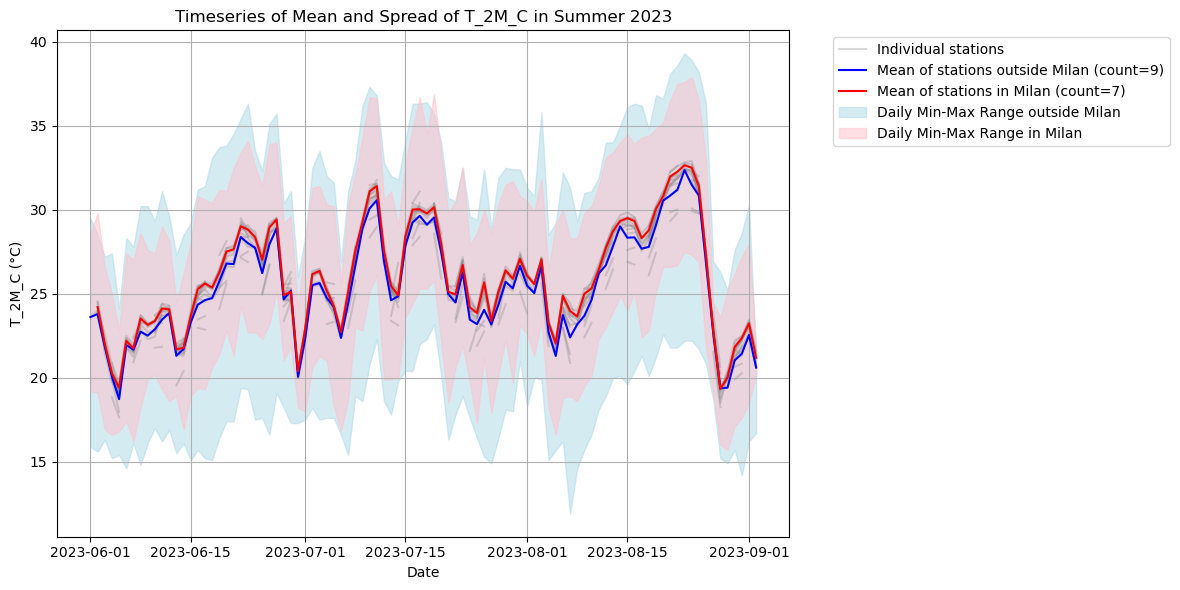

In [42]:
stat_T_2M_C_summer_2023 = compute_monthly_statistics(dataset_T_2M_C_summer_2023, 'T_2M_C')
#print(stat_T_2M_C_summer_2023.to_string())
plot_timeseries_mean_spread(dataset_T_2M_C_summer_2023, 'T_2M_C', 'Summer 2023')

### relative humidity

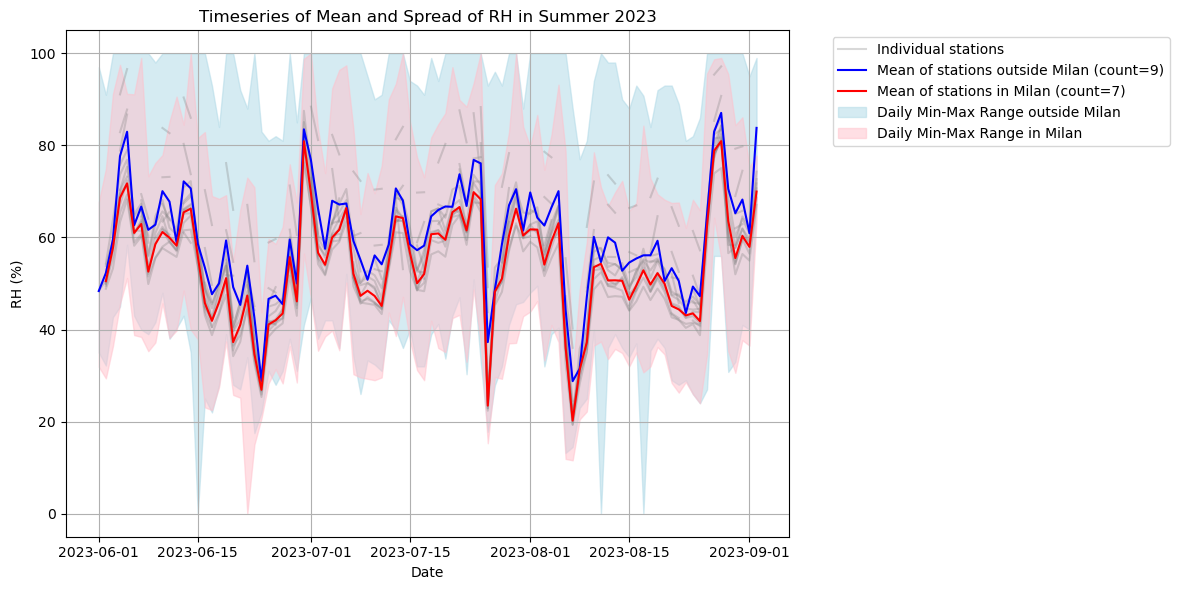

In [43]:

plot_timeseries_mean_spread(dataset_RH_summer_2023, 'RH', 'Summer 2023')

## Count number of accurate forecasts

In [55]:
def count_accurate_forecasts(dataset, var):
    """
    Count the number and proportion of times each model has made a more accurate forecast than the others.
    var: the name of the variable in the dataset (e.g., 'T_2M_C', 'RH')
    """
    # Prepare the data
    if var == 'T_2M_C':
        models = [f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']
    elif var == 'RH':
        models = [f'MOLOCH_{var}', f'UNARETI_{var}']
    else:
        print(f'var {var} not understood')
        return

    # Define station groups
    stations_milan = ['Milano v.Brera', 'Milano San Siro', 'MILANO Bicocca', 'MILANO Bocconi', 'MILANO Bovisa', 'MILANO Città Studi', 'MILANO Sud']
    stations_outside = list(set(dataset['OLD_STATION_NAME'].unique()) - set(stations_milan))

    # Calculate absolute errors
    for model in models:
        dataset[f'{model}_ERROR'] = (dataset[model] - dataset[f'OBSERVATION_{var}']).abs()

    # Initialize counters
    counts_milan = {model: 0 for model in models}
    counts_outside = {model: 0 for model in models}
    total_forecasts_milan = 0
    total_forecasts_outside = 0

    # Iterate over each trade date
    for trade_date in dataset['TRADE_DATE'].unique():
        trade_data = dataset[dataset['TRADE_DATE'] == trade_date]
        if not trade_data.empty:
            # Milan stations
            trade_data_milan = trade_data[trade_data['OLD_STATION_NAME'].isin(stations_milan)]
            if not trade_data_milan.empty:
                total_forecasts_milan += 1
                min_error_model_milan = trade_data_milan[[f'{model}_ERROR' for model in models]].mean().idxmin()
                min_error_model_milan = min_error_model_milan.replace('_ERROR', '')
                counts_milan[min_error_model_milan] += 1

            # Outside stations
            trade_data_outside = trade_data[trade_data['OLD_STATION_NAME'].isin(stations_outside)]
            if not trade_data_outside.empty:
                total_forecasts_outside += 1
                min_error_model_outside = trade_data_outside[[f'{model}_ERROR' for model in models]].mean().idxmin()
                min_error_model_outside = min_error_model_outside.replace('_ERROR', '')
                counts_outside[min_error_model_outside] += 1

    # Calculate proportions
    proportions_milan = {model: count / total_forecasts_milan for model, count in counts_milan.items()}
    proportions_outside = {model: count / total_forecasts_outside for model, count in counts_outside.items()}

    return counts_milan, proportions_milan, counts_outside, proportions_outside


### 2m temperature

In [45]:
counts_milan, proportions_milan, counts_outside, proportions_outside = count_accurate_forecasts(dataset_T_2M_C_summer_2023, 'T_2M_C')
print("Counts:")
print('Milan', counts_milan)
print('Outside', counts_outside)
print("Proportions:")
print('Milan', proportions_milan)
print('Outside', proportions_outside)

Counts:
Milan {'ECOP_T_2M_C': 15, 'MOLOCH_T_2M_C': 77, 'UNARETI_T_2M_C': 92}
Outside {'ECOP_T_2M_C': 20, 'MOLOCH_T_2M_C': 72, 'UNARETI_T_2M_C': 92}
Proportions:
Milan {'ECOP_T_2M_C': 0.08152173913043478, 'MOLOCH_T_2M_C': 0.41847826086956524, 'UNARETI_T_2M_C': 0.5}
Outside {'ECOP_T_2M_C': 0.10869565217391304, 'MOLOCH_T_2M_C': 0.391304347826087, 'UNARETI_T_2M_C': 0.5}


### relative humidity

In [46]:
counts_milan_RH, proportions_milan_RH, counts_outside_RH, proportions_outside_RH = count_accurate_forecasts(dataset_RH_summer_2023, 'RH')
print("Counts:")
print('Milan', counts_milan_RH)
print('Outside', counts_outside_RH)
print("Proportions:")
print('Milan', proportions_milan_RH)
print('Outside', proportions_outside_RH)

Counts:
Milan {'MOLOCH_RH': 92, 'UNARETI_RH': 92}
Outside {'MOLOCH_RH': 92, 'UNARETI_RH': 92}
Proportions:
Milan {'MOLOCH_RH': 0.5, 'UNARETI_RH': 0.5}
Outside {'MOLOCH_RH': 0.5, 'UNARETI_RH': 0.5}


## Map the errors

In [47]:
def create_map_rmse(dataset, var, name):
    """
    Create a map with points at the location of the gridpoints from ECOP, MOLOCH, UNARETI, and the stations.
    Each point will have a color representing the RMSE of the model at that location over the whole summer.
    var: the name of the variable in the dataset (e.g., 'T_2M_C', 'RH')
    name: the string used as name complement for the plot
    """

    # Prepare the data
    if var == 'T_2M_C':
        models = [f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']
    elif var == 'RH':
        models = [f'MOLOCH_{var}', f'UNARETI_{var}']
    else:
        print(f'var {var} not understood')
        return
    
    # group of stations
    stations_milan = ['Milano v.Brera', 'MILANO San Siro', 'MILANO Bicocca', 'MILANO Bocconi', 'MILANO Bovisa', 'MILANO Città Studi', 'MILANO Sud']
    stations_outside = list(set(dataset['OLD_STATION_NAME'].unique()) - set(stations_milan))

    # Calculate RMSE for each model
    rmse_data = {}
    for model in models:
        dataset[f'{model}_ERROR'] = (dataset[model] - dataset[f'OBSERVATION_{var}']) ** 2
        lat_col = f'LAT_{model.split("_")[0]}'
        lon_col = f'LON_{model.split("_")[0]}'
        rmse_data[model] = dataset.groupby([lat_col, lon_col])[f'{model}_ERROR'].mean().apply(np.sqrt).reset_index()
        rmse_data[model] = rmse_data[model].rename(columns={f'{model}_ERROR': 'RMSE', lat_col: 'LAT', lon_col: 'LON'})

    # Create a map centered around the average location of the stations
    avg_lat = np.mean(dataset['LAT_STATION'])
    avg_lon = np.mean(dataset['LON_STATION'])
    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=10)


    # Create a colormap
    colormap = plt.get_cmap('Reds')
    norm = plt.Normalize(vmin=0, vmax=max([rmse_data[model]['RMSE'].max() for model in models]))

    # add the colorbar to the map
    sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array([])
    
    # Create a figure and axis to add the colorbar with transparent background
    fig, ax = plt.subplots(figsize=(6, 1))
    fig.patch.set_alpha(0.0)  # Set the figure background to transparent
    fig.subplots_adjust(bottom=0.5)
    cbar = plt.colorbar(sm, cax=ax, orientation='horizontal')
    cbar.set_label('RMSE')
    

    # Add gridpoints to the map
    for model in models:
        for _, row in rmse_data[model].iterrows():
            color = colormap(norm(row['RMSE']))
            if model==f'ECOP_{var}':
                icon_circle = BeautifyIcon(
                    icon='circle',
                    background_color=mcolors.rgb2hex(color),
                    border_color=mcolors.rgb2hex(color),
                    border_width=1
                    )
                folium.Marker(
                    location=[row['LAT'], row['LON']],
                    icon=icon_circle,
                    popup=f"{model.split('_')[0]} RMSE: {row['RMSE']:.2f}"
                    ).add_to(m)
            elif model==f'MOLOCH_{var}':
                icon_square = BeautifyIcon(
                    icon='square',
                    background_color=mcolors.rgb2hex(color),
                    border_color=mcolors.rgb2hex(color),
                    border_width=1
                )
                folium.Marker(
                    location=[row['LAT'], row['LON']],
                    icon=icon_square,
                    popup=f"{model.split('_')[0]} RMSE: {row['RMSE']:.2f}"
                ).add_to(m)
            elif model==f'UNARETI_{var}':
                icon_star = BeautifyIcon(
                    icon='star',
                    background_color=mcolors.rgb2hex(color),
                    border_color=mcolors.rgb2hex(color),
                    border_width=1
                )
                folium.Marker(
                    location=[row['LAT'], row['LON']],
                    icon=icon_star,
                    popup=f"{model.split('_')[0]} RMSE: {row['RMSE']:.2f}"
                ).add_to(m)

    # Add stations to the map
    stations = dataset[['LAT_STATION', 'LON_STATION', 'OLD_STATION_NAME']].drop_duplicates()
    for _, row in stations.iterrows():
        print(row['OLD_STATION_NAME'])
        if row['OLD_STATION_NAME'] in stations_milan:
            icon = folium.Icon(color='black', icon='info-sign')
        else:
            icon = folium.Icon(color='blue', icon='info-sign')
        folium.Marker(
            location=[row['LAT_STATION'], row['LON_STATION']],
            popup=f"Station: {row['OLD_STATION_NAME']}",
            icon=icon
        ).add_to(m)

    # Add a legend
    legend_html = """
    <div style="position: fixed; 
                bottom: 50px; left: 50px; width: 200px; height: 120px; 
                border:2px solid grey; z-index:9999; font-size:14px;
                background-color: white;
                opacity: 0.8;
                ">
    <p style="margin: 10px">Legend</p>
    <p style="margin: 10px"><i class="fa fa-circle" style="color:black"></i> ECOP</p>
    <p style="margin: 10px"><i class="fa fa-square" style="color:black"></i> MOLOCH</p>
    <p style="margin: 10px"><i class="fa fa-star" style="color:black"></i> UNARETI</p>
    </div>
    """

    m.get_root().html.add_child(folium.Element(legend_html))

    return m


In [48]:
def create_map_bias(dataset, var, name):
    """
    Create a map with points at the location of the gridpoints from ECOP, MOLOCH, UNARETI, and the stations.
    Each point will have a color representing the average overestimation or underestimation of the model at that location over the whole summer.
    var: the name of the variable in the dataset (e.g., 'T_2M_C', 'RH')
    name: the string used as name complement for the plot
    """

    # Prepare the data
    if var == 'T_2M_C':
        models = [f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']
    elif var == 'RH':
        models = [f'MOLOCH_{var}', f'UNARETI_{var}']
    else:
        print(f'var {var} not understood')
        return
    
    # group of stations
    stations_milan = ['Milano v.Brera', 'MILANO San Siro', 'MILANO Bicocca', 'MILANO Bocconi', 'MILANO Bovisa', 'MILANO Città Studi', 'MILANO Sud']

    # Calculate bias for each model
    bias_data = {}
    for model in models:
        dataset[f'{model}_BIAS'] = dataset[model] - dataset[f'OBSERVATION_{var}']
        lat_col = f'LAT_{model.split("_")[0]}'
        lon_col = f'LON_{model.split("_")[0]}'
        bias_data[model] = dataset.groupby([lat_col, lon_col])[f'{model}_BIAS'].mean().reset_index()
        bias_data[model] = bias_data[model].rename(columns={f'{model}_BIAS': 'BIAS', lat_col: 'LAT', lon_col: 'LON'})

    # add a column for the associated station
    for model in models:
        bias_data[model] = bias_data[model].merge(dataset[['LAT_STATION', 'LON_STATION', 'OLD_STATION_NAME']], left_on=['LAT', 'LON'], right_on=['LAT_STATION', 'LON_STATION'], how='left')

    # Create a map centered around the average location of the stations
    avg_lat = np.mean(dataset['LAT_STATION'])
    avg_lon = np.mean(dataset['LON_STATION'])
    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=10)

    # Create a colormap centered on 0
    colormap = plt.get_cmap('coolwarm')
    max_bias = max([bias_data[model]['BIAS'].max() for model in models])
    min_bias = min([bias_data[model]['BIAS'].min() for model in models])
    abs_max = max(abs(min_bias), abs(max_bias))
    norm = plt.Normalize(vmin=-abs_max, vmax=abs_max, clip=True)

    # add the colorbar to the map
    sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array([])
    
    # Create a figure and axis to add the colorbar with transparent background
    fig, ax = plt.subplots(figsize=(6, 1))
    fig.patch.set_alpha(0.0)  # Set the figure background to transparent
    fig.subplots_adjust(bottom=0.5)
    cbar = plt.colorbar(sm, cax=ax, orientation='horizontal')
    cbar.set_label('Bias')

    # Add gridpoints to the map
    for model in models:
        print(model)
        for _, row in bias_data[model].iterrows():
            color = colormap(norm(row['BIAS']))
            if model==f'ECOP_{var}':
                icon_circle = BeautifyIcon(
                    icon='circle',
                    background_color=mcolors.rgb2hex(color),
                    border_color=mcolors.rgb2hex(color),
                    border_width=1
                    )
                folium.Marker(
                    location=[row['LAT'], row['LON']],
                    icon=icon_circle,
                    popup=f"{model.split('_')[0]} Bias: {row['BIAS']:.2f}"
                    ).add_to(m)
            elif model==f'MOLOCH_{var}':
                icon_square = BeautifyIcon(
                    icon='square',
                    background_color=mcolors.rgb2hex(color),
                    border_color=mcolors.rgb2hex(color),
                    border_width=1
                )
                folium.Marker(
                    location=[row['LAT'], row['LON']],
                    icon=icon_square,
                    popup=f"{model.split('_')[0]} Bias: {row['BIAS']:.2f}"
                ).add_to(m)
            elif model==f'UNARETI_{var}':
                icon_star = BeautifyIcon(
                    icon='star',
                    background_color=mcolors.rgb2hex(color),
                    border_color=mcolors.rgb2hex(color),
                    border_width=1
                )
                folium.Marker(
                    location=[row['LAT'], row['LON']],
                    icon=icon_star,
                    popup=f"{model.split('_')[0]} Bias: {row['BIAS']:.2f}"
                ).add_to(m)

    # Add stations to the map
    stations = dataset[['LAT_STATION', 'LON_STATION', 'OLD_STATION_NAME']].drop_duplicates()
    for _, row in stations.iterrows():
        if row['OLD_STATION_NAME'] in stations_milan:
            icon = folium.Icon(color='black', icon='info-sign')
        else:
            icon = folium.Icon(color='blue', icon='info-sign')
        folium.Marker(
            location=[row['LAT_STATION'], row['LON_STATION']],
            popup=f"Station: {row['OLD_STATION_NAME']}",
            icon=icon
        ).add_to(m)

    # Add a legend
    legend_html = """
    <div style="position: fixed; 
                bottom: 50px; left: 50px; width: 200px; height: 120px; 
                border:2px solid grey; z-index:9999; font-size:14px;
                background-color: white;
                opacity: 0.8;
                ">
    <p style="margin: 10px">Legend</p>
    <p style="margin: 10px"><i class="fa fa-circle" style="color:black"></i> ECOP</p>
    <p style="margin: 10px"><i class="fa fa-square" style="color:black"></i> MOLOCH</p>
    <p style="margin: 10px"><i class="fa fa-star" style="color:black"></i> UNARETI</p>
    </div>
    """

    m.get_root().html.add_child(folium.Element(legend_html))

    return m

### 2m temperature

Bergamo v.Stezzano
Brescia v.Ziziola
Casalbuttano ed Uniti
MILANO Forze Armate
Milano Lambrate
Milano v.Brera
Osio Sotto v.per Levate
lmb249
lmb319
lmb499
MILANO Bicocca
MILANO Bocconi
MILANO Bovisa
MILANO Città Studi
MILANO San Siro
MILANO Sud


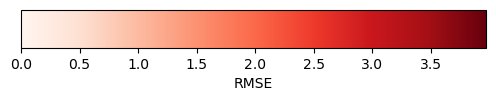

In [49]:
m = create_map_rmse(dataset_T_2M_C_summer_2023, var='T_2M_C', name='Summer 2023')
m.save('map_rmse_temp.html')
m

ECOP_T_2M_C
MOLOCH_T_2M_C
UNARETI_T_2M_C


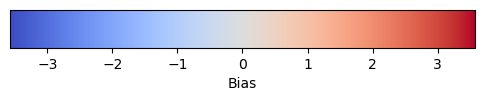

In [50]:
m= create_map_bias(dataset_T_2M_C_summer_2023, var='T_2M_C', name='Summer 2023')
m.save('map_bias_temp.html')
m

### relative humidity

Bergamo v.Stezzano
Brescia v.Ziziola
MILANO Forze Armate
Milano Lambrate
Milano v.Brera
Osio Sotto v.per Levate
lmb249
lmb319
lmb499
MILANO Bicocca
MILANO Bocconi
MILANO Bovisa
MILANO Città Studi
MILANO San Siro
MILANO Sud


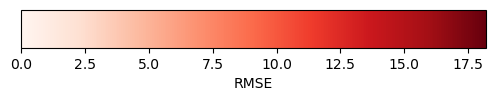

In [51]:
m=create_map_rmse(dataset_RH_summer_2023, var='RH', name='Summer 2023')
m.save('map_rmse_RH.html')
m


MOLOCH_RH
UNARETI_RH


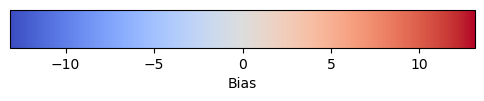

In [52]:
m=create_map_bias(dataset_RH_summer_2023, var='RH', name='Summer 2023')
m.save('map_bias_RH.html')
m

## Compare distributions

Forecast attributes looked at: bias, accuracy, sharpness, uncertainty

In [53]:
colors= {'OBSERVATION':'firebrick', 'ECOP':'orange', 'MOLOCH':'olivedrab', 'UNARETI':'coral'}

### 2m temperature

In [54]:
def plot_distribution(dataset, var, name):
    """
    Plot the distribution of temperature for each model and each gridpoint/station in the dataset.
    var: the name of the variable in the ECOP dataset (T_2M_C, RH)
    name: the string used as name complement for the plot
    """
    # Prepare the data
    if var=='T_2M_C':
        models = [f'OBSERVATION_{var}', f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']
    elif var=='RH':
        models = [f'OBSERVATION_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']
    else:
        print(f'var {var} not undestood')
        return
    
    data = {f"{model}_{station}": dataset[dataset['OLD_STATION_NAME'] == station][model].dropna().values 
            for model in models for station in dataset['OLD_STATION_NAME'].unique()}

    # Filter out empty arrays (becasue of how the dataset was created)
    data = {key: value for key, value in data.items() if len(value) > 0}

    # Create the plot
    plt.figure(figsize=(24, 5))

    positions = []
    labels = []
    color_list = []
    pos = 1
    
    for station in dataset['OLD_STATION_NAME'].unique():
        for model in models:
            key = f"{model}_{station}"
            if key in data:
                positions.append(pos)
                labels.append(key)
                color_list.append(colors[model.split('_')[0]])
                pos += 1
        pos += 1  # Add space between different stations

    for i, key in enumerate(labels):

        # customizing the violin plot
        parts=plt.violinplot(data[key], positions=[positions[i]], showmeans=False, showmedians=True, widths=0.7)
        for pc in parts['bodies']:
            pc.set_facecolor(color_list[i])
            pc.set_alpha(1)
        for partname in ('cbars','cmins','cmaxes','cmedians'):
            vp = parts[partname]
            vp.set_edgecolor('k')
            vp.set_linewidth(1)
        
        # Add scatter plot
        #plt.scatter([positions[i]] * len(data[key]), data[key], color=color_list[i], s=10, alpha=0.7)

    # Set x-ticks with station names and model labels    
    if var=='T_2M_C':
        xticks_labels = [labels[i].split('_')[4] if labels[i].split('_')[0]=='OBSERVATION' else 'ECOP' if labels[i].split('_')[0]=='ECOP' else 'MOLOCH' if labels[i].split('_')[0]=='MOLOCH' else f'RAMSAESZ/WRFAESZ' for i in range(len(labels))]
    elif var=='RH':
        xticks_labels = [labels[i].split('_')[2] if labels[i].split('_')[0]=='OBSERVATION' else 'MOLOCH' if labels[i].split('_')[0]=='MOLOCH' else f'RAMSAESZ/WRFAESZ' for i in range(len(labels))]


    plt.xticks(ticks=positions, labels=xticks_labels, rotation=90)
    plt.title(f'{var} in {name} for Each Gridpoint/Station')
    plt.ylabel(f'{var} (°C)')
    plt.xlabel('Model and Gridpoint/Station')

    # Add color legend
    for model, color in colors.items():
        plt.plot([], [], color=color, label=model)
    #plt.legend()

    plt.show()


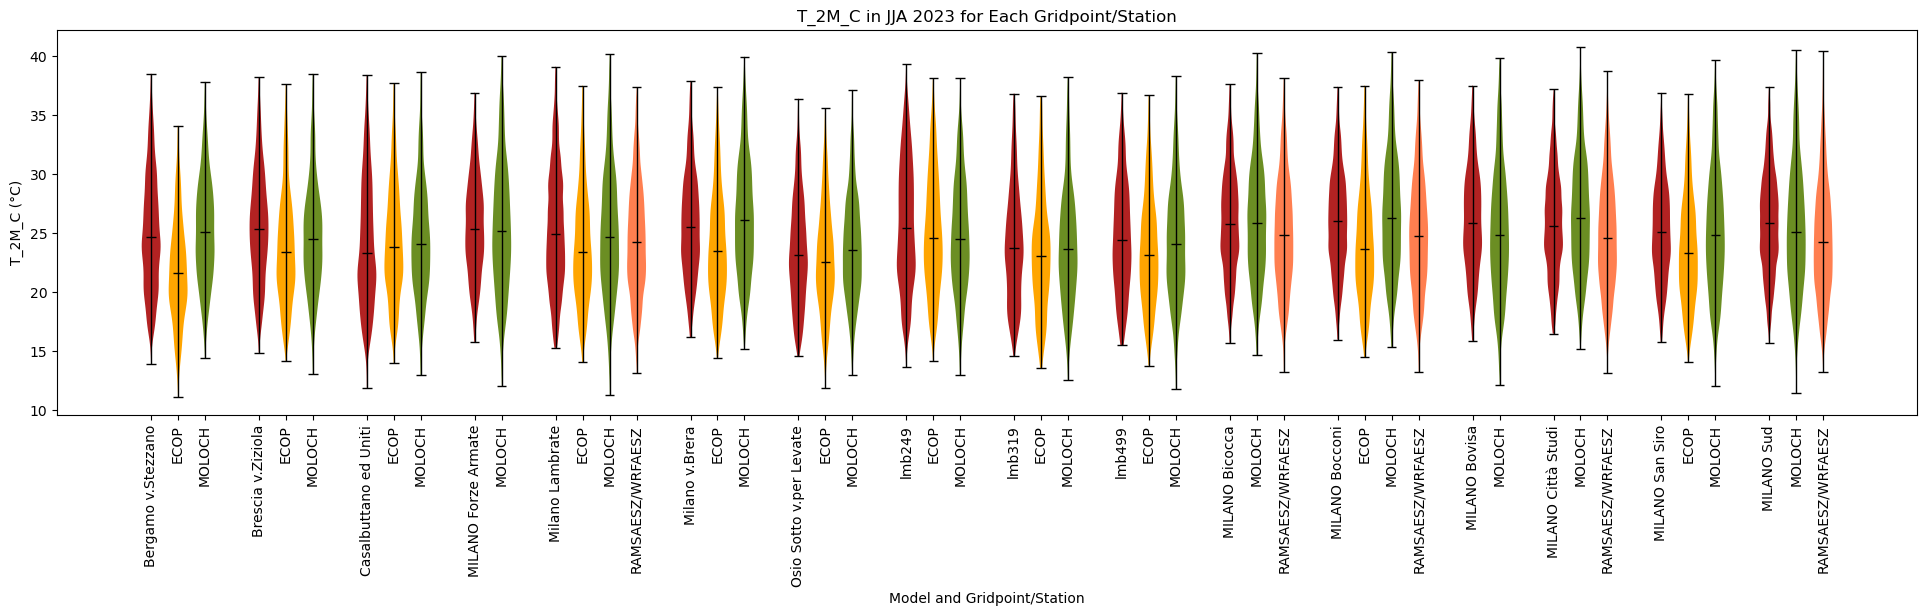

In [55]:
plot_distribution(dataset_T_2M_C_summer_2023, var='T_2M_C', name='JJA 2023')
#plot_temperature_distribution(dataset_T_2M_C_summer_2022, name='JJA 2022')


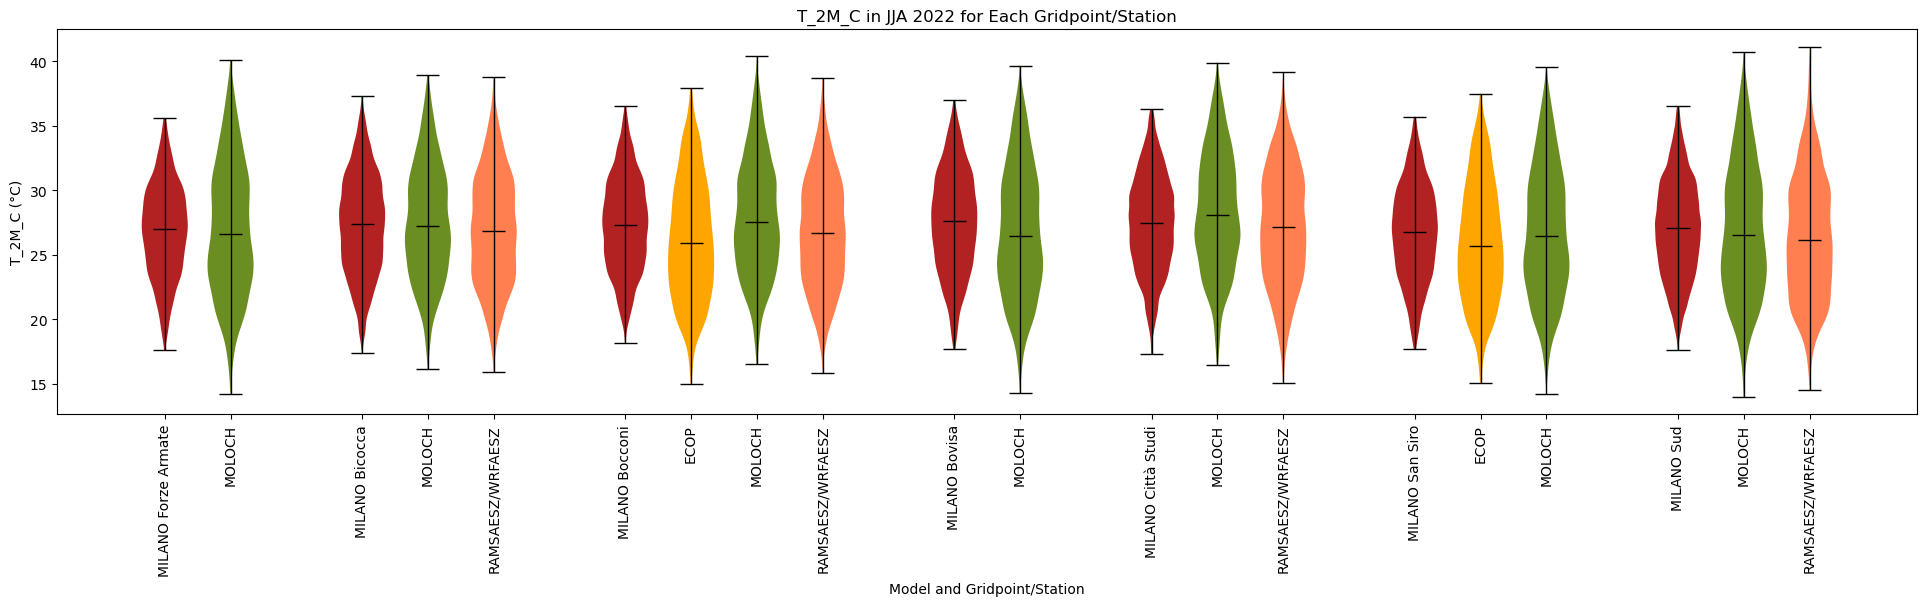

In [56]:
plot_distribution(dataset_T_2M_C_summer_2022, var='T_2M_C', name='JJA 2022')

In [57]:
def plot_max_daily_temperature(dataset, name='JJA 2023'):
    """
    Plot the maximum daily temperature for each model and each gridpoint/station in the dataset.
    """
    # Prepare the data
    var='T_2M_C'
    models = [f'OBSERVATION_{var}', f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']
    data = {f"{model}_{station}": dataset[dataset['OLD_STATION_NAME'] == station].groupby(dataset['VALID_DATE'].dt.date)[model].max().dropna().values 
            for model in models for station in dataset['OLD_STATION_NAME'].unique()}

    # Filter out empty arrays (because of how the dataset was created)
    data = {key: value for key, value in data.items() if len(value) > 0}

    # Create the plot
    plt.figure(figsize=(24, 5))
    
    # Assign colors to models using cmocean colormap "phase"
    positions = []
    labels = []
    color_list = []
    pos = 1
    
    for station in dataset['OLD_STATION_NAME'].unique():
        for model in models:
            key = f"{model}_{station}"
            if key in data:
                positions.append(pos)
                labels.append(key)
                color_list.append(colors[model.split('_')[0]])
                pos += 1
        pos += 1  # Add space between different stations

    for i, key in enumerate(labels):
        # customizing the violin plot
        parts = plt.violinplot(data[key], positions=[positions[i]], showmeans=False, showmedians=True, widths=0.7)
        for pc in parts['bodies']:
            pc.set_facecolor(color_list[i])
            pc.set_alpha(1)
        for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
            vp = parts[partname]
            vp.set_edgecolor('k')
            vp.set_linewidth(1)
        
    # Set x-ticks with station names and model labels
    xticks_labels = [labels[i].split('_')[4] if labels[i].split('_')[0] == 'OBSERVATION' else 'ECOP' if labels[i].split('_')[0] == 'ECOP' else 'MOLOCH' if labels[i].split('_')[0] == 'MOLOCH' else 'RAMSAESZ/WRFAESZ' for i in range(len(labels))]

    plt.xticks(ticks=positions, labels=xticks_labels, rotation=90)
    plt.title(f'Maximum Daily Temperature in {name} Distribution for Each Gridpoint/Station')
    plt.ylabel('Temperature (°C)')
    plt.xlabel('Model and Gridpoint/Station')

    # Add color legend
    for model, color in colors.items():
        plt.plot([], [], color=color, label=model)
    #plt.legend()

    plt.show()

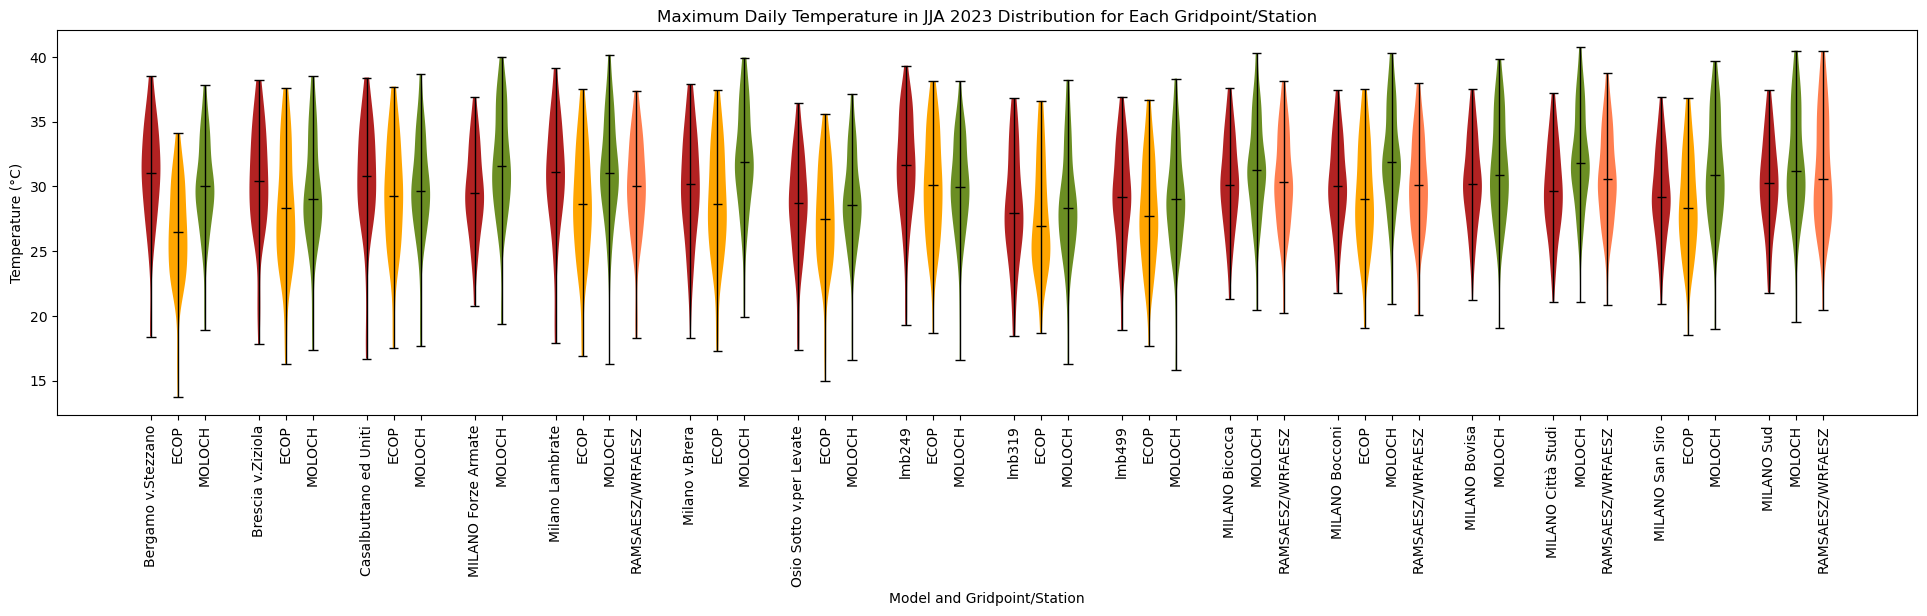

In [58]:
plot_max_daily_temperature(dataset_T_2M_C_summer_2023)
#plot_max_daily_temperature(dataset_T_2M_C_summer_2022)

### Relative Humidity


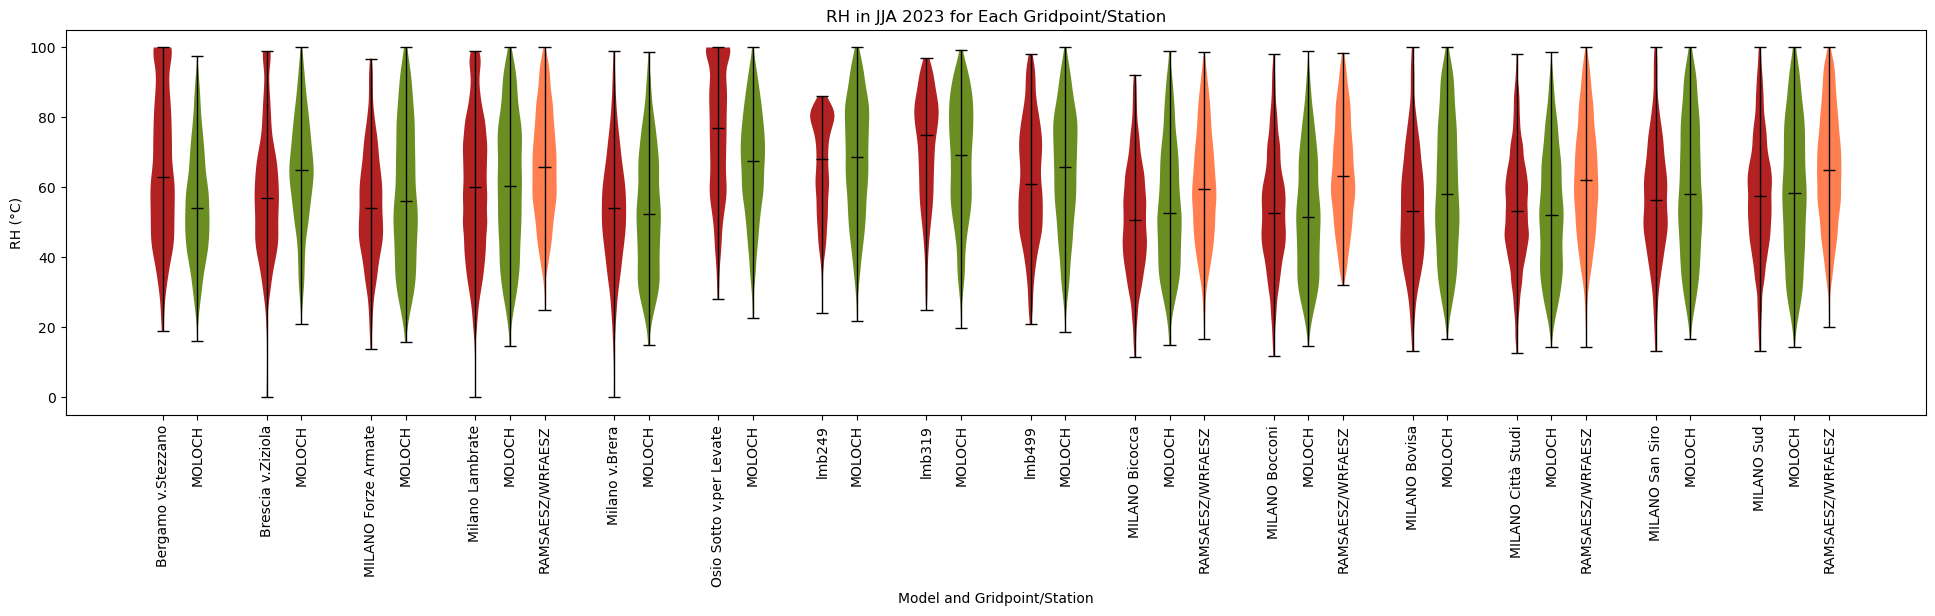

In [59]:
plot_distribution(dataset_RH_summer_2023, var='RH', name='JJA 2023')

## Scatter plot forecast vs. obs

In [60]:
def compute_correlations(dataset, var):
    """
    Compute the Spearman and Pearson correlation coefficients for each model against the observations.
    var: the name of the variable in the dataset (e.g., 'T_2M_C', 'RH')
    """
    # Prepare the data
    if var == 'T_2M_C':
        models = [f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']
    elif var == 'RH':
        models = [f'MOLOCH_{var}', f'UNARETI_{var}']
    else:
        print(f'var {var} not understood')
        return

    results = {}
    for model in models:
        # Drop NaN values for the current model and observations
        valid_data = dataset.dropna(subset=[f'OBSERVATION_{var}', model])
        if not valid_data.empty:
            # Compute Spearman rank correlation coefficient
            spearman_corr, spearman_p_value = spearmanr(valid_data[f'OBSERVATION_{var}'], valid_data[model])
            # Compute Pearson correlation coefficient
            pearson_corr, pearson_p_value = pearsonr(valid_data[f'OBSERVATION_{var}'], valid_data[model])
            results[model] = {
                'spearman_correlation': spearman_corr,
                'spearman_p_value': spearman_p_value,
                'pearson_correlation': pearson_corr,
                'pearson_p_value': pearson_p_value
            }
        else:
            results[model] = {
                'spearman_correlation': None,
                'spearman_p_value': None,
                'pearson_correlation': None,
                'pearson_p_value': None
            }

    return results


In [61]:
def plot_scatter_forecast_vs_obs(dataset, var, name):
    """
    Plot the scatter plot of the model forecast vs. the corresponding station value, time per time and station per station.
    One model is associated to one color.
    var: the name of the variable in the dataset (T_2M_C, RH)
    name: the string used as name complement for the plot
    """
    # Prepare the data
    if var == 'T_2M_C':
        models = [f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']
    elif var == 'RH':
        models = [f'MOLOCH_{var}', f'UNARETI_{var}']
    else:
        print(f'var {var} not understood')
        return

    # Compute correlations
    correlations = compute_correlations(dataset, var)

    # Create the plot
    plt.figure(figsize=(12, 8))
    
    # Assign colors to models using seaborn color palette
    color_map = {model: colors[model.split('_')[0]] for i, model in enumerate(models)}

    for model in models:
        plt.scatter(dataset[f'OBSERVATION_{var}'], dataset[model], color=color_map[model], label=model, alpha=0.5, s=10)

    # Plot the 1:1 line
    min_val = min(dataset[f'OBSERVATION_{var}'].min(), dataset[models[0]].min())
    max_val = max(dataset[f'OBSERVATION_{var}'].max(), dataset[models[0]].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)

    plt.xlabel(f'Observed {var}')
    plt.ylabel(f'Forecast {var}')
    plt.title(f'Scatter Plot of Forecast vs. Observed {var} in {name}')
    plt.legend()
    plt.grid(True)

    # Add correlation coefficients box
    textstr = '\n'.join([f"{model.split('_')[0]}: Spearman={correlations[model]['spearman_correlation']:.2f}, Pearson={correlations[model]['pearson_correlation']:.2f}" for model in models])
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
                   verticalalignment='top', bbox=props)

    plt.show()

### 2m temperature

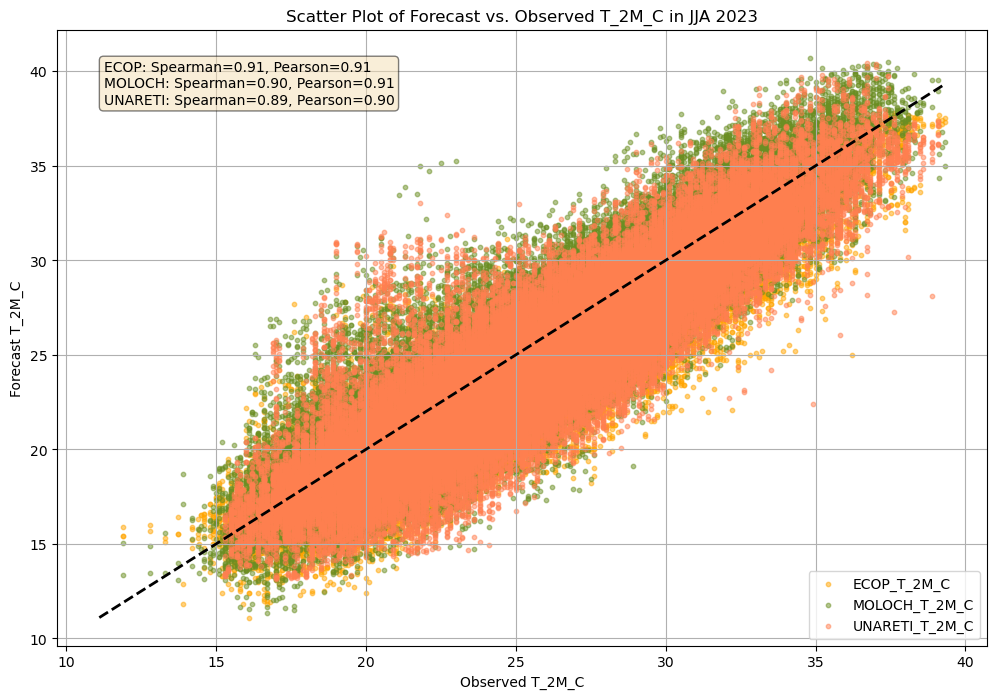

In [62]:
plot_scatter_forecast_vs_obs(dataset_T_2M_C_summer_2023, var='T_2M_C', name='JJA 2023')

In [63]:
def plot_max_daily_temperature_forecast_vs_obs(dataset, name='JJA 2023'):
    """
    Plot the scatter plot of the maximum daily temperature forecast vs. the corresponding station value, time per time and station per station.
    One model is associated to one color.
    """
    # Prepare the data
    var = 'T_2M_C'
    models = [f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']
    
    # Group by date and station, and get the maximum daily temperature
    max_daily_obs = dataset.groupby([dataset['VALID_DATE'].dt.date, 'OLD_STATION_NAME'])[f'OBSERVATION_{var}'].max().reset_index()
    max_daily_forecasts = {model: dataset.groupby([dataset['VALID_DATE'].dt.date, 'OLD_STATION_NAME'])[model].max().reset_index() for model in models}
    
    # Merge the observations with each forecast model
    merged_data = max_daily_obs
    for model in models:
        merged_data = pd.merge(merged_data, max_daily_forecasts[model], on=['VALID_DATE', 'OLD_STATION_NAME'], suffixes=('', f'_{model}'))
    
    # Compute correlations
    correlations = compute_correlations(merged_data, var)
    
    # Create the plot
    plt.figure(figsize=(12, 8))

    for model in models:
        plt.scatter(merged_data[f'OBSERVATION_{var}'], merged_data[model], color=colors[model.split('_')[0]], label=model, alpha=0.5)

    # Plot the 1:1 line
    min_val = min(merged_data[f'OBSERVATION_{var}'].min(), merged_data[models[0]].min())
    max_val = max(merged_data[f'OBSERVATION_{var}'].max(), merged_data[models[0]].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)

    plt.xlabel(f'Observed Max Daily {var}')
    plt.ylabel(f'Forecast Max Daily {var}')
    plt.title(f'Scatter Plot of Max Daily Forecast vs. Observed {var} in {name}')
    plt.legend()
    plt.grid(True)

    # Add correlation coefficients box
    textstr = '\n'.join([f"{model.split('_')[0]}: Spearman={correlations[model]['spearman_correlation']:.2f}, Pearson={correlations[model]['pearson_correlation']:.2f}" for model in models])
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
                   verticalalignment='top', bbox=props)

    plt.show()

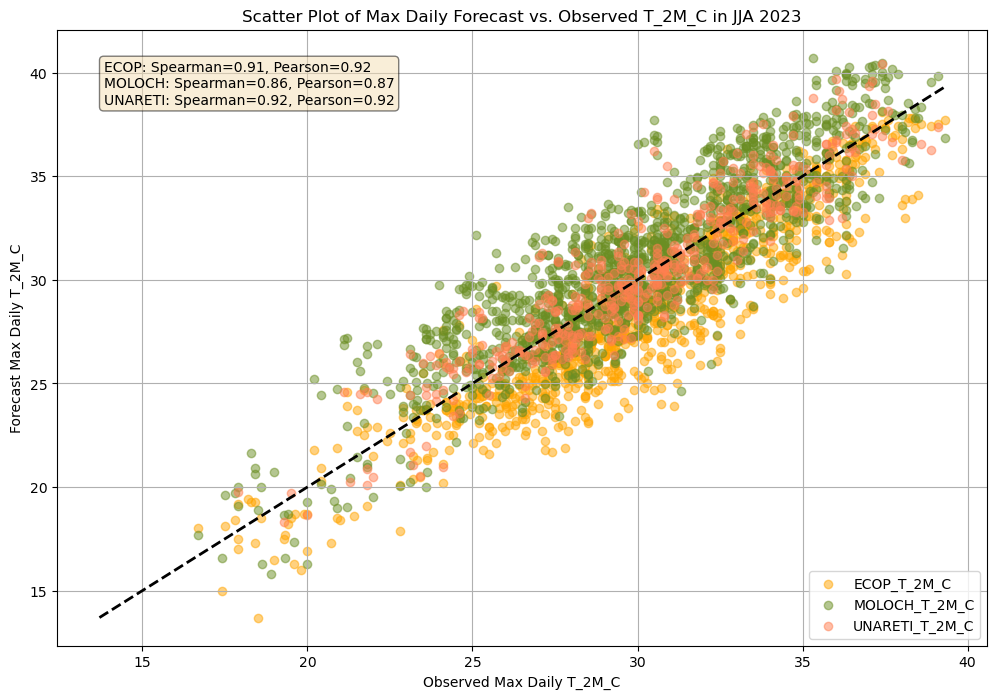

In [64]:
plot_max_daily_temperature_forecast_vs_obs(dataset_T_2M_C_summer_2023, name='JJA 2023')

In [65]:
def plot_time_offset_max_temp(dataset, var, name):
    """
    Plot the time offset at which the maximum temperature is reached (hour of VALID_DATE) between each model and the observations.
    var: the name of the variable in the dataset (T_2M_C)
    name: the string used as name complement for the plot
    """
    # Prepare the data
    models = [f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']

    # Group by date and station, and get the hour of maximum daily temperature
    max_temp_obs = dataset.groupby([dataset['VALID_DATE'].dt.date, 'OLD_STATION_NAME']).apply(lambda x: x.loc[x[f'OBSERVATION_{var}'].idxmax()]['VALID_DATE'].hour, include_groups=False).reset_index(name='OBS_HOUR')
    max_temp_forecasts = {model: dataset.groupby([dataset['VALID_DATE'].dt.date, 'OLD_STATION_NAME']).apply(lambda x: x.dropna(subset=[model]).loc[x[model].idxmax()]['VALID_DATE'].hour if not x.dropna(subset=[model]).empty else np.nan, include_groups=False).reset_index(name=f'{model}_HOUR') for model in models}

    # Merge the observations with each forecast model
    merged_data = max_temp_obs
    for model in models:
        merged_data = pd.merge(merged_data, max_temp_forecasts[model], on=['VALID_DATE', 'OLD_STATION_NAME'], suffixes=('', f'_{model}'))

    # Calculate the time offset
    for model in models:
        merged_data[f'{model}_OFFSET'] = merged_data[f'{model}_HOUR'] - merged_data['OBS_HOUR'] # offset is positive if the model is later than the observation
        
    # Plot the time offset
    fig, ax1 = plt.subplots(figsize=(12, 8))

    for model in models:
        ax1.hist(merged_data[f'{model}_OFFSET'].dropna(), bins=range(-12, 13), alpha=0.5, label=model, color=colors[model.split('_')[0]], align='left', density=True)
        
    ax1.set_xlabel('Time Offset (hours)')
    ax1.set_ylabel('Frequency')
    ax1.set_title(f'Time Offset at Which Maximum Temperature is Reached in {name}')
    ax1.legend()
    ax1.grid(True)


    plt.show()

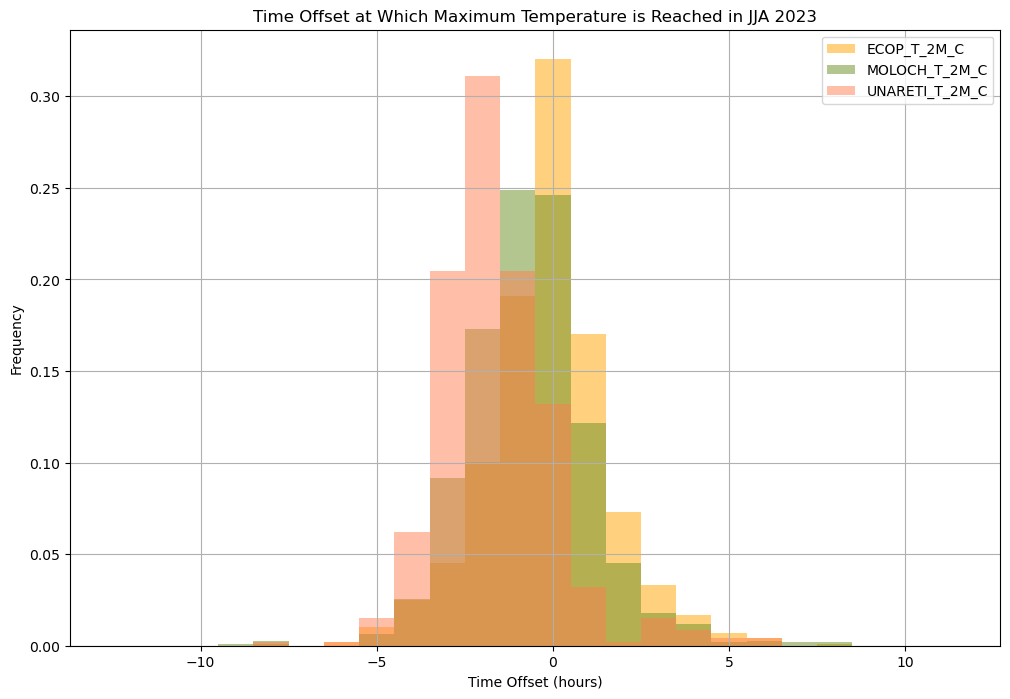

In [66]:
plot_time_offset_max_temp(dataset_T_2M_C_summer_2023, var='T_2M_C', name='JJA 2023')

### Relative Humidity

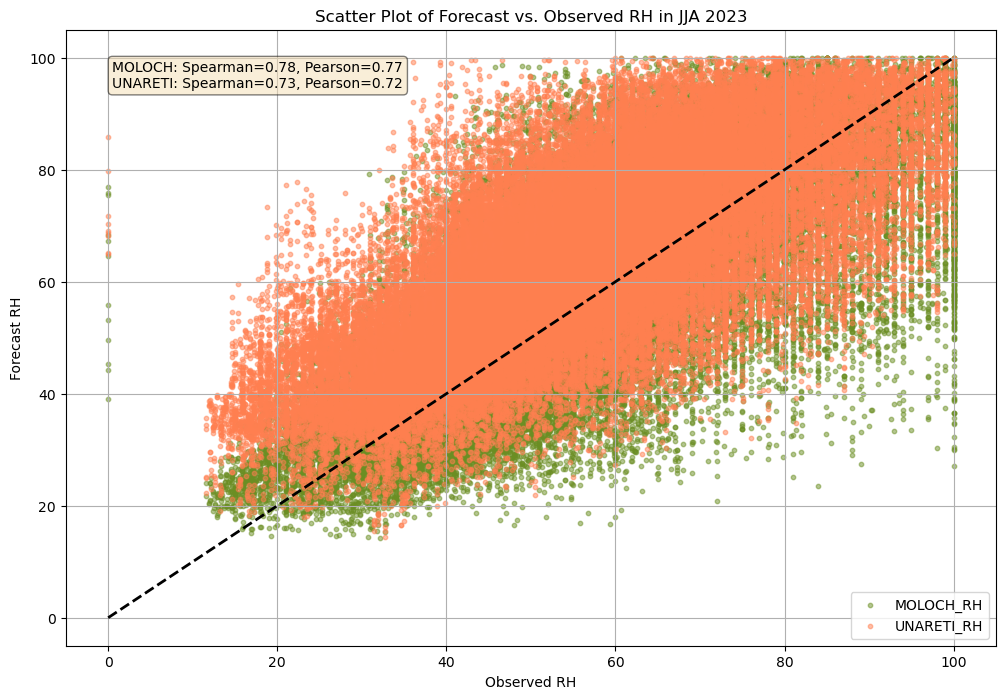

In [67]:
plot_scatter_forecast_vs_obs(dataset_RH_summer_2023, var='RH', name='JJA 2023')

## Timeseries

In [68]:
def plot_mean_timeseries_per_station(dataset, var, name):
    """
    Plot the mean timeseries of the forecast and observations per station.
    var: the name of the variable in the dataset (e.g., 'T_2M_C', 'RH')
    name: the string used as name complement for the plot
    """

    # Adjust UNARETI TRADE_DATE to 00Z the day after
    dataset['TRADE_DATE'] = np.where(dataset['TRADE_DATE'].dt.hour == 12, dataset['TRADE_DATE'] + pd.Timedelta(hours=12), dataset['TRADE_DATE'])

    # Prepare the data
    if var == 'T_2M_C':
        models = [f'OBSERVATION_{var}', f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']
    elif var == 'RH':
        models = [f'OBSERVATION_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']
    else:
        print(f'var {var} not understood')
        return

    # Compute leadtime
    dataset['LEADTIME'] = (dataset['VALID_DATE'] - dataset['TRADE_DATE']).dt.total_seconds() / 3600

    # Group by station and leadtime, and calculate the mean value for each model
    mean_leadtime = dataset.groupby(['LEADTIME', 'OLD_STATION_NAME'])[models].mean().reset_index()

    # Create the plot
    stations = mean_leadtime['OLD_STATION_NAME'].unique()
    num_stations = len(stations)
    fig, axes = plt.subplots(4, 4, figsize=(16, 10), sharex=True, sharey=True)

    if num_stations == 1:
        axes = [axes]

    # Plot the mean leadtime for each station
    for i, (ax, station) in enumerate(zip(axes.flatten(), stations)):
        station_data = mean_leadtime[mean_leadtime['OLD_STATION_NAME'] == station]
        for model in models:
            ax.plot(station_data['LEADTIME'], station_data[model], label=model.split('_')[0], color=colors[model.split('_')[0]])
        ax.set_ylabel(f'{var} (°C)' if var == 'T_2M_C' else f'{var} (%)')
        ax.set_title(f'{station}')
        ax.grid(True)
    
    axes[0,0].legend()
    axes[2,0].set_xlabel('Leadtime (hours)')
    plt.suptitle(f'Mean Leadtime of {var} for Each Station in {name}', fontsize=16)

    plt.tight_layout()
    plt.show()

### 2m temperature

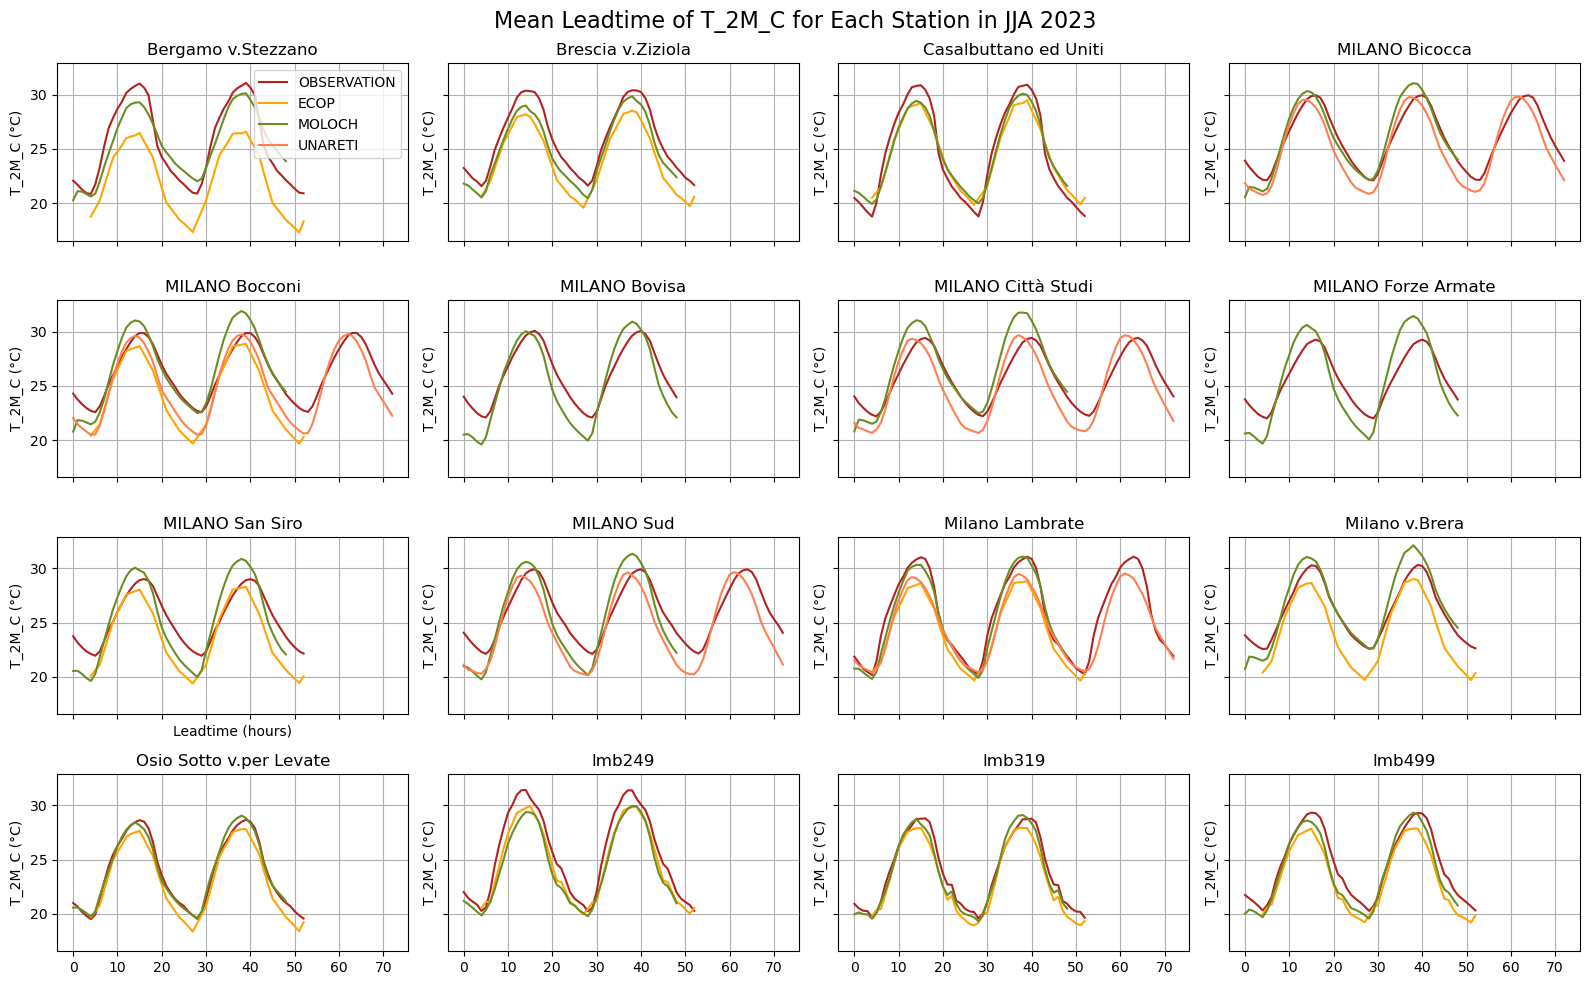

In [69]:
plot_mean_timeseries_per_station(dataset_T_2M_C_summer_2023, var='T_2M_C', name='JJA 2023')

### Relative humidity

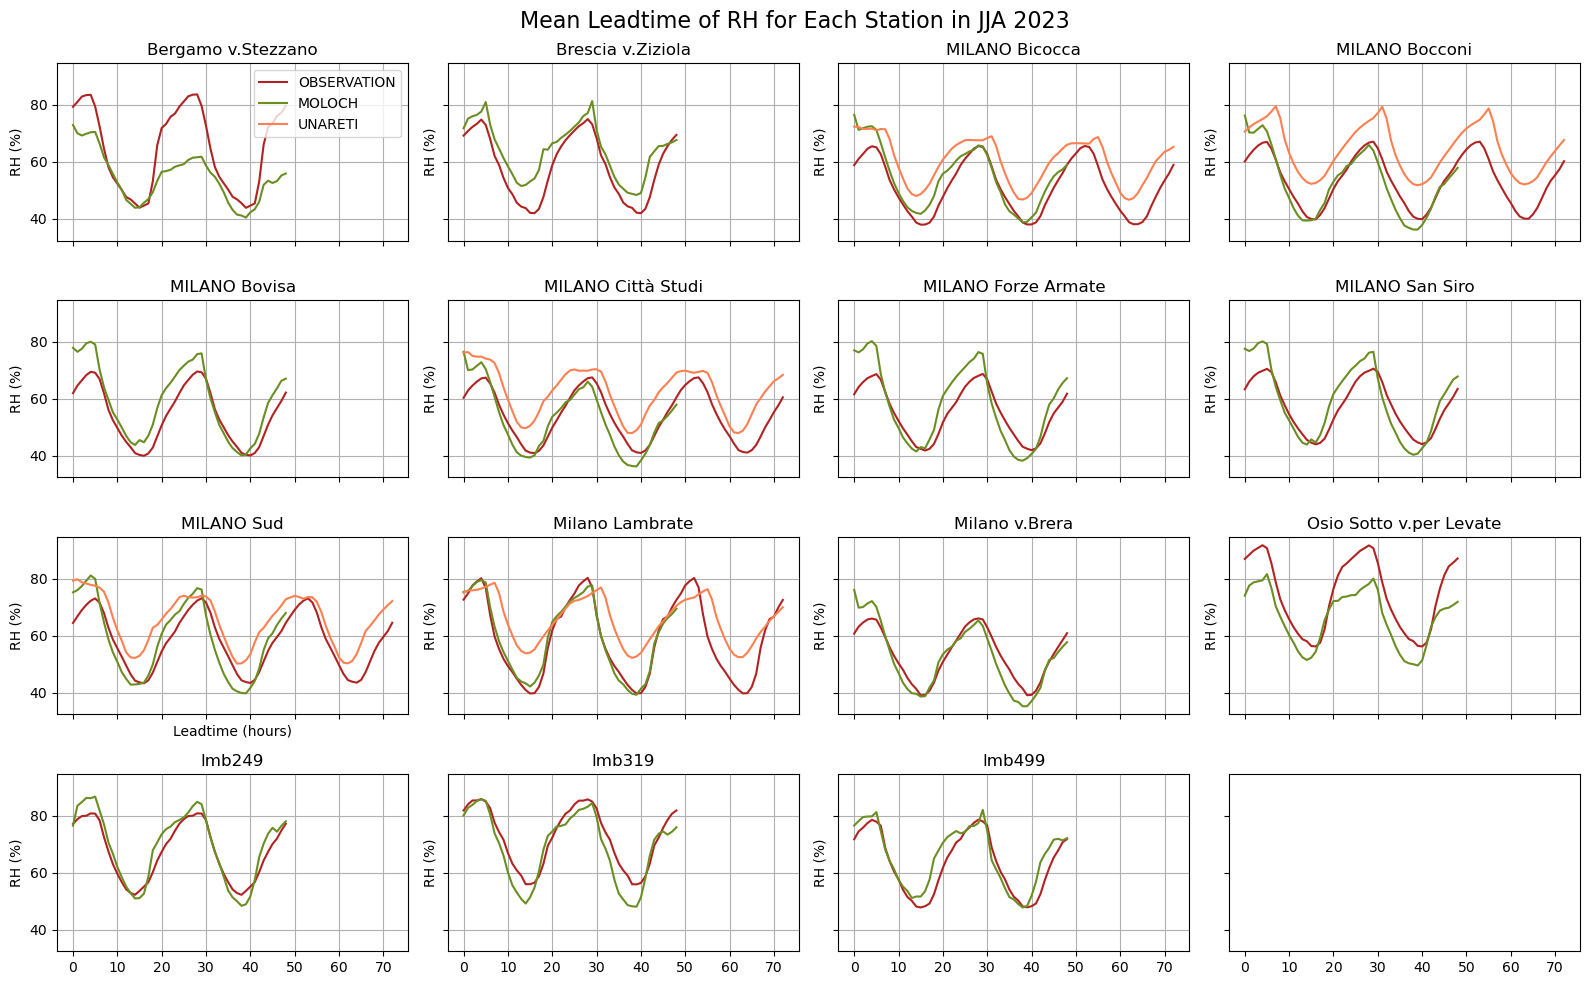

In [70]:
plot_mean_timeseries_per_station(dataset_RH_summer_2023, var='RH', name='JJA 2023')

## Compute RMSE of the timeseries

### 2m temperature

In [71]:
def plot_mean_forecast_error_with_leadtime(dataset, var, name):
    """
    Plot the mean forecast error of UNARETI, Moloch, and ECOP for the temperature with leadtime as the x-axis.
    The error is computed as forecast - observations before averaging over the forecasts.
    """

    unit={'T_2M_C':'°C', 'RH':'%'}

    stations_milano = ['Milano v.Brera', 'Milano San Siro',
                      'MILANO Bicocca', 'MILANO Bocconi', 'MILANO Bovisa',
                      'MILANO Città Studi', 'MILANO Sud']
    
    other_stations = list(set(dataset['OLD_STATION_NAME'].unique()) - set(stations_milano))

    # Adjust UNARETI TRADE_DATE to 00Z the day after
    dataset['TRADE_DATE'] = np.where(dataset['TRADE_DATE'].dt.hour == 12, dataset['TRADE_DATE'] + pd.Timedelta(hours=12), dataset['TRADE_DATE'])
    
    # Calculate leadtime in hours
    dataset['LEADTIME_HOURS'] = (dataset['VALID_DATE'] - dataset['TRADE_DATE']).dt.total_seconds() / 3600
    
    # Calculate forecast errors
    if var!='RH':
        dataset['ECOP_ERROR'] = dataset[f'ECOP_{var}'] - dataset[f'OBSERVATION_{var}']
    dataset['MOLOCH_ERROR'] = dataset[f'MOLOCH_{var}'] - dataset[f'OBSERVATION_{var}']
    dataset['UNARETI_ERROR'] = dataset[f'UNARETI_{var}'] - dataset[f'OBSERVATION_{var}']
    
    # Group by leadtime and compute the mean error for each model
    if var!='RH':
        numeric_columns = ['ECOP_ERROR', 'MOLOCH_ERROR', 'UNARETI_ERROR']
    else:
        numeric_columns = ['MOLOCH_ERROR', 'UNARETI_ERROR']

    # Compute RMSE per station
    rmse_per_station = dataset.groupby('OLD_STATION_NAME').apply(
        lambda x: pd.Series({
           # 'RMSE_ECOP': np.sqrt(mean_squared_error(x.dropna(subset=[f'OBSERVATION_{var}', f'ECOP_{var}'])[f'OBSERVATION_{var}'], x.dropna(subset=[f'OBSERVATION_{var}', f'ECOP_{var}'])[f'ECOP_{var}'])) if len(x.dropna(subset=[f'OBSERVATION_{var}', f'ECOP_{var}'])) > 0 else None,
            'RMSE_MOLOCH': np.sqrt(mean_squared_error(x.dropna(subset=[f'OBSERVATION_{var}', f'MOLOCH_{var}'])[f'OBSERVATION_{var}'], x.dropna(subset=[f'OBSERVATION_{var}', f'MOLOCH_{var}'])[f'MOLOCH_{var}'])) if len(x.dropna(subset=[f'OBSERVATION_{var}', f'MOLOCH_{var}'])) > 0 else None,
            'RMSE_UNARETI': np.sqrt(mean_squared_error(x.dropna(subset=[f'OBSERVATION_{var}', f'UNARETI_{var}'])[f'OBSERVATION_{var}'], x.dropna(subset=[f'OBSERVATION_{var}', f'UNARETI_{var}'])[f'UNARETI_{var}'])) if len(x.dropna(subset=[f'OBSERVATION_{var}', f'UNARETI_{var}'])) > 0 else None
        })
    ).reset_index()

    print(rmse_per_station)

    # print the rmse per group of staitons (milano and other), column OLD_STATION_NAME
    for model in ['MOLOCH', 'UNARETI']:
        print(model)
        print('milano', rmse_per_station[rmse_per_station['OLD_STATION_NAME'].isin(stations_milano)][f'RMSE_{model}'].mean())
        print('fuori', rmse_per_station[rmse_per_station['OLD_STATION_NAME'].isin(other_stations)][f'RMSE_{model}'].mean())

    # compute the mean error for all stations
    mean_errors = dataset.groupby('LEADTIME_HOURS')[numeric_columns].mean()
    
    # Plot the timeseries
    plt.figure(figsize=(14, 7))

    colors = {'ECOP_ERROR': 'blue', 'MOLOCH_ERROR': 'grey', 'UNARETI_ERROR': 'cornflowerblue'}
    if var!='RH':
        plt.plot(mean_errors.index, mean_errors['ECOP_ERROR'], label='ECOP', color=colors['ECOP_ERROR'])
    plt.plot(mean_errors.index, mean_errors['MOLOCH_ERROR'], label='MOLOCH', color=colors['MOLOCH_ERROR'])
    plt.plot(mean_errors.index, mean_errors['UNARETI_ERROR'], label='UNARETI', color=colors['UNARETI_ERROR'])

    # Compute RMSE for each model
    if var!='RH':
        common_index = dataset.dropna(subset=[f'OBSERVATION_{var}', f'ECOP_{var}']).index
        rmse_ecop = np.sqrt(mean_squared_error(dataset.loc[common_index, f'OBSERVATION_{var}'], dataset.loc[common_index, f'ECOP_{var}']))
    
    common_index = dataset.dropna(subset=[f'OBSERVATION_{var}', f'MOLOCH_{var}']).index
    rmse_moloch = np.sqrt(mean_squared_error(dataset.loc[common_index, f'OBSERVATION_{var}'], dataset.loc[common_index, f'MOLOCH_{var}']))
    
    common_index = dataset.dropna(subset=[f'OBSERVATION_{var}', f'UNARETI_{var}']).index
    rmse_unareti = np.sqrt(mean_squared_error(dataset.loc[common_index, f'OBSERVATION_{var}'], dataset.loc[common_index, f'UNARETI_{var}']))
    
    # Add RMSE to the plot
    if var!='RH':
        plt.text(0.05, 0.95, f'RMSE ECOP: {rmse_ecop:.2f}'+unit[var], transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', color=colors['ECOP_ERROR'])
    plt.text(0.05, 0.90, f'RMSE MOLOCH: {rmse_moloch:.2f}'+unit[var], transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', color=colors['MOLOCH_ERROR'])
    plt.text(0.05, 0.85, f'RMSE UNARETI: {rmse_unareti:.2f}'+unit[var], transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', color=colors['UNARETI_ERROR'])
    
    plt.xlabel('Leadtime (hours)')
    plt.ylabel(f'Forecast Error ({unit[var]})')
    plt.title(f'Mean Forecast Error of {var} in {name} with Leadtime')
    plt.legend()
    plt.grid(True)

    plt.show()


C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_21992\2988012367.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_per_station = dataset.groupby('OLD_STATION_NAME').apply(


           OLD_STATION_NAME  RMSE_MOLOCH  RMSE_UNARETI
0        Bergamo v.Stezzano     2.039655           NaN
1         Brescia v.Ziziola     2.093972           NaN
2     Casalbuttano ed Uniti     1.919562           NaN
3            MILANO Bicocca     1.845447      2.027538
4            MILANO Bocconi     1.972566      2.198969
5             MILANO Bovisa     2.399078           NaN
6        MILANO Città Studi     2.196833      2.339650
7       MILANO Forze Armate     2.517920           NaN
8           MILANO San Siro     2.477715           NaN
9                MILANO Sud     2.478927      2.696915
10          Milano Lambrate     1.781385      2.276063
11           Milano v.Brera     1.898124           NaN
12  Osio Sotto v.per Levate     1.602789           NaN
13                   lmb249     2.414632           NaN
14                   lmb319     1.700324           NaN
15                   lmb499     1.939959           NaN
MOLOCH
milano 2.1318293242236983
fuori 2.048791277875388
UNARETI


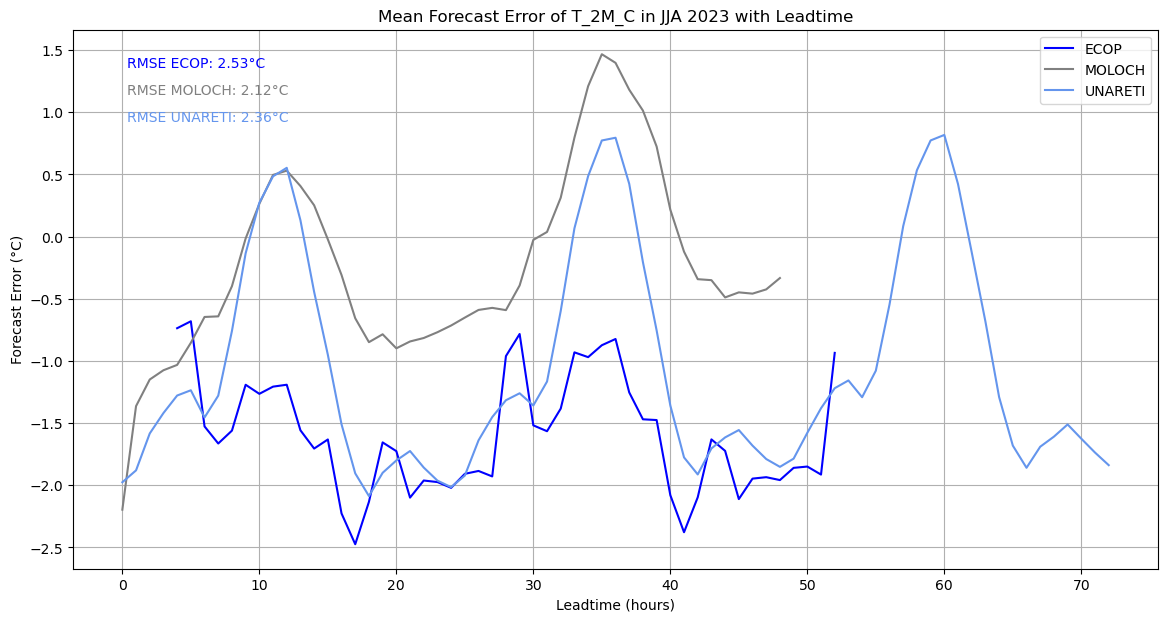

In [72]:
plot_mean_forecast_error_with_leadtime(dataset_T_2M_C_summer_2023, var='T_2M_C', name='JJA 2023')
#plot_mean_forecast_error_with_leadtime(dataset_T_2M_C_summer_2022, var='T_2M_C', name='JJA 2022')

In [73]:
def plot_mean_forecast_error_with_leadtime_corrected(dataset, var, name):
    """
    Plot the mean forecast error of UNARETI, Moloch, and ECOP for the temperature with leadtime as the x-axis.
    The error is computed as forecast - observations before averaging over the forecasts (correction station by station)
    The systematic error is removed per gridpoint before plotting the error.
    """

    unit={'T_2M_C':'°C', 'RH':'%'}

    stations_milano = ['Milano v.Brera', 'Milano San Siro',
                      'MILANO Bicocca', 'MILANO Bocconi', 'MILANO Bovisa',
                      'MILANO Città Studi', 'MILANO Sud']
    
    other_stations = list(set(dataset['OLD_STATION_NAME'].unique()) - set(stations_milano))

    # Adjust UNARETI TRADE_DATE to 00Z the day after
    dataset['TRADE_DATE'] = np.where(dataset['TRADE_DATE'].dt.hour == 12, dataset['TRADE_DATE'] + pd.Timedelta(hours=12), dataset['TRADE_DATE'])

    # Calculate leadtime in hours
    dataset['LEADTIME_HOURS'] = (dataset['VALID_DATE'] - dataset['TRADE_DATE']).dt.total_seconds() / 3600
    
    # Calculate forecast errors
    if var!='RH':
        dataset[f'ECOP_ERROR'] = dataset[f'ECOP_{var}'] - dataset[f'OBSERVATION_{var}']
    dataset[f'MOLOCH_ERROR'] = dataset[f'MOLOCH_{var}'] - dataset[f'OBSERVATION_{var}']
    dataset[f'UNARETI_ERROR'] = dataset[f'UNARETI_{var}'] - dataset[f'OBSERVATION_{var}']
    
    # Calculate systematic error (mean error) per gridpoint for each model
    if var!='RH':
        systematic_error_ecop = dataset.groupby('ID_CONSUNTIVO')[f'ECOP_ERROR'].transform('mean')
    systematic_error_moloch = dataset.groupby('ID_CONSUNTIVO')[f'MOLOCH_ERROR'].transform('mean')
    systematic_error_unareti = dataset.groupby('ID_CONSUNTIVO')[f'UNARETI_ERROR'].transform('mean')
    
    # Remove systematic error from forecast values
    if var!='RH':
        dataset[f'ECOP_{var}_CORRECTED'] = dataset[f'ECOP_{var}'] - systematic_error_ecop
    dataset[f'MOLOCH_{var}_CORRECTED'] = dataset[f'MOLOCH_{var}'] - systematic_error_moloch
    dataset[f'UNARETI_{var}_CORRECTED'] = dataset[f'UNARETI_{var}'] - systematic_error_unareti
    
    # Calculate corrected forecast errors
    if var!='RH':
        dataset[f'ECOP_ERROR_CORRECTED'] = dataset[f'ECOP_{var}_CORRECTED'] - dataset[f'OBSERVATION_{var}']
    dataset[f'MOLOCH_ERROR_CORRECTED'] = dataset[f'MOLOCH_{var}_CORRECTED'] - dataset[f'OBSERVATION_{var}']
    dataset[f'UNARETI_ERROR_CORRECTED'] = dataset[f'UNARETI_{var}_CORRECTED'] - dataset[f'OBSERVATION_{var}']
    
    # Group by leadtime and compute the mean error for each model
    if var!='RH':
        numeric_columns = [f'ECOP_ERROR_CORRECTED', f'MOLOCH_ERROR_CORRECTED', f'UNARETI_ERROR_CORRECTED']
    else:
        numeric_columns = [f'MOLOCH_ERROR_CORRECTED', f'UNARETI_ERROR_CORRECTED']

        # Compute RMSE per station
    rmse_per_station = dataset.groupby('OLD_STATION_NAME').apply(
        lambda x: pd.Series({
                #'RMSE_ECOP': np.sqrt(mean_squared_error(x.dropna(subset=[f'OBSERVATION_{var}', f'ECOP_{var}_CORRECTED'])[f'OBSERVATION_{var}'], x.dropna(subset=[f'OBSERVATION_{var}', f'ECOP_{var}_CORRECTED'])[f'ECOP_{var}_CORRECTED'])) if len(x.dropna(subset=[f'OBSERVATION_{var}', f'ECOP_{var}_CORRECTED'])) > 0 else None,
                'RMSE_MOLOCH': np.sqrt(mean_squared_error(x.dropna(subset=[f'OBSERVATION_{var}', f'MOLOCH_{var}_CORRECTED'])[f'OBSERVATION_{var}'], x.dropna(subset=[f'OBSERVATION_{var}', f'MOLOCH_{var}_CORRECTED'])[f'MOLOCH_{var}_CORRECTED'])) if len(x.dropna(subset=[f'OBSERVATION_{var}', f'MOLOCH_{var}_CORRECTED'])) > 0 else None,
                'RMSE_UNARETI': np.sqrt(mean_squared_error(x.dropna(subset=[f'OBSERVATION_{var}', f'UNARETI_{var}_CORRECTED'])[f'OBSERVATION_{var}'], x.dropna(subset=[f'OBSERVATION_{var}', f'UNARETI_{var}_CORRECTED'])[f'UNARETI_{var}_CORRECTED'])) if len(x.dropna(subset=[f'OBSERVATION_{var}', f'UNARETI_{var}_CORRECTED'])) > 0 else None
        })
    ).reset_index()

    print(rmse_per_station)

     # print the rmse per group of staitons (milano and other), column OLD_STATION_NAME
    for model in [ 'MOLOCH', 'UNARETI']:
        print(model)
        print('milano', rmse_per_station[rmse_per_station['OLD_STATION_NAME'].isin(stations_milano)][f'RMSE_{model}'].mean())
        print('fuori', rmse_per_station[rmse_per_station['OLD_STATION_NAME'].isin(other_stations)][f'RMSE_{model}'].mean())

    mean_errors = dataset.groupby('LEADTIME_HOURS')[numeric_columns].mean()
    
    # Plot the timeseries
    plt.figure(figsize=(14, 7))

    colors = {f'ECOP_ERROR_CORRECTED': 'blue', f'MOLOCH_ERROR_CORRECTED': 'grey', f'UNARETI_ERROR_CORRECTED': 'cornflowerblue'}
    if var!='RH':
        plt.plot(mean_errors.index, mean_errors[f'ECOP_ERROR_CORRECTED'], label='ECOP', color=colors[f'ECOP_ERROR_CORRECTED'])
    plt.plot(mean_errors.index, mean_errors[f'MOLOCH_ERROR_CORRECTED'], label='MOLOCH', color=colors[f'MOLOCH_ERROR_CORRECTED'])
    plt.plot(mean_errors.index, mean_errors[f'UNARETI_ERROR_CORRECTED'], label='UNARETI', color=colors[f'UNARETI_ERROR_CORRECTED'])

    # Compute RMSE for each model
    if var!='RH':
        common_index = dataset.dropna(subset=[f'OBSERVATION_{var}', f'ECOP_{var}_CORRECTED']).index
        rmse_ecop = np.sqrt(mean_squared_error(dataset.loc[common_index, f'OBSERVATION_{var}'], dataset.loc[common_index, f'ECOP_{var}_CORRECTED']))
    
    common_index = dataset.dropna(subset=[f'OBSERVATION_{var}', f'MOLOCH_{var}_CORRECTED']).index
    rmse_moloch = np.sqrt(mean_squared_error(dataset.loc[common_index, f'OBSERVATION_{var}'], dataset.loc[common_index, f'MOLOCH_{var}_CORRECTED']))
    
    common_index = dataset.dropna(subset=[f'OBSERVATION_{var}', f'UNARETI_{var}_CORRECTED']).index
    rmse_unareti = np.sqrt(mean_squared_error(dataset.loc[common_index, f'OBSERVATION_{var}'], dataset.loc[common_index, f'UNARETI_{var}_CORRECTED']))
    
    # Add RMSE to the plot
    if var!='RH':
        plt.text(0.05, 0.95, f'RMSE ECOP: {rmse_ecop:.2f}{unit[var]}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', color=colors[f'ECOP_ERROR_CORRECTED'])
    plt.text(0.05, 0.90, f'RMSE MOLOCH: {rmse_moloch:.2f}{unit[var]}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', color=colors['MOLOCH_ERROR_CORRECTED'])
    plt.text(0.05, 0.85, f'RMSE UNARETI: {rmse_unareti:.2f}{unit[var]}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', color=colors['UNARETI_ERROR_CORRECTED'])
    
    plt.xlabel('Leadtime (hours)')
    plt.ylabel(f'Forecast Error ({unit[var]})')
    plt.title(f'Mean Forecast Error of {var} in {name} with Leadtime (Corrected)')
    plt.legend()
    plt.grid(True)

    plt.show()



           OLD_STATION_NAME  RMSE_MOLOCH  RMSE_UNARETI
0        Bergamo v.Stezzano     2.029012           NaN
1         Brescia v.Ziziola     1.778371           NaN
2     Casalbuttano ed Uniti     1.915815           NaN
3            MILANO Bicocca     1.843575      1.818197
4            MILANO Bocconi     1.935070      1.844763
5             MILANO Bovisa     2.232488           NaN
6        MILANO Città Studi     2.045731      2.164328
7       MILANO Forze Armate     2.515111           NaN
8           MILANO San Siro     2.457836           NaN
9                MILANO Sud     2.438385      2.318633
10          Milano Lambrate     1.744656      2.072559
11           Milano v.Brera     1.848242           NaN
12  Osio Sotto v.per Levate     1.602493           NaN
13                   lmb249     1.946621           NaN
14                   lmb319     1.671433           NaN
15                   lmb499     1.812614           NaN
MOLOCH
milano 2.057248517856159
fuori 1.9473962416961954
UNARETI


C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_21992\2714278954.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_per_station = dataset.groupby('OLD_STATION_NAME').apply(


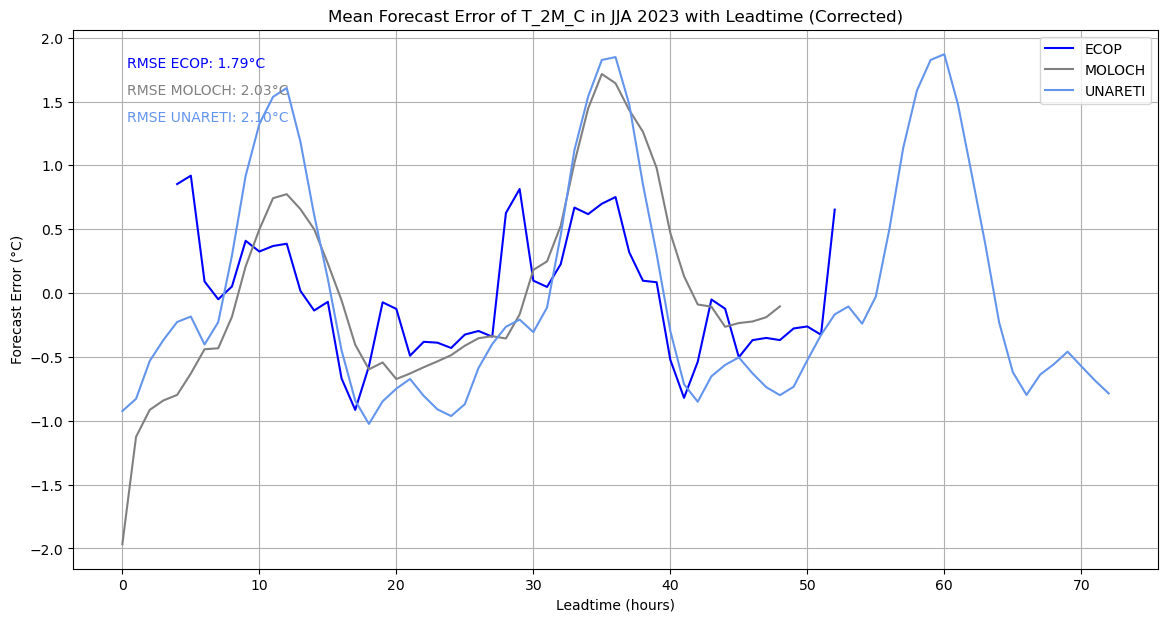

In [74]:
plot_mean_forecast_error_with_leadtime_corrected(dataset_T_2M_C_summer_2023, var='T_2M_C', name='JJA 2023')

In [75]:
def plot_mean_forecast_error_with_leadtime_corrected_by_hour(dataset, var, name):
    """
    plot the timeseries of the forecast error for all models, after correction with systematic bias.
    The systemaatic bias is computed per station and per hour (overfitting? by slice of day?).
    """

    unit={'T_2M_C':'°C', 'RH':'%'}

    # Adjust UNARETI TRADE_DATE to 00Z the day after
    dataset['TRADE_DATE'] = np.where(dataset['TRADE_DATE'].dt.hour == 12, dataset['TRADE_DATE'] + pd.Timedelta(hours=12), dataset['TRADE_DATE'])

    # Calculate leadtime in hours
    dataset['LEADTIME_HOURS'] = (dataset['VALID_DATE'] - dataset['TRADE_DATE']).dt.total_seconds() / 3600
    
    # Calculate forecast errors
    if var!='RH':
        dataset[f'ECOP_ERROR'] = dataset[f'ECOP_{var}'] - dataset[f'OBSERVATION_{var}']
    dataset[f'MOLOCH_ERROR'] = dataset[f'MOLOCH_{var}'] - dataset[f'OBSERVATION_{var}']
    dataset[f'UNARETI_ERROR'] = dataset[f'UNARETI_{var}'] - dataset[f'OBSERVATION_{var}']
    
    # Calculate systematic error (mean error) per gridpoint for each model
    if var!='RH':
        systematic_error_ecop = dataset.groupby(['ID_CONSUNTIVO', 'LEADTIME_HOURS'])[f'ECOP_ERROR'].transform('mean')
    systematic_error_moloch = dataset.groupby(['ID_CONSUNTIVO', 'LEADTIME_HOURS'])[f'MOLOCH_ERROR'].transform('mean')
    systematic_error_unareti = dataset.groupby(['ID_CONSUNTIVO', 'LEADTIME_HOURS'])[f'UNARETI_ERROR'].transform('mean')
    
    # Remove systematic error from forecast values
    if var!='RH':
        dataset[f'ECOP_{var}_CORRECTED'] = dataset[f'ECOP_{var}'] - systematic_error_ecop
    dataset[f'MOLOCH_{var}_CORRECTED'] = dataset[f'MOLOCH_{var}'] - systematic_error_moloch
    dataset[f'UNARETI_{var}_CORRECTED'] = dataset[f'UNARETI_{var}'] - systematic_error_unareti
    
    # Calculate corrected forecast errors
    if var!='RH':
        dataset[f'ECOP_ERROR_CORRECTED'] = dataset[f'ECOP_{var}_CORRECTED'] - dataset[f'OBSERVATION_{var}']
    dataset[f'MOLOCH_ERROR_CORRECTED'] = dataset[f'MOLOCH_{var}_CORRECTED'] - dataset[f'OBSERVATION_{var}']
    dataset[f'UNARETI_ERROR_CORRECTED'] = dataset[f'UNARETI_{var}_CORRECTED'] - dataset[f'OBSERVATION_{var}']
    
    # Group by leadtime and compute the mean error for each model
    if var!='RH':
        numeric_columns = [f'ECOP_ERROR_CORRECTED', f'MOLOCH_ERROR_CORRECTED', f'UNARETI_ERROR_CORRECTED']
    else:
        numeric_columns = [f'MOLOCH_ERROR_CORRECTED', f'UNARETI_ERROR_CORRECTED']

    mean_errors = dataset.groupby('LEADTIME_HOURS')[numeric_columns].mean()
    
    # Plot the timeseries
    plt.figure(figsize=(14, 7))

    colors = {f'ECOP_ERROR_CORRECTED': 'blue', f'MOLOCH_ERROR_CORRECTED': 'grey', f'UNARETI_ERROR_CORRECTED': 'cornflowerblue'}

    if var!='RH':
        plt.plot(mean_errors.index, mean_errors[f'ECOP_ERROR_CORRECTED'], label='ECOP', color=colors[f'ECOP_ERROR_CORRECTED'])
    plt.plot(mean_errors.index, mean_errors[f'MOLOCH_ERROR_CORRECTED'], label='MOLOCH', color=colors[f'MOLOCH_ERROR_CORRECTED'])
    plt.plot(mean_errors.index, mean_errors[f'UNARETI_ERROR_CORRECTED'], label='UNARETI', color=colors[f'UNARETI_ERROR_CORRECTED'])

    # Compute RMSE for each model
    if var!='RH':
        common_index = dataset.dropna(subset=[f'OBSERVATION_{var}', f'ECOP_{var}_CORRECTED']).index
        rmse_ecop = np.sqrt(mean_squared_error(dataset.loc[common_index, f'OBSERVATION_{var}'], dataset.loc[common_index, f'ECOP_{var}_CORRECTED']))
    
    common_index = dataset.dropna(subset=[f'OBSERVATION_{var}', f'MOLOCH_{var}_CORRECTED']).index
    rmse_moloch = np.sqrt(mean_squared_error(dataset.loc[common_index, f'OBSERVATION_{var}'], dataset.loc[common_index, f'MOLOCH_{var}_CORRECTED']))
    
    common_index = dataset.dropna(subset=[f'OBSERVATION_{var}', f'UNARETI_{var}_CORRECTED']).index
    rmse_unareti = np.sqrt(mean_squared_error(dataset.loc[common_index, f'OBSERVATION_{var}'], dataset.loc[common_index, f'UNARETI_{var}_CORRECTED']))
    
    # Add RMSE to the plot
    if var!='RH':
        plt.text(0.05, 0.95, f'RMSE ECOP: {rmse_ecop:.2f}{unit[var]}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', color=colors[f'ECOP_ERROR_CORRECTED'])
    plt.text(0.05, 0.90, f'RMSE MOLOCH: {rmse_moloch:.2f}{unit[var]}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', color=colors['MOLOCH_ERROR_CORRECTED'])
    plt.text(0.05, 0.85, f'RMSE UNARETI: {rmse_unareti:.2f}{unit[var]}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', color=colors['UNARETI_ERROR_CORRECTED'])
    

    plt.xlabel('Leadtime (hours)')
    plt.ylabel(f'Forecast Error ({unit[var]})')
    plt.title(f'Mean Forecast Error of {var} in {name} with Leadtime (Corrected)')
    plt.legend()
    plt.grid(True)

    plt.ylim(-1,1)

    plt.show()

    

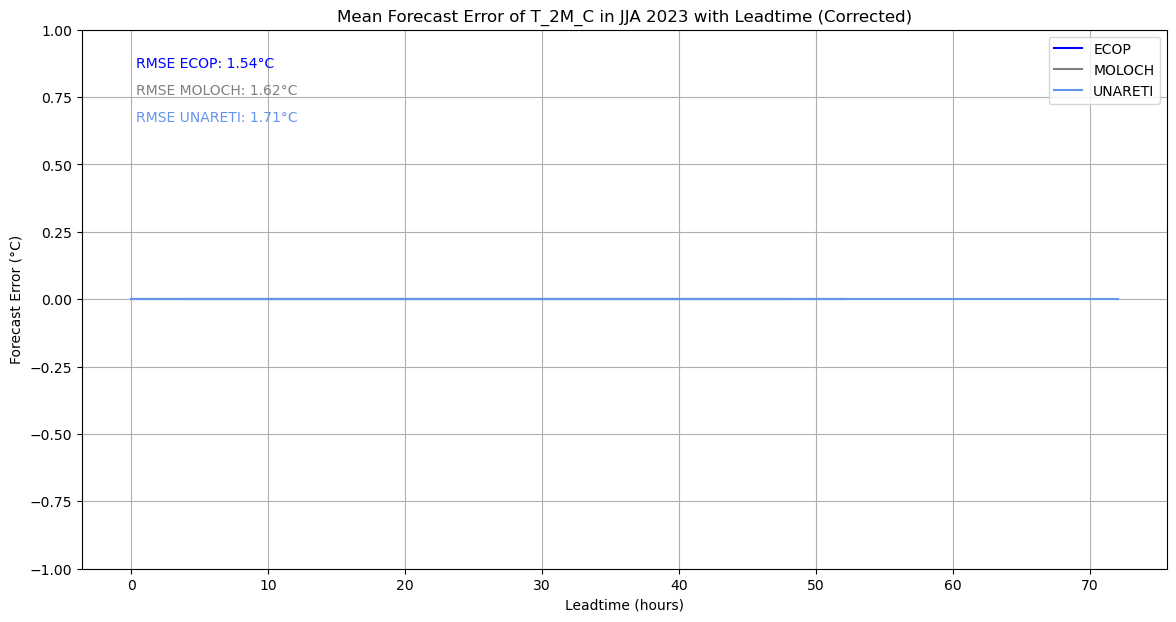

In [76]:
plot_mean_forecast_error_with_leadtime_corrected_by_hour(dataset_T_2M_C_summer_2023, var='T_2M_C', name='JJA 2023')

When correcting per station and per hour, the mean forecast error over the station is minimal. However, when looking at individual stations and leadtimes (as the RMSE does), the error is still in the same order of magnitude as before. One can also fear an 'over-fitting' when using this type of correction. 

### Relative Humidity

           OLD_STATION_NAME  RMSE_MOLOCH  RMSE_UNARETI
0        Bergamo v.Stezzano    18.177980           NaN
1         Brescia v.Ziziola    13.788645           NaN
2            MILANO Bicocca    11.521107     14.826886
3            MILANO Bocconi    11.106529     14.674238
4             MILANO Bovisa    13.098575           NaN
5        MILANO Città Studi    11.254652     15.299888
6       MILANO Forze Armate    13.157214           NaN
7           MILANO San Siro    13.078452           NaN
8                MILANO Sud    12.601100     14.287533
9           Milano Lambrate    10.936378     15.359831
10           Milano v.Brera    11.099876           NaN
11  Osio Sotto v.per Levate    14.554438           NaN
12                   lmb249     9.792376           NaN
13                   lmb319    10.602004           NaN
14                   lmb499    11.807999           NaN
MOLOCH
milano 11.780306549545726
fuori 12.877276286548387
UNARETI
milano 14.772136304986555
fuori 15.359831028373408


C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_21992\2988012367.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_per_station = dataset.groupby('OLD_STATION_NAME').apply(


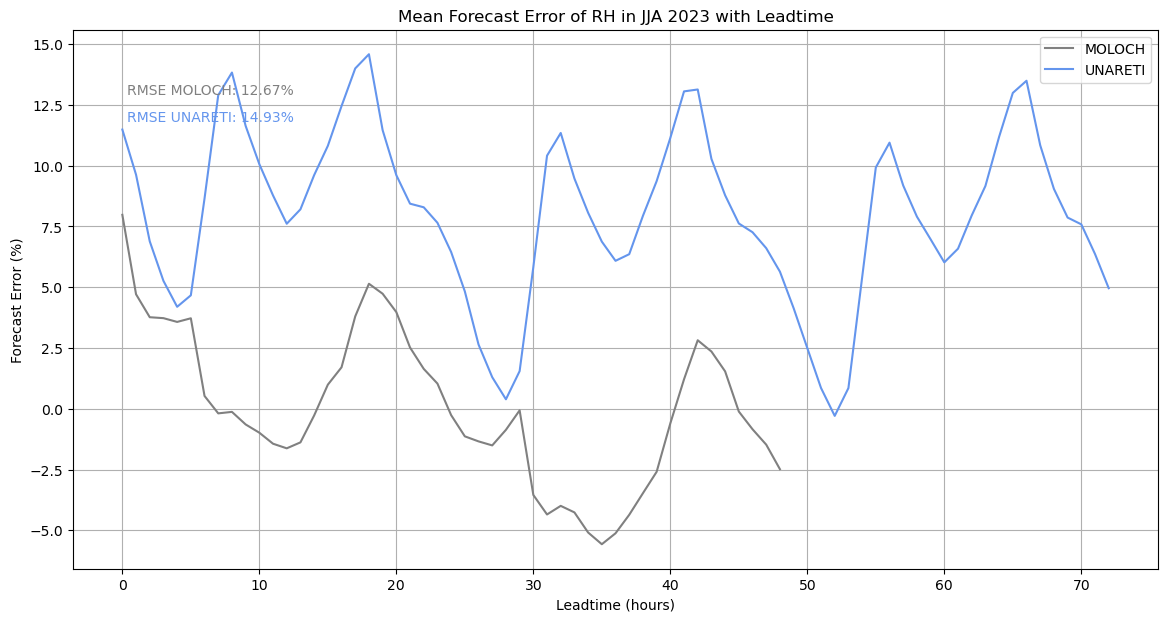

In [77]:
plot_mean_forecast_error_with_leadtime(dataset_RH_summer_2023, var='RH', name='JJA 2023')

           OLD_STATION_NAME  RMSE_MOLOCH  RMSE_UNARETI
0        Bergamo v.Stezzano    15.065259           NaN
1         Brescia v.Ziziola    12.729692           NaN
2            MILANO Bicocca    11.053250     11.791360
3            MILANO Bocconi    11.082417      9.834085
4             MILANO Bovisa    12.129122           NaN
5        MILANO Città Studi    11.190448     12.739365
6       MILANO Forze Armate    12.851155           NaN
7           MILANO San Siro    12.884965           NaN
8                MILANO Sud    12.583520     12.228749
9           Milano Lambrate    10.933610     14.042884
10           Milano v.Brera    11.048426           NaN
11  Osio Sotto v.per Levate    11.698741           NaN
12                   lmb249     9.627595           NaN
13                   lmb319     9.987859           NaN
14                   lmb499    11.490282           NaN
MOLOCH
milano 11.514530694955662
fuori 11.918795147393004
UNARETI
milano 11.648389617868242
fuori 14.04288420904184


C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_21992\2714278954.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_per_station = dataset.groupby('OLD_STATION_NAME').apply(


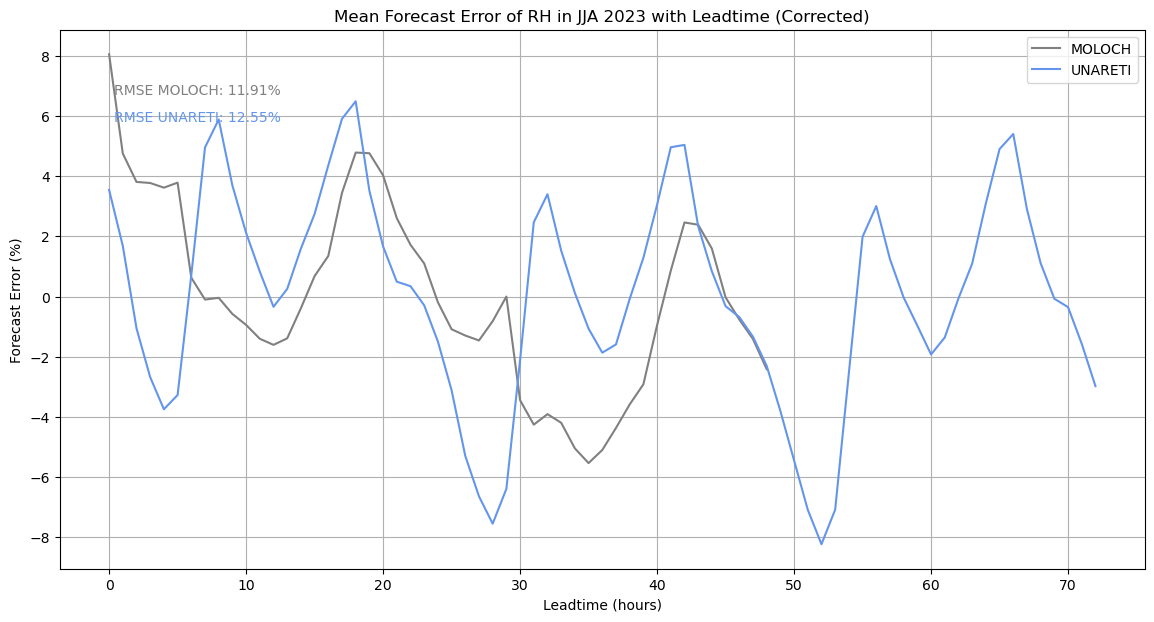

In [78]:
plot_mean_forecast_error_with_leadtime_corrected(dataset_RH_summer_2023, var='RH', name='JJA 2023')

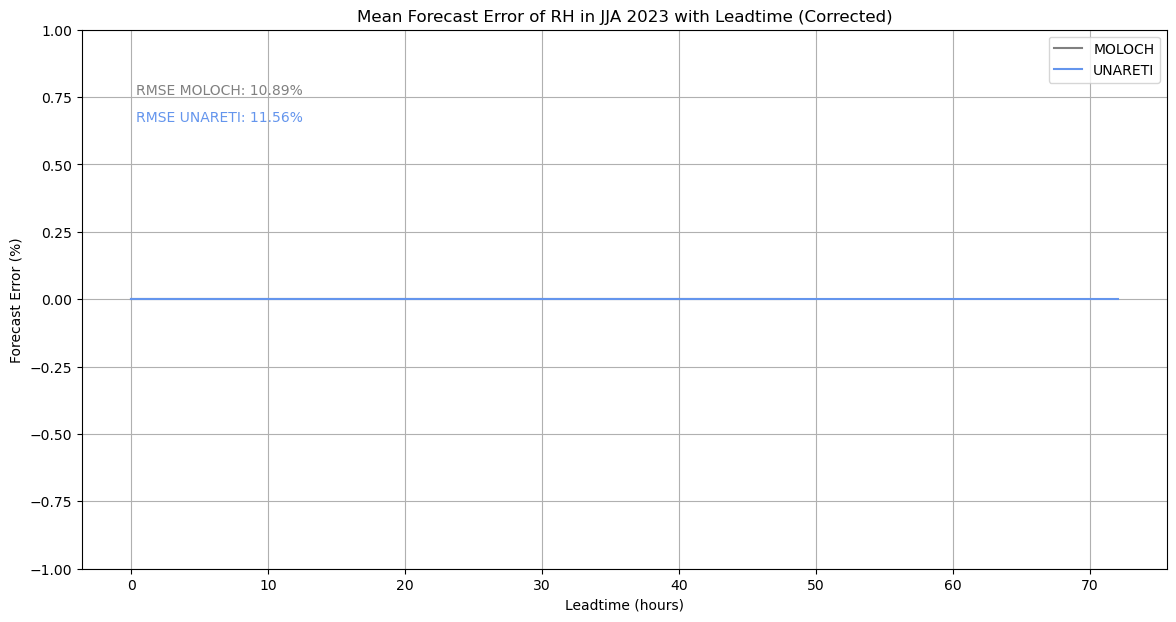

In [79]:
plot_mean_forecast_error_with_leadtime_corrected_by_hour(dataset_RH_summer_2023, var='RH', name='JJA 2023')

## Taylor Diagram

In [80]:
def plot_taylor_diagram(dataset, var, name):
    """
    Plot a Taylor diagram for the given dataset and variable.
    
    Parameters:
    - dataset: DataFrame, the dataset containing observed and forecasted values
    - var: string, the variable to plot (e.g., 'T_2M_C', 'RH')
    - name: string, the name used as a title complement for the plot
    """
    # Prepare the data
    if var == 'T_2M_C':
        models = [f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']
    elif var == 'RH':
        models = [f'MOLOCH_{var}', f'UNARETI_{var}']
    else:
        print(f'var {var} not understood')
        return

    observed = dataset[f'OBSERVATION_{var}']
    forecasts = [dataset[model].dropna() for model in models]
    model_names = [model.split('_')[0] for model in models]

    # Align indices to ensure the same length
    aligned_data = [observed.dropna().align(forecast.dropna(), join='inner') for forecast in forecasts]
    observed_aligned = [data[0].values for data in aligned_data]
    forecasts_aligned = [data[1].values for data in aligned_data]

    # Compute reference standard deviation
    refstd = np.std(observed_aligned[0], ddof=1)
    
    # Compute standard deviations and correlation coefficients for each model
    samples = np.array([[np.std(forecast, ddof=1), pearsonr(obs, forecast)[0]]
                        for obs, forecast in zip(observed_aligned, forecasts_aligned)])
    
    fig = plt.figure(figsize=(10, 7))
    
    # Create Taylor diagram
    dia = TaylorDiagram(refstd, fig=fig, rect=111, label="Observed")
    
    # Add models to Taylor diagram
    for i, (stddev, corrcoef) in enumerate(samples):
        dia.add_sample(stddev, corrcoef,
                       marker='x', ms=10, ls='',
                       mfc=colors[model_names[i]], mec=colors[model_names[i]],
                       mew=2,  # Increase the thickness of the cross markers
                       label=model_names[i])
        print(colors[model_names[i]])
        print(model_names[i])
        print(stddev, corrcoef)
    
    # Add grid
    dia.add_grid()
    
    # Add RMS contours, and label them
    contours = dia.add_contours(colors='0.5')
    plt.clabel(contours, inline=1, fontsize=10, fmt='%.2f')
    
    # Add a figure legend
    fig.legend(dia.samplePoints,
               [p.get_label() for p in dia.samplePoints],
               numpoints=1, prop=dict(size='small'), loc='upper right')
    
    plt.title(f"Taylor Diagram for {var} in {name}")
    plt.show()



### 2m temperature

orange
ECOP
4.734125115463387 0.9143434533638275
olivedrab
MOLOCH
4.9663878778079456 0.9061627085965553
coral
UNARETI
4.709197488227635 0.8953761319627929


C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_21992\3966289971.py:56: MatplotlibDeprecationWarning: Passing `apply_theta_transforms=True` (the default) is deprecated since Matplotlib 3.9. Support for this will be removed in Matplotlib in 3.11. To prevent this warning, set `apply_theta_transforms=False`, and make sure to shift theta values before being passed to this transform.
  plt.clabel(contours, inline=1, fontsize=10, fmt='%.2f')


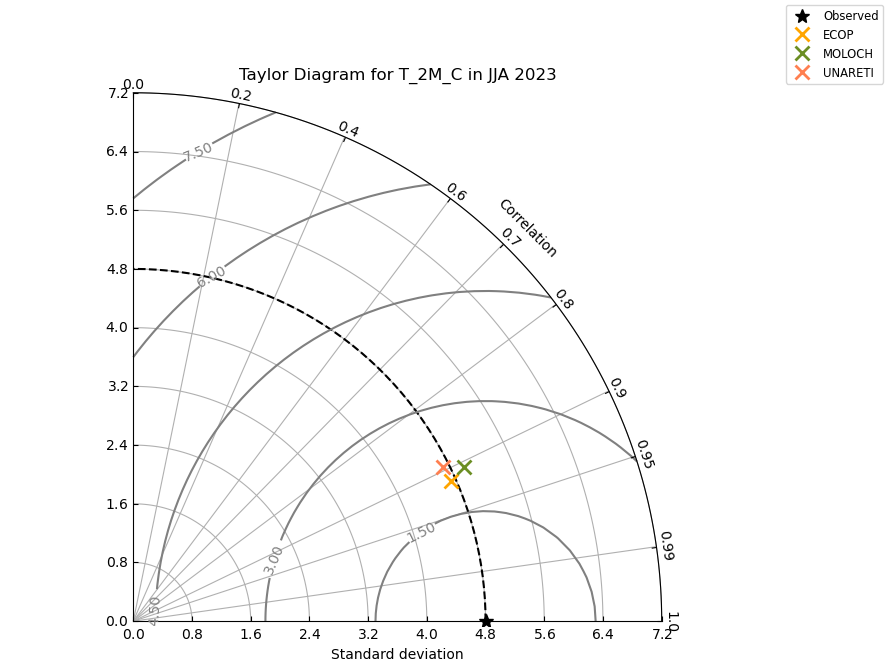

In [81]:
plot_taylor_diagram(dataset_T_2M_C_summer_2023, var='T_2M_C', name='JJA 2023')

In [82]:
def plot_taylor_diagram_max_temp(dataset, var, name):
    """
    Plot a Taylor diagram for the maximum daily temperature for the given dataset and variable.
    
    Parameters:
    - dataset: DataFrame, the dataset containing observed and forecasted values
    - var: string, the variable to plot (e.g., 'T_2M_C')
    - name: string, the name used as a title complement for the plot
    """
    # Prepare the data
    models = [f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']

    # Group by date and station, and get the maximum daily temperature
    max_daily_obs = dataset.groupby([dataset['VALID_DATE'].dt.date, 'OLD_STATION_NAME'])[f'OBSERVATION_{var}'].max().reset_index()
    max_daily_forecasts = {model: dataset.groupby([dataset['VALID_DATE'].dt.date, 'OLD_STATION_NAME'])[model].max().reset_index() for model in models}
    
    # Merge the observations with each forecast model
    merged_data = max_daily_obs
    for model in models:
        merged_data = pd.merge(merged_data, max_daily_forecasts[model], on=['VALID_DATE', 'OLD_STATION_NAME'], suffixes=('', f'_{model}'))

    observed = merged_data[f'OBSERVATION_{var}']
    forecasts = [merged_data[model] for model in models]
    model_names = [model.split('_')[0] for model in models]

    # Align indices to ensure the same length
    aligned_data = [observed.dropna().align(forecast.dropna(), join='inner') for forecast in forecasts]
    observed_aligned = [data[0].values for data in aligned_data]
    forecasts_aligned = [data[1].values for data in aligned_data]

    # Compute reference standard deviation
    refstd = np.std(observed_aligned[0], ddof=1)
    
    # Compute standard deviations and correlation coefficients for each model
    samples = np.array([[np.std(forecast, ddof=1), pearsonr(obs, forecast)[0]]
                        for obs, forecast in zip(observed_aligned, forecasts_aligned)])
    
    fig = plt.figure(figsize=(10, 7))
    
    # Create Taylor diagram
    dia = TaylorDiagram(refstd, fig=fig, rect=111, label="Observed")
    
    # Add models to Taylor diagram
    for i, (stddev, corrcoef) in enumerate(samples):
        dia.add_sample(stddev, corrcoef,
                       marker='x', ms=10, ls='',
                       mfc=colors[model_names[i]], mec=colors[model_names[i]],
                       mew=2,  # Increase the thickness of the cross markers
                       label=model_names[i])
    
    # Add grid
    dia.add_grid()
    
    # Add RMS contours, and label them
    contours = dia.add_contours(colors='0.5')
    plt.clabel(contours, inline=1, fontsize=10, fmt='%.2f')
    
    # Add a figure legend
    fig.legend(dia.samplePoints,
               [p.get_label() for p in dia.samplePoints],
               numpoints=1, prop=dict(size='small'), loc='upper right')
    
    plt.title(f"Taylor Diagram for Maximum Daily {var} in {name}")
    plt.show()



C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_21992\2120011308.py:56: MatplotlibDeprecationWarning: Passing `apply_theta_transforms=True` (the default) is deprecated since Matplotlib 3.9. Support for this will be removed in Matplotlib in 3.11. To prevent this warning, set `apply_theta_transforms=False`, and make sure to shift theta values before being passed to this transform.
  plt.clabel(contours, inline=1, fontsize=10, fmt='%.2f')


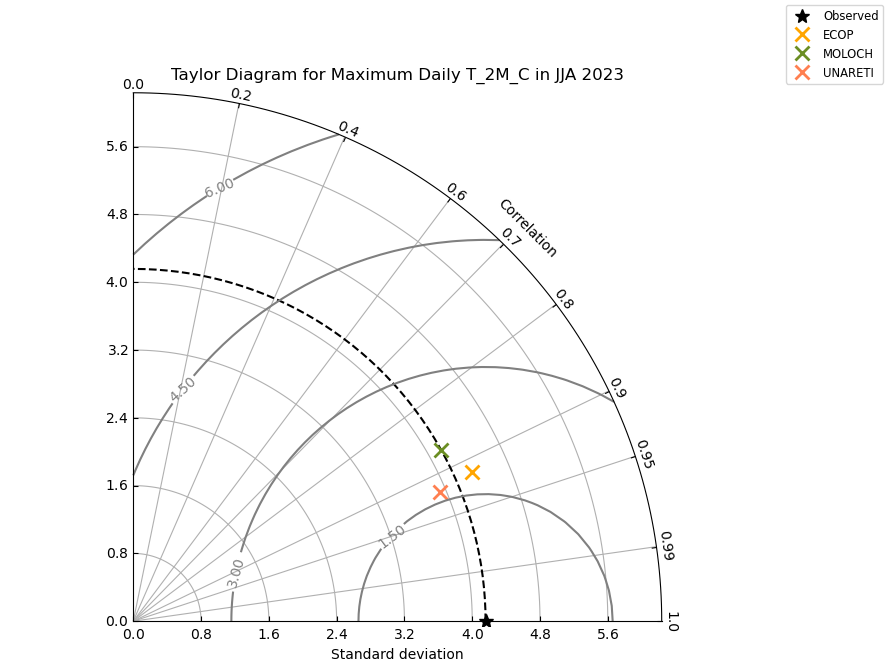

In [83]:
plot_taylor_diagram_max_temp(dataset_T_2M_C_summer_2023, var='T_2M_C', name='JJA 2023')

### Relative Humidity

olivedrab
MOLOCH
18.63574568588936 0.7657023148302461
coral
UNARETI
16.32602183144172 0.7235530406025893


C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_21992\3966289971.py:56: MatplotlibDeprecationWarning: Passing `apply_theta_transforms=True` (the default) is deprecated since Matplotlib 3.9. Support for this will be removed in Matplotlib in 3.11. To prevent this warning, set `apply_theta_transforms=False`, and make sure to shift theta values before being passed to this transform.
  plt.clabel(contours, inline=1, fontsize=10, fmt='%.2f')


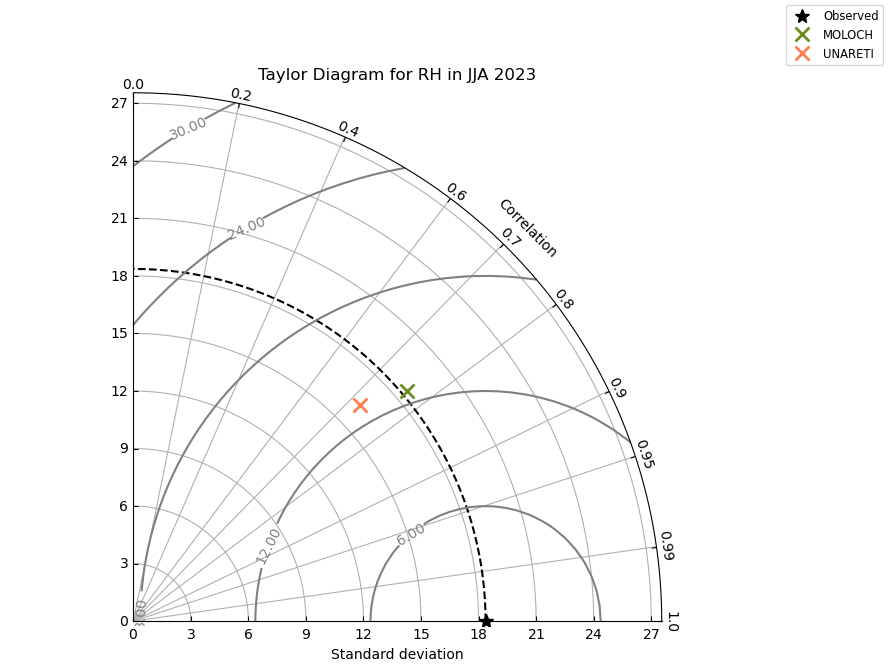

In [84]:
plot_taylor_diagram(dataset_RH_summer_2023, var='RH', name='JJA 2023')

## Cumulative distribution function

In [85]:
def plot_cumulative_probability_functions(dataset, var, name):
    """
    Plot the cumulative probability functions of the observations and the model forecasts station by station.
    var: the name of the variable in the dataset (e.g., 'T_2M_C', 'RH')
    name: the string used as name complement for the plot
    """

    stations_milano = ['Milano v.Brera', 'Milano San Siro',
                        'MILANO Bicocca', 'MILANO Bocconi', 'MILANO Bovisa',
                        'MILANO Città Studi', 'MILANO Sud']
    
    other_stations = list(set(dataset['OLD_STATION_NAME'].unique()) - set(stations_milano))

    # Prepare the data
    if var == 'T_2M_C':
        models = [f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']
    elif var == 'RH':
        models = [f'MOLOCH_{var}', f'UNARETI_{var}']
    else:
        print(f'var {var} not understood')
        return

    stations = dataset['OLD_STATION_NAME'].unique()
    num_stations = len(stations)
    fig, axes = plt.subplots(4, 4, figsize=(16, 10), sharex=True, sharey=True)

    if num_stations == 1:
        axes = [axes]

    for i, (ax, station) in enumerate(zip(axes.flatten(), stations)):
        station_data = dataset[dataset['OLD_STATION_NAME'] == station]
        
        # Plot cumulative distribution function for observations
        obs_data = station_data[f'OBSERVATION_{var}'].dropna()
        obs_sorted = np.sort(obs_data)
        obs_cdf = np.arange(1, len(obs_sorted) + 1) / len(obs_sorted)
        ax.plot(obs_sorted, obs_cdf, label='OBSERVATION', color=colors['OBSERVATION'])

        # Plot cumulative distribution function for each model
        for model in models:
            model_data = station_data[model].dropna()
            model_sorted = np.sort(model_data)
            model_cdf = np.arange(1, len(model_sorted) + 1) / len(model_sorted)
            ax.plot(model_sorted, model_cdf, label=model.split('_')[0], color=colors[model.split('_')[0]])

        ax.set_ylabel('Cumulative Probability')
        ax.set_title(f'{station}')
        ax.grid(True)
    
    axes[0,0].legend()
    plt.suptitle(f'Cumulative Probability Functions of {var} for Each Station in {name}', fontsize=16)

    plt.tight_layout()
    plt.show()
    
    # Compute CRPS for each model and station
    crps_results = {}
    for model in models:
        crps_results[model] = []
        for station in stations:
            station_data = dataset[dataset['OLD_STATION_NAME'] == station]
            # Find the union of the empty rows in the columns and drop them in both
            obs_data = station_data[f'OBSERVATION_{var}']
            model_data = station_data[model]
            combined_data = pd.concat([obs_data, model_data], axis=1).dropna()
            obs_data = combined_data[f'OBSERVATION_{var}']
            model_data = combined_data[model]
            if not obs_data.empty and not model_data.empty:
                crps = ps.crps_ensemble(obs_data.values, model_data.values)
                crps_results[model].append(crps.mean())
            else:
                crps_results[model].append(np.nan)

    # Print CRPS results per model and group of stations
    print('CRPS results:')
    for model in models:
        for station_group, stations in [('Milano', stations_milano), ('Other', other_stations)]:
            print(model, station_group, np.nanmean([crps_results[model][stations.index(station)] for station in stations if station in stations]))

In [86]:
def compute_efi(dataset, var, name):
    """
    Compute the Extreme Forecast Index (EFI) for the given dataset and variable.
    The EFI is the CRPS, but only for the higher 5% of the forecasts.
    var: the name of the variable in the dataset (e.g., 'T_2M_C', 'RH')
    name: the string used as name complement for the plot
    """

    stations_milano = ['Milano v.Brera', 'Milano San Siro',
                        'MILANO Bicocca', 'MILANO Bocconi', 'MILANO Bovisa',
                        'MILANO Città Studi', 'MILANO Sud']
    
    other_stations = list(set(dataset['OLD_STATION_NAME'].unique()) - set(stations_milano))

    # Prepare the data
    if var == 'T_2M_C':
        models = [f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']
    elif var == 'RH':
        models = [f'MOLOCH_{var}', f'UNARETI_{var}']
    else:
        print(f'var {var} not understood')
        return

    stations = dataset['OLD_STATION_NAME'].unique()

    # Compute EFI for each model and station
    efi_results = {}
    for model in models:
        efi_results[model] = []
        for station in stations:
            station_data = dataset[dataset['OLD_STATION_NAME'] == station]
            # Find the union of the empty rows in the columns and drop them in both
            obs_data = station_data[f'OBSERVATION_{var}']
            model_data = station_data[model]
            combined_data = pd.concat([obs_data, model_data], axis=1).dropna()
            obs_data = combined_data[f'OBSERVATION_{var}']
            model_data = combined_data[model]
            if not obs_data.empty and not model_data.empty:
                # Select the higher 5% of the observed data
                threshold = np.percentile(obs_data, 95)
                extreme_forecasts = model_data[obs_data >= threshold]
                extreme_observations = obs_data[obs_data >= threshold]
                if not extreme_forecasts.empty:
                    crps = ps.crps_ensemble(extreme_observations.values, extreme_forecasts.values)
                    efi_results[model].append(crps.mean())
                else:
                    efi_results[model].append(np.nan)
            else:
                efi_results[model].append(np.nan)

    # Print EFI results per model and group of stations
    print('EFI results:')
    for model in models:
        for station_group, stations in [('Milano', stations_milano), ('Other', other_stations)]:
            print(model, station_group, np.nanmean([efi_results[model][stations.index(station)] for station in stations if station in stations]))

    return efi_results

### 2m temperature

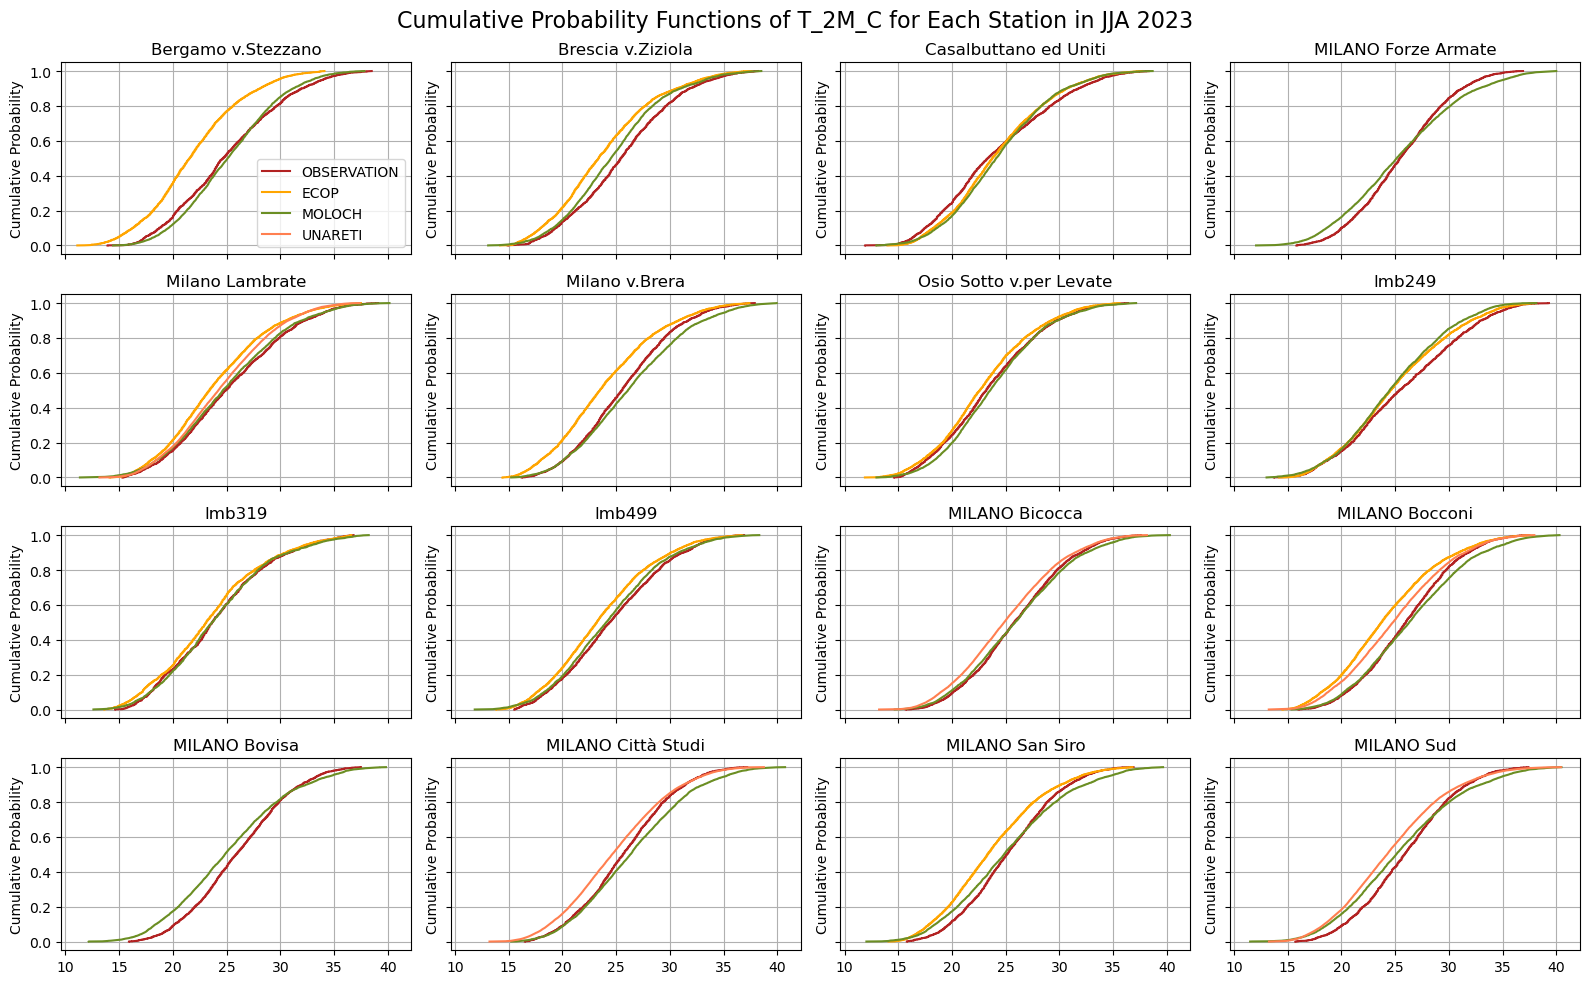

CRPS results:
ECOP_T_2M_C Milano 2.1732299348979613
ECOP_T_2M_C Other 1.9700963050917397
MOLOCH_T_2M_C Milano 1.5531015809234652
MOLOCH_T_2M_C Other 1.5561952061314313
UNARETI_T_2M_C Milano 1.833558424579189
UNARETI_T_2M_C Other 1.833558424579189


In [87]:
plot_cumulative_probability_functions(dataset_T_2M_C_summer_2023, var='T_2M_C', name='JJA 2023')

In [88]:
efi_results_T_2M_C = compute_efi(dataset_T_2M_C_summer_2023, var='T_2M_C', name='JJA 2023')
pprint.pprint(efi_results_T_2M_C)

EFI results:
ECOP_T_2M_C Milano 1.9717908415572145
ECOP_T_2M_C Other 1.7564321263280571
MOLOCH_T_2M_C Milano 1.3672415847394046
MOLOCH_T_2M_C Other 1.4513181256046974
UNARETI_T_2M_C Milano 2.214278867102418
UNARETI_T_2M_C Other 2.214278867102418
{'ECOP_T_2M_C': [4.582211538461559,
                 1.4115384615384827,
                 1.335096153846172,
                 nan,
                 1.9196261682243223,
                 1.480000000000011,
                 1.1022727272727406,
                 1.6888372093023383,
                 0.8825925925925915,
                 1.4057142857142966,
                 nan,
                 1.4293859649122802,
                 nan,
                 nan,
                 1.7553278688524594,
                 nan],
 'MOLOCH_T_2M_C': [1.486465817307689,
                   1.2808576923076918,
                   1.396728701923077,
                   2.1545856410256525,
                   0.8638618224299065,
                   1.5945680999999996,
       

### relative humidity

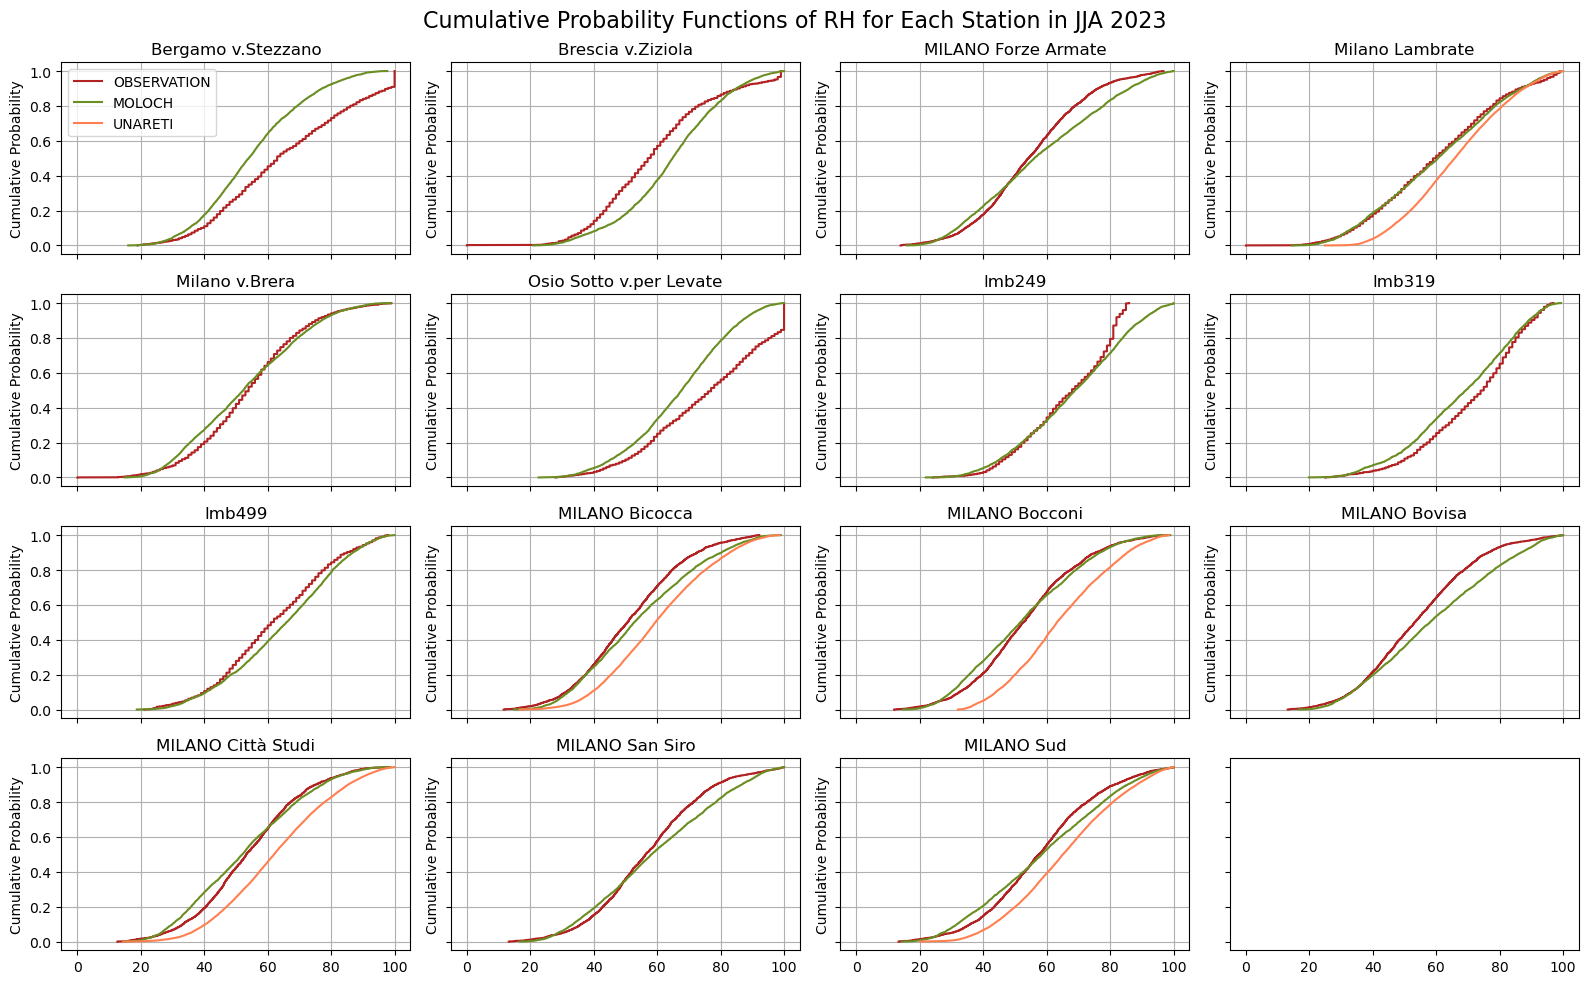

CRPS results:
MOLOCH_RH Milano 9.995688363037049
MOLOCH_RH Other 9.709626330417356
UNARETI_RH Milano 12.843182046659017
UNARETI_RH Other 12.843182046659017


In [89]:
plot_cumulative_probability_functions(dataset_RH_summer_2023, var='RH', name='JJA 2023')

## Role of distance on RMSE

In [90]:
def plot_rmse_vs_distance(dataset, var, name):
    """
    Plot the RMSE of each model against the distance between the Moloch point (LAT_MOLOCH, LON_MOLOCH) and the station (LAT_STATION, LON_STATION).
    var: the name of the variable in the dataset (e.g., 'T_2M_C', 'RH')
    name: the string used as name complement for the plot
    """
    # Prepare the data
    if var == 'T_2M_C':
        models = [f'ECOP_{var}', f'MOLOCH_{var}']
    elif var == 'RH':
        models = [f'MOLOCH_{var}']
    else:
        print(f'var {var} not understood')
        return

    # dropna to remove rows with missing values in the coordinates
    dataset = dataset.dropna(subset=['LAT_MOLOCH', 'LON_MOLOCH', 'LAT_STATION', 'LON_STATION'])

    # Calculate the distance between the Moloch point and the station
    dataset['DISTANCE'] = dataset[['LAT_MOLOCH', 'LON_MOLOCH', 'LAT_STATION', 'LON_STATION']].apply(lambda row: geodesic((row['LAT_MOLOCH'], row['LON_MOLOCH']), (row['LAT_STATION'], row['LON_STATION'])).km, axis=1)

    # Calculate RMSE for each model and station
    rmse_results = {}
    for model in models:
        rmse_results[model] = dataset.groupby(['DISTANCE', 'OLD_STATION_NAME']).apply(
            lambda x: np.sqrt(mean_squared_error(x.dropna(subset=[f'OBSERVATION_{var}', model])[f'OBSERVATION_{var}'], x.dropna(subset=[f'OBSERVATION_{var}', model])[model])) if len(x.dropna(subset=[f'OBSERVATION_{var}', model])) > 0 else None
        ).reset_index().rename(columns={0: f'RMSE_{model}'})
        
    # Plot the RMSE against the distance
    plt.figure(figsize=(12, 8))
    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x', 'd', '|', '_']
    for i, station in enumerate(dataset['OLD_STATION_NAME'].unique()):
        for j, model in enumerate(models):
            station_data = rmse_results[model][rmse_results[model]['OLD_STATION_NAME'] == station]
            plt.scatter(station_data['DISTANCE'], station_data[f'RMSE_{model}'], label=f'{model.split("_")[0]} - {station}', color=colors[model.split('_')[0]], marker=markers[i % len(markers)])

    plt.xlabel('Distance (km)')
    plt.ylabel(f'RMSE ({var})')
    plt.title(f'RMSE of {var} vs. Distance in {name}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.show()



C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_21992\4242119324.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['DISTANCE'] = dataset[['LAT_MOLOCH', 'LON_MOLOCH', 'LAT_STATION', 'LON_STATION']].apply(lambda row: geodesic((row['LAT_MOLOCH'], row['LON_MOLOCH']), (row['LAT_STATION'], row['LON_STATION'])).km, axis=1)
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_21992\4242119324.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_resul

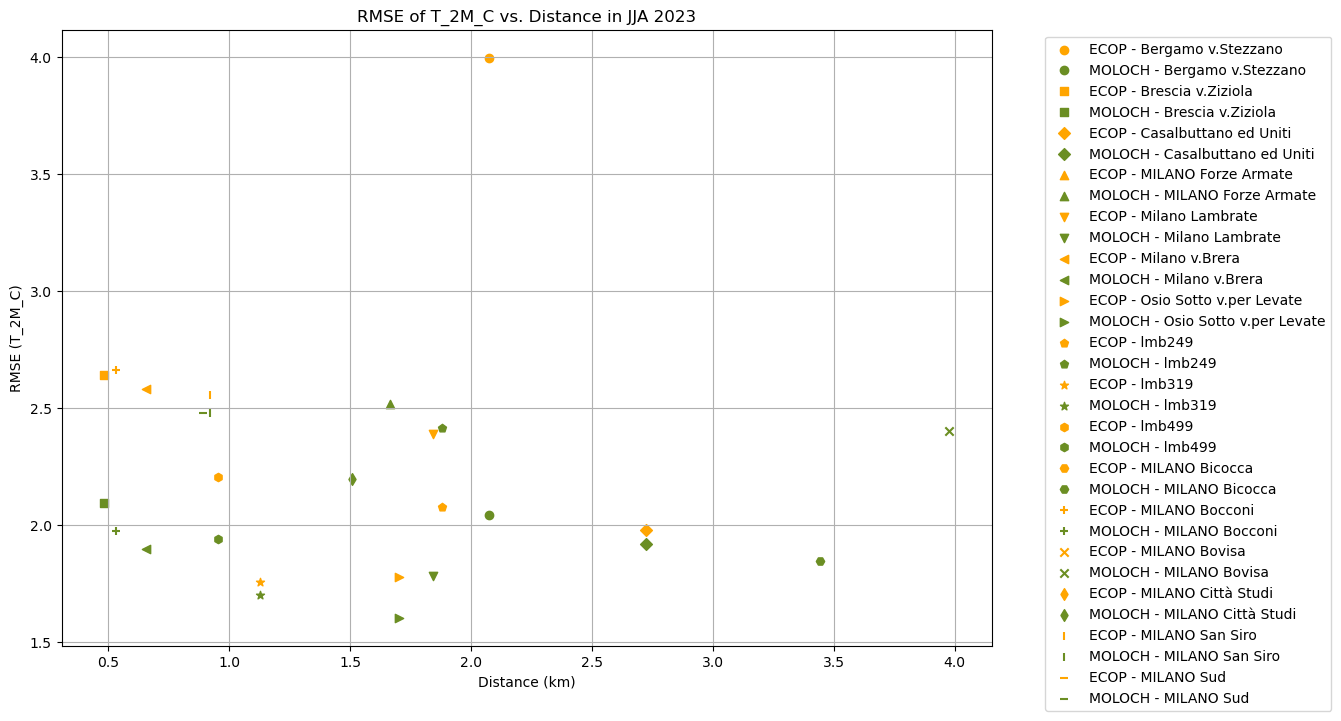

In [91]:
plot_rmse_vs_distance(dataset_T_2M_C_summer_2023, var='T_2M_C', name='JJA 2023')

## Case Studies


### Case study 1

When the forecasted max daily temperature is overestimated (1a) or underestimated (1b) by the models, and the observed max daily temperature is above 36deg.

In [51]:
def list_days_temperature_extremes(dataset, threshold=36, time_bounds=(dt.datetime(2023, 6, 1), dt.datetime(2023, 8, 31))):
    """
    List the days when the forecasted max daily temperature is overestimated or underestimated by the models,
    and the observed max daily temperature is above a given threshold.
    
    Parameters:
    - dataset: DataFrame, the dataset containing observed and forecasted values
    - threshold: float, the temperature threshold to consider (default is 36°C)
    
    Returns:
    - overestimated_days: list of dates when the forecasted max daily temperature is overestimated
    - underestimated_days: list of dates when the forecasted max daily temperature is underestimated
    - stats: dictionary containing max, mean, and min daily temperature and forecast errors for overestimated and underestimated days
    """

    var = 'T_2M_C'
    models = [f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']
    tstart, tend=time_bounds

    # Group by date and station, and get the maximum daily temperature
    max_daily_obs = dataset.groupby([dataset['VALID_DATE'].dt.date, 'OLD_STATION_NAME'])[f'OBSERVATION_{var}'].max().reset_index()
    max_daily_forecasts = {model: dataset.groupby([dataset['VALID_DATE'].dt.date, 'OLD_STATION_NAME'])[model].max().reset_index() for model in models}

    # keep only the days between time_bounds
    max_daily_obs = max_daily_obs[(max_daily_obs['VALID_DATE'] >= tstart) & (max_daily_obs['VALID_DATE'] <= tend)]
    for model in models:
        max_daily_forecasts[model] = max_daily_forecasts[model][(max_daily_forecasts[model]['VALID_DATE'] >= tstart) & (max_daily_forecasts[model]['VALID_DATE'] <= tend)]
    
    # Merge the observations with each forecast model
    merged_data = max_daily_obs
    for model in models:
        merged_data = pd.merge(merged_data, max_daily_forecasts[model], on=['VALID_DATE', 'OLD_STATION_NAME'], suffixes=('', f'_{model}'))

    # Filter days when the observed max daily temperature is above the threshold
    extreme_days = merged_data[merged_data[f'OBSERVATION_{var}'] > threshold]

    # Initialize lists to store overestimated and underestimated days
    overestimated_days = []
    underestimated_days = []
    stats = {'overestimated': {}, 'underestimated': {}}

    # Iterate through each model and identify overestimated and underestimated days
    for model in models:
        overestimated = extreme_days[extreme_days[model] > extreme_days[f'OBSERVATION_{var}']]
        underestimated = extreme_days[extreme_days[model] < extreme_days[f'OBSERVATION_{var}']]
        
        overestimated_days.extend(overestimated['VALID_DATE'].unique())
        underestimated_days.extend(underestimated['VALID_DATE'].unique())

        # Calculate statistics for overestimated days
        stats['overestimated'][model] = []
        for date in overestimated['VALID_DATE'].unique():
            day_data = overestimated[overestimated['VALID_DATE'] == date]
            stats['overestimated'][model].append({
                'date': date,
                'max_temp': day_data[model].max(),
                'mean_temp': day_data[model].mean(),
                'min_temp': day_data[model].min(),
                'forecast_error': (day_data[model] - day_data[f'OBSERVATION_{var}']).mean()
            })

        # Calculate statistics for underestimated days
        stats['underestimated'][model] = []
        for date in underestimated['VALID_DATE'].unique():
            day_data = underestimated[underestimated['VALID_DATE'] == date]
            stats['underestimated'][model].append({
                'date': date,
                'max_temp': day_data[model].max(),
                'mean_temp': day_data[model].mean(),
                'min_temp': day_data[model].min(),
                'forecast_error': (day_data[model] - day_data[f'OBSERVATION_{var}']).mean()
            })

    return extreme_days['VALID_DATE'].unique(), list(set(overestimated_days)), list(set(underestimated_days)), stats

In [52]:
date_tuple=(dt.date(2023,8,1), dt.date(2023,8,31))
extreme_days, overestimated_days, underestimated_days, stats = list_days_temperature_extremes(dataset_T_2M_C_summer_2023,time_bounds=date_tuple)

print("Extreme days:", len(extreme_days))
print(extreme_days)
print('')
print("Overestimated days:")
print(overestimated_days)
print('')
print("Underestimated days:")
print(underestimated_days)
print('')
print("Statistics:")
pprint.pprint(stats)


Extreme days: 11
[datetime.date(2023, 8, 15) datetime.date(2023, 8, 16)
 datetime.date(2023, 8, 17) datetime.date(2023, 8, 19)
 datetime.date(2023, 8, 20) datetime.date(2023, 8, 21)
 datetime.date(2023, 8, 22) datetime.date(2023, 8, 23)
 datetime.date(2023, 8, 24) datetime.date(2023, 8, 25)
 datetime.date(2023, 8, 26)]

Overestimated days:
[datetime.date(2023, 8, 22), datetime.date(2023, 8, 21), datetime.date(2023, 8, 23), datetime.date(2023, 8, 25), datetime.date(2023, 8, 24)]

Underestimated days:
[datetime.date(2023, 8, 22), datetime.date(2023, 8, 16), datetime.date(2023, 8, 26), datetime.date(2023, 8, 17), datetime.date(2023, 8, 15), datetime.date(2023, 8, 20), datetime.date(2023, 8, 21), datetime.date(2023, 8, 19), datetime.date(2023, 8, 23), datetime.date(2023, 8, 25), datetime.date(2023, 8, 24)]

Statistics:
{'overestimated': {'ECOP_T_2M_C': [{'date': datetime.date(2023, 8, 22),
                                    'forecast_error': 0.4449999999999754,
                           

In [53]:
def plot_timeseries_heatwave(dataset, var, name):
    """
    Plot the timeseries of mean and spread of observations and models.
    var: the name of the variable in the dataset (e.g., 'T_2M_C', 'RH')
    name: the string used as name complement for the plot
    """

    stations_milano = ['Milano v.Brera', 'Milano San Siro',
                      'MILANO Bicocca', 'MILANO Bocconi', 'MILANO Bovisa',
                      'MILANO Città Studi', 'MILANO Sud']
    
    other_stations = list(set(dataset['OLD_STATION_NAME'].unique()) - set(stations_milano))

    heatwave_start = dt.date(2023, 8, 15)
    heatwave_end = dt.date(2023, 8, 26)
    
    # Filter the dataset to keep only observations
    observations = dataset[[f'OBSERVATION_{var}', 'VALID_DATE', 'OLD_STATION_NAME']].dropna()

    # Convert VALID_DATE to datetime
    observations['VALID_DATE'] = pd.to_datetime(observations['VALID_DATE'])

    # keep only dates between the 15th and the 26th of August
    observations = observations[(observations['VALID_DATE'].dt.date >= heatwave_start) & (observations['VALID_DATE'].dt.date <= heatwave_end)]

    # fill VALID_DATE, sampled every hour, and add nan for observation missing values
    all_stations = observations['OLD_STATION_NAME'].unique()
    all_dates = pd.date_range(start=observations['VALID_DATE'].min(), end=observations['VALID_DATE'].max(), freq='h')
    all_combinations = pd.MultiIndex.from_product([all_dates, all_stations], names=['VALID_DATE', 'OLD_STATION_NAME'])
    
    # DROP duplicates in observation, here because in the original dataset there is one row per model
    observations = observations.drop_duplicates(subset=['VALID_DATE', 'OLD_STATION_NAME'])
    observations = observations.set_index(['VALID_DATE', 'OLD_STATION_NAME']).reindex(all_combinations).reset_index()
    
    # add the missing couples to the dataset, filling the column observation with np.nan
    missing_couples = observations[observations[f'OBSERVATION_{var}'].isna()][['VALID_DATE', 'OLD_STATION_NAME']]
    missing_couples[f'OBSERVATION_{var}'] = np.nan
    observations = pd.concat([observations, missing_couples], ignore_index=True)

    # Group by day and station (ignore hour) and compute mean (skipna=False means that a day with missing values will have NaN as mean)
    station_daily_stats = observations.groupby([observations['VALID_DATE'].dt.date, 'OLD_STATION_NAME'])[f'OBSERVATION_{var}'].agg(['min', 'max']).reset_index()
    station_daily_stats_mean = observations.groupby([observations['VALID_DATE'].dt.date, 'OLD_STATION_NAME'])[f'OBSERVATION_{var}'].agg(lambda x: x.mean(skipna=False))
    station_daily_stats_mean = station_daily_stats_mean.reset_index().rename(columns={f'OBSERVATION_{var}': 'mean'})
    station_daily_stats = station_daily_stats.merge(station_daily_stats_mean, on=['VALID_DATE', 'OLD_STATION_NAME'])

    # Group by stations and compute mean for Milan and other stations
    daily_stats_other = station_daily_stats[station_daily_stats['OLD_STATION_NAME'].isin(other_stations)].groupby('VALID_DATE')['mean'].agg('mean').reset_index()
    daily_stats_other['min'] = station_daily_stats[station_daily_stats['OLD_STATION_NAME'].isin(other_stations)].groupby('VALID_DATE')['min'].agg('min').reset_index()['min']
    daily_stats_other['max'] = station_daily_stats[station_daily_stats['OLD_STATION_NAME'].isin(other_stations)].groupby('VALID_DATE')['max'].agg('max').reset_index()['max']
    
    daily_stats_milano = station_daily_stats[station_daily_stats['OLD_STATION_NAME'].isin(stations_milano)].groupby('VALID_DATE')['mean'].agg('mean').reset_index()
    daily_stats_milano['min'] = station_daily_stats[station_daily_stats['OLD_STATION_NAME'].isin(stations_milano)].groupby('VALID_DATE')['min'].agg('min').reset_index()['min']
    daily_stats_milano['max'] = station_daily_stats[station_daily_stats['OLD_STATION_NAME'].isin(stations_milano)].groupby('VALID_DATE')['max'].agg('max').reset_index()['max']
    
    # mean difference between the mean of milano and the mean of the rest
    diff_milano = (daily_stats_milano['mean'] - daily_stats_other['mean']).abs().mean()

    # Calculate the spread
    daily_stats_other['spread'] = daily_stats_other['max'] - daily_stats_other['min']
    daily_stats_milano['spread'] = daily_stats_milano['max'] - daily_stats_milano['min']

    models = [f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']

    fig, axes = plt.subplots(1, len(models), figsize=(14, 7), sharey=True)
    colors={'inside 1':'firebrick', 'inside 2': 'orange', 'outside 1':'blue', 'outside 2':'dodgerblue'}
    linestyles={'observation':'--', 'model':'-'}

    for ax, model in zip(axes, models):
        print(f"RMSE Model: {model}")
        model_data = dataset[[model, 'TRADE_DATE', 'VALID_DATE', 'OLD_STATION_NAME', f'OBSERVATION_{var}']].dropna()
        model_data['VALID_DATE'] = pd.to_datetime(model_data['VALID_DATE'])
        model_data = model_data[(model_data['VALID_DATE'].dt.date >= heatwave_start) & (model_data['VALID_DATE'].dt.date <= heatwave_end)]

        for leadtime in [1, 2]:
            if leadtime == 1:
                leadtime_data = model_data[(model_data['VALID_DATE'] - model_data['TRADE_DATE'].dt.floor('D')).dt.total_seconds() <= 24*3600]
            else:
                leadtime_data = model_data[((model_data['VALID_DATE'] - model_data['TRADE_DATE'].dt.floor('D')).dt.total_seconds() > 24*3600)&((model_data['VALID_DATE'] - model_data['TRADE_DATE'].dt.floor('D')).dt.total_seconds() <= 48*3600)]

            # check if empty
            if leadtime_data.empty:
                print(model, leadtime, "empty")

        # COMPUTE MEAN rmse for each model and print it, station group by station group (milano and other)
            rmse_milano = np.sqrt(mean_squared_error(leadtime_data[leadtime_data['OLD_STATION_NAME'].isin(stations_milano)][f'OBSERVATION_{var}'], leadtime_data[leadtime_data['OLD_STATION_NAME'].isin(stations_milano)][model]))
            rmse_other = np.sqrt(mean_squared_error(leadtime_data[leadtime_data['OLD_STATION_NAME'].isin(other_stations)][f'OBSERVATION_{var}'], leadtime_data[leadtime_data['OLD_STATION_NAME'].isin(other_stations)][model]))

            print(f"Leadtime {leadtime} day(s) - Milano: {rmse_milano:.4f}")
            print(f"Leadtime {leadtime} day(s) - Fuori: {rmse_other:.4f}")

        # correct the model data by removing the systematic bias per station, and compute the rmse
            systematic_error = leadtime_data.groupby(['OLD_STATION_NAME'])[model].transform('mean') - leadtime_data.groupby(['OLD_STATION_NAME'])[f'OBSERVATION_{var}'].transform('mean') 
            leadtime_data[f'{model}_CORRECTED'] = leadtime_data[model] - systematic_error 
        
            rmse_milano_corrected = np.sqrt(mean_squared_error(leadtime_data[leadtime_data['OLD_STATION_NAME'].isin(stations_milano)][f'OBSERVATION_{var}'], leadtime_data[leadtime_data['OLD_STATION_NAME'].isin(stations_milano)][f'{model}_CORRECTED']))
            rmse_other_corrected = np.sqrt(mean_squared_error(leadtime_data[leadtime_data['OLD_STATION_NAME'].isin(other_stations)][f'OBSERVATION_{var}'], leadtime_data[leadtime_data['OLD_STATION_NAME'].isin(other_stations)][f'{model}_CORRECTED']))
            print(f"Leadtime {leadtime} day(s) - Milano corrected: {rmse_milano_corrected:.4f}")
            print(f"Leadtime {leadtime} day(s) - Fuori corrected: {rmse_other_corrected:.4f}")

        # Group by day and station (ignore hour) and compute mean (skipna=False means that a day with missing values will have NaN as mean)
            leadtime_data = leadtime_data[['VALID_DATE', 'OLD_STATION_NAME', model]]  # remove obs
            model_daily_stats = leadtime_data.groupby([leadtime_data['VALID_DATE'].dt.date, 'OLD_STATION_NAME'])[model].agg(['min', 'max']).reset_index()
            model_daily_stats_mean = leadtime_data.groupby([leadtime_data['VALID_DATE'].dt.date, 'OLD_STATION_NAME'])[model].agg(lambda x: x.mean(skipna=False))
            model_daily_stats_mean = model_daily_stats_mean.reset_index().rename(columns={model: 'mean'})
            model_daily_stats = model_daily_stats.merge(model_daily_stats_mean, on=['VALID_DATE', 'OLD_STATION_NAME'])

            daily_stats_other_model = model_daily_stats[model_daily_stats['OLD_STATION_NAME'].isin(other_stations)].groupby('VALID_DATE')['mean'].agg('mean').reset_index()
            daily_stats_other_model['min'] = model_daily_stats[model_daily_stats['OLD_STATION_NAME'].isin(other_stations)].groupby('VALID_DATE')['min'].agg('min').reset_index()['min']
            daily_stats_other_model['max'] = model_daily_stats[model_daily_stats['OLD_STATION_NAME'].isin(other_stations)].groupby('VALID_DATE')['max'].agg('max').reset_index()['max']

            daily_stats_milano_model = model_daily_stats[model_daily_stats['OLD_STATION_NAME'].isin(stations_milano)].groupby('VALID_DATE')['mean'].agg('mean').reset_index()
            daily_stats_milano_model['min'] = model_daily_stats[model_daily_stats['OLD_STATION_NAME'].isin(stations_milano)].groupby('VALID_DATE')['min'].agg('min').reset_index()['min']
            daily_stats_milano_model['max'] = model_daily_stats[model_daily_stats['OLD_STATION_NAME'].isin(stations_milano)].groupby('VALID_DATE')['max'].agg('max').reset_index()['max']

            # same for observations
            obs_data = dataset[[f'OBSERVATION_{var}', 'VALID_DATE', 'OLD_STATION_NAME']].dropna()
            obs_data['VALID_DATE'] = pd.to_datetime(obs_data['VALID_DATE'])
            obs_data = obs_data[(obs_data['VALID_DATE'].dt.date >= heatwave_start) & (obs_data['VALID_DATE'].dt.date <= heatwave_end)]
            obs_data_daily_stats = obs_data.groupby([obs_data['VALID_DATE'].dt.date, 'OLD_STATION_NAME'])[f'OBSERVATION_{var}'].agg(['min', 'max']).reset_index()
            obs_data_daily_stats_mean = obs_data.groupby([obs_data['VALID_DATE'].dt.date, 'OLD_STATION_NAME'])[f'OBSERVATION_{var}'].agg(lambda x: x.mean(skipna=False))
            obs_data_daily_stats_mean = obs_data_daily_stats_mean.reset_index().rename(columns={f'OBSERVATION_{var}': 'mean'})
            obs_data_daily_stats = obs_data_daily_stats.merge(obs_data_daily_stats_mean, on=['VALID_DATE', 'OLD_STATION_NAME'])

            daily_stats_other_obs = obs_data_daily_stats[obs_data_daily_stats['OLD_STATION_NAME'].isin(other_stations)].groupby('VALID_DATE')['mean'].agg('mean').reset_index()
            daily_stats_other_obs['min'] = obs_data_daily_stats[obs_data_daily_stats['OLD_STATION_NAME'].isin(other_stations)].groupby('VALID_DATE')['min'].agg('min').reset_index()['min']
            daily_stats_other_obs['max'] = obs_data_daily_stats[obs_data_daily_stats['OLD_STATION_NAME'].isin(other_stations)].groupby('VALID_DATE')['max'].agg('max').reset_index()['max']

            daily_stats_milano_obs = obs_data_daily_stats[obs_data_daily_stats['OLD_STATION_NAME'].isin(stations_milano)].groupby('VALID_DATE')['mean'].agg('mean').reset_index()
            daily_stats_milano_obs['min'] = obs_data_daily_stats[obs_data_daily_stats['OLD_STATION_NAME'].isin(stations_milano)].groupby('VALID_DATE')['min'].agg('min').reset_index()['min']
            daily_stats_milano_obs['max'] = obs_data_daily_stats[obs_data_daily_stats['OLD_STATION_NAME'].isin(stations_milano)].groupby('VALID_DATE')['max'].agg('max').reset_index()['max']

            # Plot the timeseries of model in Milano and other stations
            print(daily_stats_milano_model)
            ax.plot(daily_stats_other_model['VALID_DATE'], daily_stats_other_model['mean'], label=f'{model.split("_")[0]} outside Milan', color=colors[f'outside {leadtime}'], linestyle=linestyles['model'])
            ax.plot(daily_stats_milano_model['VALID_DATE'], daily_stats_milano_model['mean'], label=f'{model.split("_")[0]} in Milan', color=colors[f'inside {leadtime}'], linestyle=linestyles['model'])
            ax.plot(daily_stats_other_model['VALID_DATE'], daily_stats_other_model['min'], linestyle=linestyles['model'], color=colors[f'outside {leadtime}'], alpha=0.5, label=f'Daily Min and Max {model.split("_")[0]} outside Milan')
            ax.plot(daily_stats_other_model['VALID_DATE'], daily_stats_other_model['max'], linestyle=linestyles['model'], color=colors[f'outside {leadtime}'], alpha=0.5)
            ax.plot(daily_stats_milano_model['VALID_DATE'], daily_stats_milano_model['min'], linestyle=linestyles['model'], color=colors[f'inside {leadtime}'], alpha=0.5, label=f'Daily Min and Max {model.split("_")[0]} in Milan')
            ax.plot(daily_stats_milano_model['VALID_DATE'], daily_stats_milano_model['max'], linestyle=linestyles['model'], color=colors[f'inside {leadtime}'], alpha=0.5)

        # same for observations
        ax.plot(daily_stats_other_obs['VALID_DATE'], daily_stats_other_obs['mean'], label=f'Observation outside Milan', linestyle=linestyles['observation'],color=colors['outside 1'], alpha=1)
        ax.plot(daily_stats_milano_obs['VALID_DATE'], daily_stats_milano_obs['mean'], label=f'Observation in Milan', linestyle=linestyles['observation'],color=colors['inside 1'],  alpha=1)
        ax.plot(daily_stats_other_obs['VALID_DATE'], daily_stats_other_obs['min'], linestyle=linestyles['observation'], color=colors['outside 1'], alpha=0.5, label=f'Daily Min and Max Observation outside Milan')
        ax.plot(daily_stats_other_obs['VALID_DATE'], daily_stats_other_obs['max'], linestyle=linestyles['observation'], color=colors['outside 1'], alpha=0.5)
        ax.plot(daily_stats_milano_obs['VALID_DATE'], daily_stats_milano_obs['min'], linestyle=linestyles['observation'], color=colors['inside 1'], alpha=0.5, label=f'Daily Min and Max Observation in Milan')
        ax.plot(daily_stats_milano_obs['VALID_DATE'], daily_stats_milano_obs['max'], linestyle=linestyles['observation'], color=colors['inside 1'], alpha=0.5)

        ax.set_title(f'{model.split("_")[0]} Model')
        ax.set_xlabel('Date')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True)
    
    ax.legend(bbox_to_anchor=(1.05, 1.), loc='upper left')

    axes[0].set_ylabel(f'{var} (°C)' if var == 'T_2M_C' else f'{var} (%)')
    fig.suptitle(f'Timeseries of Mean and Spread of {var} in {name}')
    plt.xlabel('Date')
    plt.tight_layout()
    plt.show()


RMSE Model: ECOP_T_2M_C
Leadtime 1 day(s) - Milano: 2.0743
Leadtime 1 day(s) - Fuori: 2.0126
Leadtime 1 day(s) - Milano corrected: 1.4503
Leadtime 1 day(s) - Fuori corrected: 1.3539
    VALID_DATE       mean   min   max
0   2023-08-15  28.321429  22.5  33.0
1   2023-08-16  27.221429  22.7  31.7
2   2023-08-17  26.916270  22.5  31.3
3   2023-08-18  28.788095  22.2  34.3
4   2023-08-19  29.835714  23.7  35.1
5   2023-08-20  30.406022  25.3  35.9
6   2023-08-21  31.285714  25.3  36.1
7   2023-08-22  31.857143  25.5  37.2
8   2023-08-23  31.619608  26.3  36.9
9   2023-08-24  31.954762  26.4  37.5
10  2023-08-25  30.464286  25.2  35.5
11  2023-08-26  25.517227  21.4  31.6
Leadtime 2 day(s) - Milano: 2.3310
Leadtime 2 day(s) - Fuori: 2.1060
Leadtime 2 day(s) - Milano corrected: 1.7924
Leadtime 2 day(s) - Fuori corrected: 1.4678
    VALID_DATE       mean   min   max
0   2023-08-15  28.095833  23.9  33.8
1   2023-08-16  28.041667  23.4  33.0
2   2023-08-17  25.351190  21.7  31.1
3   2023-08-18

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\177097807.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leadtime_data[f'{model}_CORRECTED'] = leadtime_data[model] - systematic_error
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\177097807.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leadtime_data[f'{model}_CORRECTED'] = leadtime_data[model] - systematic_error


Leadtime 1 day(s) - Milano: 1.9838
Leadtime 1 day(s) - Fuori: 1.8364
Leadtime 1 day(s) - Milano corrected: 1.9024
Leadtime 1 day(s) - Fuori corrected: 1.6814
    VALID_DATE       mean       min       max
0   2023-08-15  29.062900  21.44387  36.17364
1   2023-08-16  29.111213  22.69020  35.04098
2   2023-08-17  28.157121  21.74545  34.48540
3   2023-08-18  28.861269  20.40340  36.18150
4   2023-08-19  29.876324  21.98837  36.89166
5   2023-08-20  30.856474  23.81945  37.93966
6   2023-08-21  31.510505  23.68188  38.43133
7   2023-08-22  31.954602  23.60842  39.31070
8   2023-08-23  32.193119  23.94460  39.42358
9   2023-08-24  32.682901  24.42986  40.01140
10  2023-08-25  30.970400  22.89420  38.53090
11  2023-08-26  26.996031  22.07943  34.30410
Leadtime 2 day(s) - Milano: 2.1553
Leadtime 2 day(s) - Fuori: 1.9131
Leadtime 2 day(s) - Milano corrected: 1.8792
Leadtime 2 day(s) - Fuori corrected: 1.8115
    VALID_DATE       mean       min       max
0   2023-08-15  29.916688  23.10156  36.

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\177097807.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leadtime_data[f'{model}_CORRECTED'] = leadtime_data[model] - systematic_error
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\177097807.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leadtime_data[f'{model}_CORRECTED'] = leadtime_data[model] - systematic_error


Leadtime 1 day(s) - Milano: 2.6820
Leadtime 1 day(s) - Fuori: 1.5819
Leadtime 1 day(s) - Milano corrected: 0.9932
Leadtime 1 day(s) - Fuori corrected: 1.4562
    VALID_DATE       mean     min     max
0   2023-08-15  24.883167  23.472  25.649
1   2023-08-16  25.228833  23.702  26.111
2   2023-08-17  25.339167  24.675  26.200
3   2023-08-18  21.910417  20.994  22.903
4   2023-08-19  25.124458  23.485  25.805
5   2023-08-20  26.568125  25.423  27.457
6   2023-08-21  27.038208  25.532  27.858
7   2023-08-22  27.761875  26.490  28.467
8   2023-08-23  28.028083  26.757  28.967
9   2023-08-24  28.126375  26.632  28.833
10  2023-08-25  27.698083  25.773  28.719
11  2023-08-26  25.329792  23.313  26.732
Leadtime 2 day(s) - Milano: 2.3844
Leadtime 2 day(s) - Fuori: 2.4882
Leadtime 2 day(s) - Milano corrected: 2.0373
Leadtime 2 day(s) - Fuori corrected: 2.2866
    VALID_DATE       mean     min     max
0   2023-08-15  27.903380  22.169  36.108
1   2023-08-16  28.067049  22.341  36.236
2   2023-08-

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\177097807.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leadtime_data[f'{model}_CORRECTED'] = leadtime_data[model] - systematic_error
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\177097807.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leadtime_data[f'{model}_CORRECTED'] = leadtime_data[model] - systematic_error


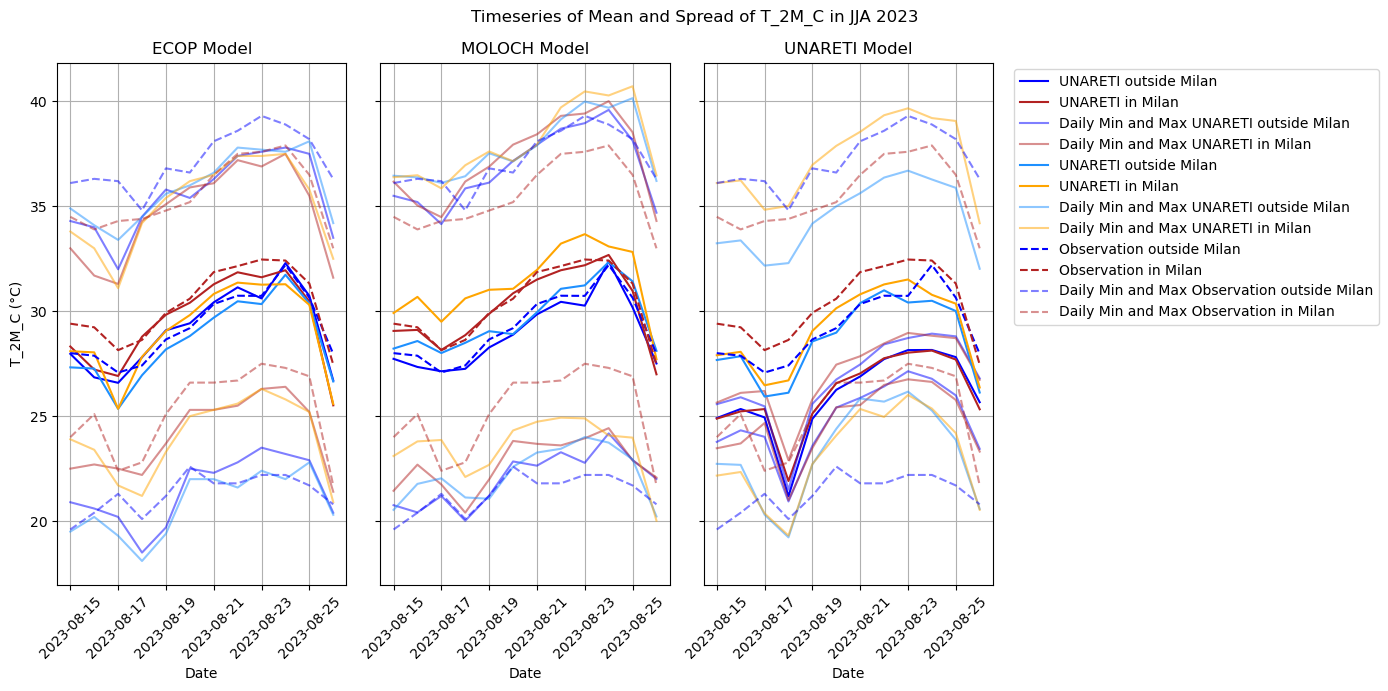

In [54]:
plot_timeseries_heatwave(dataset_T_2M_C_summer_2023, var='T_2M_C', name='JJA 2023')

In [56]:
heatwave_start = dt.date(2023, 8, 15)
heatwave_end = dt.date(2023, 8, 26)
dataset_heatwave=dataset_T_2M_C_summer_2023[(dataset_T_2M_C_summer_2023['VALID_DATE'].dt.date >= heatwave_start) & (dataset_T_2M_C_summer_2023['VALID_DATE'].dt.date <= heatwave_end)]

res=count_accurate_forecasts(dataset_heatwave, var='T_2M_C')
pprint.pprint(res)

({'ECOP_T_2M_C': 3, 'MOLOCH_T_2M_C': 11, 'UNARETI_T_2M_C': 15},
 {'ECOP_T_2M_C': 0.10344827586206896,
  'MOLOCH_T_2M_C': 0.3793103448275862,
  'UNARETI_T_2M_C': 0.5172413793103449},
 {'ECOP_T_2M_C': 2, 'MOLOCH_T_2M_C': 12, 'UNARETI_T_2M_C': 15},
 {'ECOP_T_2M_C': 0.06896551724137931,
  'MOLOCH_T_2M_C': 0.41379310344827586,
  'UNARETI_T_2M_C': 0.5172413793103449})


C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\1665018259.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[f'{model}_ERROR'] = (dataset[model] - dataset[f'OBSERVATION_{var}']).abs()
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\1665018259.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[f'{model}_ERROR'] = (dataset[model] - dataset[f'OBSERVATION_{var}']).abs()
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_3416\1665018259.py:21: SettingWithCopyWarning: 
A value is

### Case study 2

Investigating the situations leading to a largely anticipated maximum daily temperature in the WRF models.


In [97]:
def correlation_mean_max_temp(dataset, var, name):
    """
    Study the correlation between mean daily temperature and max daily temperature for each model and for each group of stations (Milano and outside).
    var: the name of the variable in the dataset (e.g., 'T_2M_C')
    name: the string used as name complement for the plot
    """
    models = [f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']
    stations_milano = ['Milano v.Brera', 'Milano San Siro',
                       'MILANO Bicocca', 'MILANO Bocconi', 'MILANO Bovisa',
                       'MILANO Città Studi', 'MILANO Sud']
    other_stations = list(set(dataset['OLD_STATION_NAME'].unique()) - set(stations_milano))

    # Group by date and station, and get the mean and max daily temperature
    daily_stats = dataset.groupby([dataset['VALID_DATE'].dt.date, 'OLD_STATION_NAME']).agg(
        mean_temp=(f'OBSERVATION_{var}', 'mean'),
        max_temp=(f'OBSERVATION_{var}', 'max')
    ).reset_index()

    # Initialize a dictionary to store correlation results
    correlation_results = {'Milano': {}, 'Outside': {}}

    # Calculate correlation for each model and each group of stations
    for model in models:
        daily_stats[model] = dataset.groupby([dataset['VALID_DATE'].dt.date, 'OLD_STATION_NAME'])[model].transform('mean')
        for group, stations in [('Milano', stations_milano), ('Outside', other_stations)]:
            group_data = daily_stats[daily_stats['OLD_STATION_NAME'].isin(stations)]
            correlation, p_value = pearsonr(group_data['mean_temp'], group_data['max_temp'])
            correlation_results[group][model] = {'correlation': correlation, 'p_value': p_value}

    # Print correlation results
    for group in correlation_results:
        print(f"Correlation results for {group} stations:")
        for model in correlation_results[group]:
            print(f"{model}: Correlation = {correlation_results[group][model]['correlation']:.2f}, p-value = {correlation_results[group][model]['p_value']:.2e}")

    # Plot correlation results
    fig, ax = plt.subplots(figsize=(10, 6))
    bar_width = 0.35
    index = np.arange(len(models))

    for i, group in enumerate(correlation_results):
        correlations = [correlation_results[group][model]['correlation'] for model in models]
        ax.bar(index + i * bar_width, correlations, bar_width, label=group)

    ax.set_xlabel('Models')
    ax.set_ylabel('Correlation')
    ax.set_title(f'Correlation between Mean and Max Daily Temperature in {name}')
    ax.set_xticks(index + bar_width / 2)
    ax.set_xticklabels([model.split('_')[0] for model in models])
    ax.legend()

    plt.show()

    return correlation_results

Correlation results for Milano stations:
ECOP_T_2M_C: Correlation = 0.97, p-value = 0.00e+00
MOLOCH_T_2M_C: Correlation = 0.97, p-value = 0.00e+00
UNARETI_T_2M_C: Correlation = 0.97, p-value = 0.00e+00
Correlation results for Outside stations:
ECOP_T_2M_C: Correlation = 0.91, p-value = 0.00e+00
MOLOCH_T_2M_C: Correlation = 0.91, p-value = 0.00e+00
UNARETI_T_2M_C: Correlation = 0.91, p-value = 0.00e+00


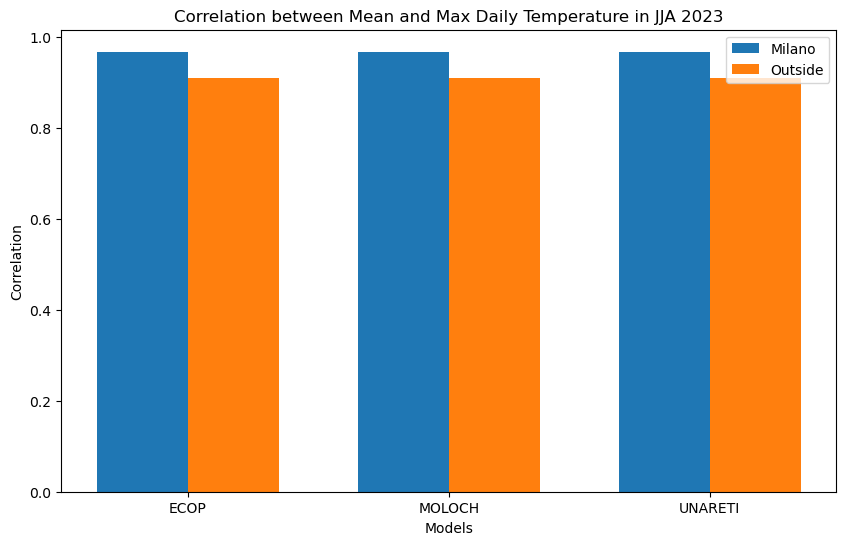

{'Milano': {'ECOP_T_2M_C': {'correlation': 0.9669890741666534, 'p_value': 0.0},
  'MOLOCH_T_2M_C': {'correlation': 0.9669890741666534, 'p_value': 0.0},
  'UNARETI_T_2M_C': {'correlation': 0.9669890741666534, 'p_value': 0.0}},
 'Outside': {'ECOP_T_2M_C': {'correlation': 0.9100404412774221,
   'p_value': 0.0},
  'MOLOCH_T_2M_C': {'correlation': 0.9100404412774221, 'p_value': 0.0},
  'UNARETI_T_2M_C': {'correlation': 0.9100404412774221, 'p_value': 0.0}}}

In [98]:
correlation_mean_max_temp(dataset_T_2M_C_summer_2023, var='T_2M_C', name='JJA 2023')

In [99]:
def plot_time_offset_scatter(dataset, var, name):
    """
    Plot the time offset at which the maximum temperature is reached (hour of VALID_DATE) between each model and the observations.
    var: the name of the variable in the dataset (T_2M_C)
    name: the string used as name complement for the plot
    """
    # Prepare the data
   
    if var == 'T_2M_C':
        models = [f'ECOP_{var}', f'MOLOCH_{var}', f'UNARETI_{var}']
    elif var == 'RH':
        models = [f'MOLOCH_{var}', f'UNARETI_{var}']

    # Group by date and station, and get the hour of maximum daily temperature
    max_temp_obs = dataset.groupby([dataset['VALID_DATE'].dt.date, 'OLD_STATION_NAME']).apply(lambda x: x.loc[x[f'OBSERVATION_{var}'].idxmax()]['VALID_DATE'].hour, include_groups=False).reset_index(name='OBS_HOUR')
    max_temp_forecasts = {model: dataset.groupby([dataset['VALID_DATE'].dt.date, 'OLD_STATION_NAME']).apply(lambda x: x.dropna(subset=[model]).loc[x[model].idxmax()]['VALID_DATE'].hour if not x.dropna(subset=[model]).empty else np.nan, include_groups=False).reset_index(name=f'{model}_HOUR') for model in models}

    # Merge the observations with each forecast model
    merged_data = max_temp_obs
    for model in models:
        merged_data = pd.merge(merged_data, max_temp_forecasts[model], on=['VALID_DATE', 'OLD_STATION_NAME'], suffixes=('', f'_{model}'))

    # Calculate the time offset
    for model in models:
        merged_data[f'{model}_OFFSET'] = merged_data[f'{model}_HOUR'] - merged_data['OBS_HOUR'] # offset is positive if the model is later than the observation
        
    # Get the maximum daily observed temperature
    max_temp_obs_value = dataset.groupby([dataset['VALID_DATE'].dt.date, 'OLD_STATION_NAME'])[f'OBSERVATION_{var}'].max().reset_index(name='OBS_MAX_TEMP')
    merged_data = pd.merge(merged_data, max_temp_obs_value, on=['VALID_DATE', 'OLD_STATION_NAME'])

    # Plot the time offset as a function of the maximum daily observed temperature
    fig, ax1 = plt.subplots(figsize=(12, 8))

    for model in models:
        ax1.scatter(merged_data['OBS_MAX_TEMP'], merged_data[f'{model}_OFFSET'], alpha=0.5, label=model, color=colors[model.split('_')[0]])
        
    ax1.set_xlabel('Maximum Observed Temperature')
    ax1.set_ylabel('Time Offset (hours)')
    ax1.set_title(f'Time Offset at Which Maximum Temperature is Reached in {name}')
    ax1.legend()
    ax1.grid(True)

    plt.show()


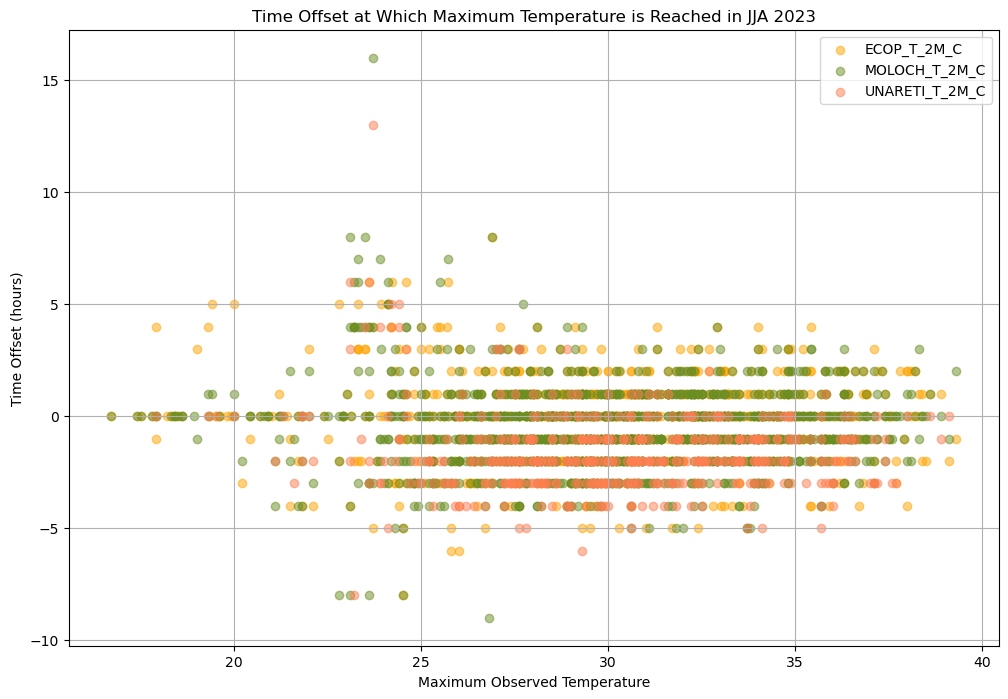

In [100]:
plot_time_offset_scatter(dataset_T_2M_C_summer_2023, var='T_2M_C', name='JJA 2023')

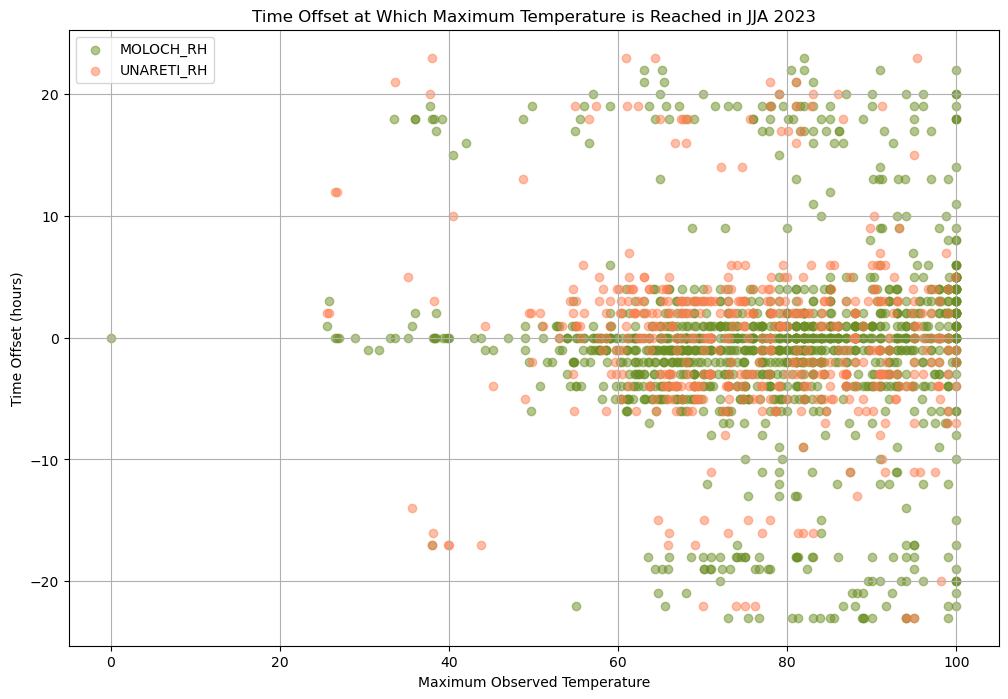

In [101]:
plot_time_offset_scatter(dataset_RH_summer_2023, var='RH', name='JJA 2023') 

## Simple models


### Temperature threshold model

In [716]:
def model_obs_temperature_threshold(dataset_temp, threshold, lag=0):
    """
    model throwing an alert when the average observed temperature in Milan exceeds a threshold
    lag is the number of hours between the temperature exceeding the threshold and the alert
    """

    # manipulate the temperature dataset 
    obs_data = dataset_temp[['OBSERVATION_T_2M_C', 'VALID_DATE', 'LAT_STATION', 'LON_STATION']].dropna() 
    obs_data = obs_data.drop_duplicates(subset=['VALID_DATE', 'LAT_STATION', 'LON_STATION']) # remove duplicates from different forecasts linked to the same station
    obs_data = obs_data.groupby('VALID_DATE')['OBSERVATION_T_2M_C'].mean().reset_index() # average over the stations

    obs_data['VALID_DATE'] = pd.to_datetime(obs_data['VALID_DATE'])
    obs_data['ALERT'] = 0

    # find the dates when the temperature exceeds the threshold
    obs_data['ALERT'] = (obs_data['OBSERVATION_T_2M_C'] > threshold).astype(int)
    obs_data['ALERT'] = obs_data['ALERT'].shift(lag)
    

    # plot hours with the alert in red
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.plot(obs_data['VALID_DATE'], obs_data['OBSERVATION_T_2M_C'], color='blue', label='Temperature')
    ax.fill_between(obs_data['VALID_DATE'], 15, 36, where=obs_data['ALERT']==1, color='red', alpha=0.5, label='Alert')
    ax.set_xlabel('Date')
    ax.set_ylabel('Temperature (°C)')
    ax.set_title(f'Temperature Alert when Exceeding {threshold} °C')
    ax.legend()
    ax.grid(True)

    plt.show()
    plt.close()

    return obs_data

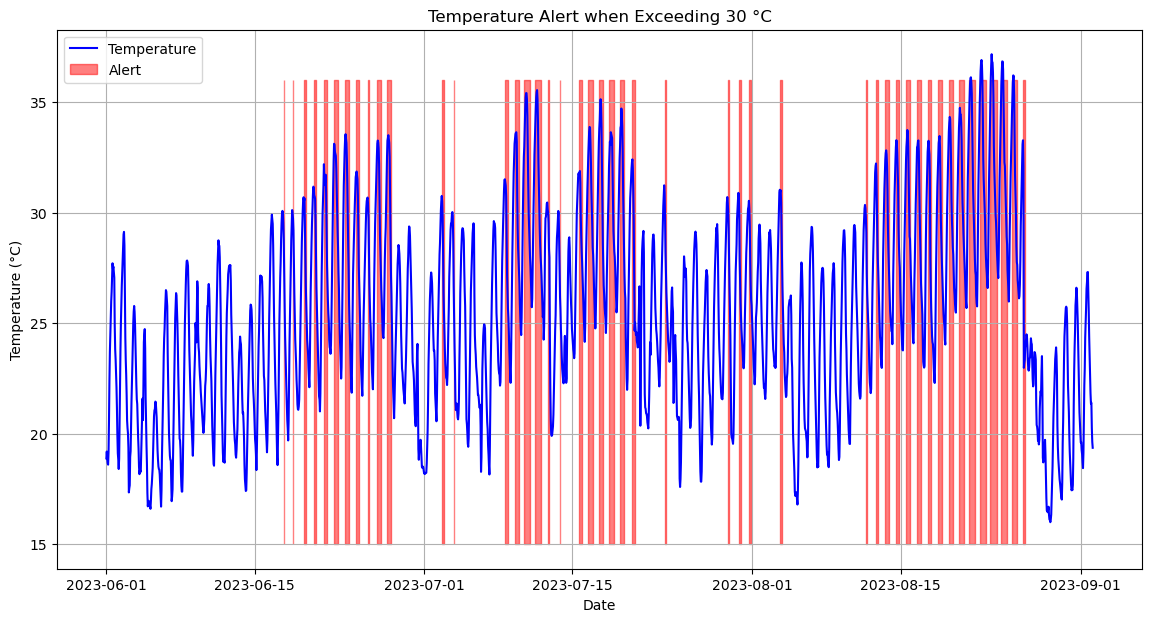

,VALID_DATE,OBSERVATION_T_2M_C,ALERT
0,2023-06-01 00:00:00+00:00,18.883000,NaN
1,2023-06-01 01:00:00+00:00,19.192308,NaN
2,2023-06-01 02:00:00+00:00,18.869231,NaN
3,2023-06-01 03:00:00+00:00,18.669231,0.0
4,2023-06-01 04:00:00+00:00,18.600000,0.0
...,...,...,...
2231,2023-09-01 23:00:00+00:00,21.363000,0.0
2232,2023-09-02 00:00:00+00:00,21.400000,0.0
2233,2023-09-02 01:00:00+00:00,20.258125,0.0
2234,2023-09-02 02:00:00+00:00,19.626875,0.0


In [718]:
model_obs_temperature_threshold(dataset_T_2M_C_summer_2023, threshold=30, lag=3)

In [1692]:
def confusion_matrix_model_obs_temperature_threshold(dataset_temp, guasti, thresholds):
    """
    model throwing an alert for a guasto when the average observed temperature in Milan exceeds a threshold
    if guasto happens at the hour and the alert was thrown, it is a true positive
    if guasto happens and the alert was not thrown, it is a false negative
    if guasto does not happen and the alert was thrown, it is a false positive
    if guasto does not happen and the alert was not thrown, it is a true negative

    list of thresholds to test
    """

    # cost of the false positive and false negative
    f_cost = 1 # false positive cost - alert when there is no failure
    t_cost = 100 # false negative cost - no alert when there is a failure

    # manipulate the temperature dataset 
    obs_data = dataset_temp[['OBSERVATION_T_2M_C', 'VALID_DATE', 'LAT_STATION', 'LON_STATION']].dropna() 
    obs_data = obs_data.drop_duplicates(subset=['VALID_DATE', 'LAT_STATION', 'LON_STATION']) # remove duplicates from different forecasts linked to the same station
    obs_data = obs_data.groupby('VALID_DATE')['OBSERVATION_T_2M_C'].mean().reset_index() # average over the stations

    obs_data['VALID_DATE'] = pd.to_datetime(obs_data['VALID_DATE'])

    for i, threshold in enumerate(thresholds):
        obs_data[f'ALERT_{threshold}'] = obs_data.apply(lambda x: 1 if x['OBSERVATION_T_2M_C'] > threshold else 0, axis=1)

    # manipulate the guasti dataset
    guasti['Data di guasto'] = pd.to_datetime(guasti['Data di guasto'])
    guasti['GUASTO'] = 1

    # merge the datasets
    merged_data = pd.merge(obs_data, guasti, left_on='VALID_DATE', right_on='Data di guasto', how='left')
    merged_data['GUASTO'] = merged_data['GUASTO'].fillna(0)

    # calculate the confusion matrix for each threshold
    conf_matrices = {}
    cost = {}
    for threshold in thresholds:
        conf_matrix = confusion_matrix(merged_data['GUASTO'], merged_data[f'ALERT_{threshold}'])
        conf_matrices[threshold] = conf_matrix

    # plot the confusion matrices
    fig, ax = plt.subplots(3, 5, figsize=(14, 7), sharex=True, sharey=True)
    ax = ax.ravel()
    fig.subplots_adjust(hspace=0.5)

    # plot the confusion matrices with common color scale
    vmax = max([conf_matrices[threshold].max() for threshold in thresholds])
    for i, threshold in enumerate(thresholds):
        f=sns.heatmap(conf_matrices[threshold], annot=True, fmt='d', ax=ax[i], cmap='Blues', vmin=0, vmax=vmax, cbar=False)

        # calculate the cost
        cost[threshold] = conf_matrices[threshold][0, 1] * f_cost + conf_matrices[threshold][1, 0] * t_cost
        ax[i].set_title(f'Threshold = {threshold} °C\nCost = {cost[threshold]}')


        # remove ticks and labels
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        ax[i].set_xlabel('')
        ax[i].set_ylabel('')

    # legend
    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.01, 0.7])
    fig.colorbar(f.get_children()[0], cax=cbar_ax, orientation='vertical', label='Count')

    fig.suptitle('Confusion Matrices for Temperature Alert')    

    plt.show()
    plt.close()

    # plot cost as a function of the threshold
    plt.figure(figsize=(7, 7))
    plt.plot(thresholds, [cost[threshold] for threshold in thresholds], color='blue')
    plt.xlabel('Threshold (°C)')
    plt.ylabel('Cost')
    plt.title('Cost as a Function of the Temperature Alert Threshold')
    plt.grid(True)
    plt.show()
    plt.close

    return conf_matrices, cost

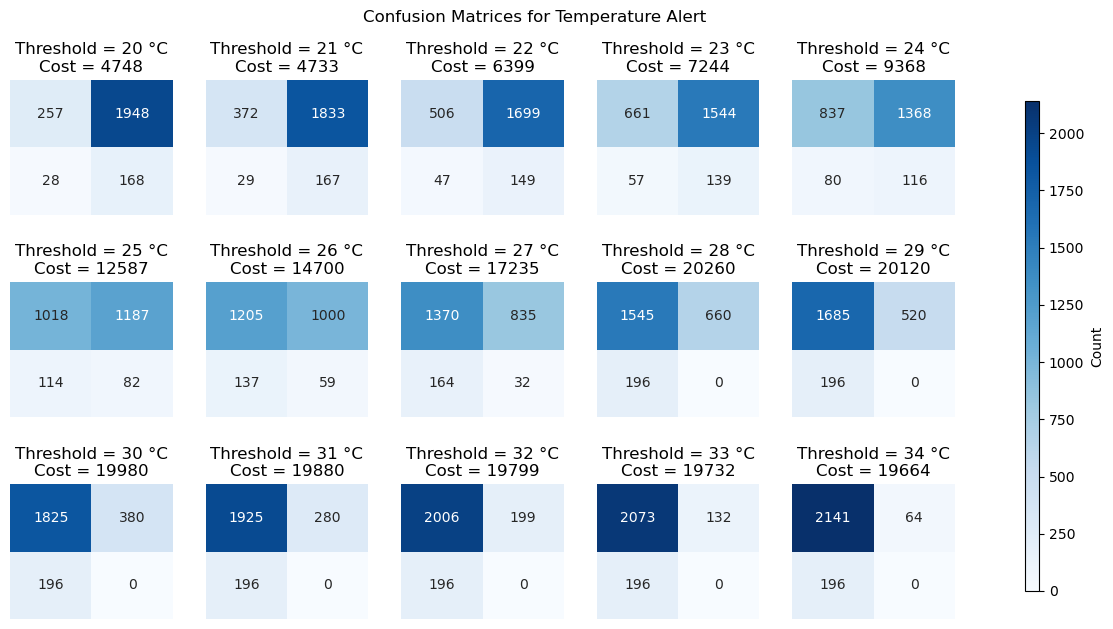

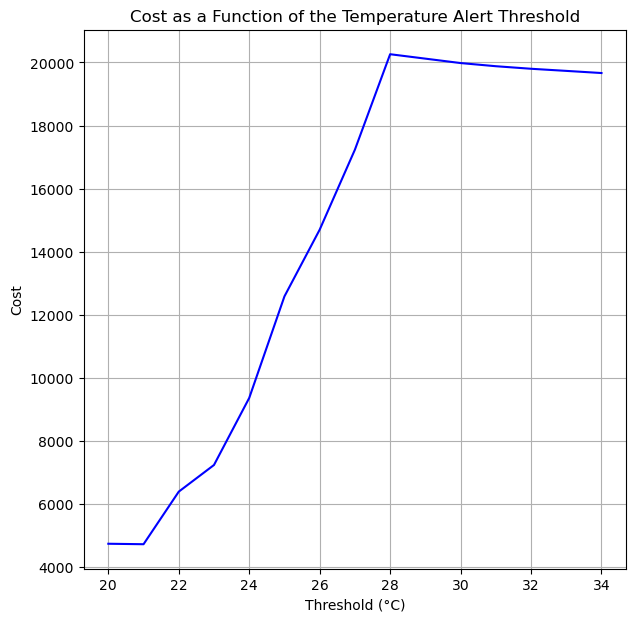

({20: array([[ 257, 1948],
         [  28,  168]], dtype=int64),
  21: array([[ 372, 1833],
         [  29,  167]], dtype=int64),
  22: array([[ 506, 1699],
         [  47,  149]], dtype=int64),
  23: array([[ 661, 1544],
         [  57,  139]], dtype=int64),
  24: array([[ 837, 1368],
         [  80,  116]], dtype=int64),
  25: array([[1018, 1187],
         [ 114,   82]], dtype=int64),
  26: array([[1205, 1000],
         [ 137,   59]], dtype=int64),
  27: array([[1370,  835],
         [ 164,   32]], dtype=int64),
  28: array([[1545,  660],
         [ 196,    0]], dtype=int64),
  29: array([[1685,  520],
         [ 196,    0]], dtype=int64),
  30: array([[1825,  380],
         [ 196,    0]], dtype=int64),
  31: array([[1925,  280],
         [ 196,    0]], dtype=int64),
  32: array([[2006,  199],
         [ 196,    0]], dtype=int64),
  33: array([[2073,  132],
         [ 196,    0]], dtype=int64),
  34: array([[2141,   64],
         [ 196,    0]], dtype=int64)},
 {20: 4748,
  21: 4733,


In [1693]:
confusion_matrix_model_obs_temperature_threshold(dataset_T_2M_C_summer_2023, guasti_summer_2023, [i for i in range(20, 35, 1)])